# Protein Seroreactivity: Exposed vs HBDB

This notebook focuses on analyses comparing Lassa-exposed samples (contacts + survivors pooled) against HBDB controls, derived from the all-peptides workflow.

# Data import

In [1]:
import pandas as pd
import re

#Raw RPK matrix: peptides x sample IDs

rpk_df = pd.read_csv("rpk_df_technical_replicates_all_averaged_043026.csv").set_index("peptide")

#sample metadata with time info
meta = pd.read_csv("../master_sample_metadata.csv")

#subset to US healthy controls - control group
df_hbdb = rpk_df.filter(regex='^HBDB-', axis = 1)

#subset to exposed
exposed = rpk_df.filter(regex=('^C-|^S-'))

#load peptide protein metadata
protein_metadata = pd.read_csv("../lassa_library_sequences_species_standardized_070726.csv")

# Filter out low readcount samples if there are any

In [4]:
#starting with Sierra Leonea'n cohort - only want to keep samples that have more than 2X coverage

exposed_read_counts = exposed.sum(axis=0)
exposed_read_counts

C-452-2_5_H3    100000.0
C-109-3_4_E7    100000.0
C-111-3_3_I6    100000.0
C-112-1_3_B3    100000.0
C-112-2_7_G7    100000.0
                  ...   
S-511_SA5_A6    100000.0
S-512_SA3_G9    100000.0
S-513_SA3_I2    100000.0
S-513_SA5_A8    100000.0
S-514_SA5_A9    100000.0
Length: 884, dtype: float64

# Data processing

### converting exposed cohort to a long df which includes relevant metadata such as collection date(s)

In [2]:
#Long format for merging with metadata
exposed_rpk_long = (
    exposed.reset_index()
    .melt(id_vars="peptide", var_name="sample_id", value_name="rpk")
    .merge(
        meta[[
            "sample_id", "participant_id",
            "collection_date", "collection_year", "visit_number", 
            "years_since_baseline", "is_baseline"
        ]],
        on="sample_id",
        how="left"
    )
).set_index('peptide')

In [3]:
#have a baseline and a longitudinal RPK dataframe
baseline_long = exposed_rpk_long[exposed_rpk_long["is_baseline"] == "yes"]
longitudinal_long = exposed_rpk_long.dropna(subset=["years_since_baseline"])

#attach peptide taxonomy metadata to baseline dataframe
meta_ann_baseline = (
    protein_metadata[["seq_id", "family", "genus", "species"]]
    .drop_duplicates("seq_id")
    .set_index("seq_id")
)

baseline_long = baseline_long.drop(columns=["family", "genus", "species"], errors="ignore").join(
    meta_ann_baseline[["family", "genus", "species"]],
    how="left"
)


In [4]:
import numpy as np

baseline_long['status'] = np.where(
    baseline_long['participant_id'].str.startswith('C'), 
    'Contact', 
    np.where(
        baseline_long['participant_id'].str.startswith('S'), 
        'Survivor', 
        None
    )
)

### Normalize to US healthies using z-score

In [5]:
import numpy as np

mat = exposed.apply(pd.to_numeric, errors="coerce").fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

#log transforming before z-scoring
log_mat = np.log10(mat + 1.0)


In [6]:
log_hbdb = np.log10(df_hbdb + 1.0)

log_hbdb_mean = log_hbdb.mean(axis=1)
log_hbdb_std = log_hbdb.std(axis=1, ddof=1).replace(0, np.nan)


In [7]:
#z-score using healthy controls as reference
z_mat = log_mat.sub(log_hbdb_mean, axis=0).div(log_hbdb_std, axis=0)
z_mat = z_mat.fillna(0.0)

### making another long format of exposed cohort but now with z-score values

In [8]:
#Long format for merging with metadata

z_long = (
    z_mat.reset_index()
    .melt(id_vars="peptide", var_name="sample_id", value_name="z_score")
    .merge(
        meta[[
            "sample_id", "participant_id",
            "collection_date", "collection_year", "visit_number", 
            "years_since_baseline", "is_baseline"
        ]],
        on="sample_id",
        how="left"
    )
).set_index('peptide')

In [9]:
#adding genus to the z_long table

z_long = (
    z_long.reset_index()
    .merge(
        protein_metadata[["seq_id", "genus"]],
        left_on="peptide", 
        right_on="seq_id", 
        how="left"
    )
    .drop(columns="seq_id")
).set_index('peptide')

## Looking at peptides outside of Lassa peptides

In [10]:
baseline_z_mat = z_mat.loc[:, z_mat.columns.isin(baseline_long['sample_id'])]

# Figure 1: Cohort overview


# Figure 2: Global antiviral antibody landscape

### Now comparing lassa exposed (longitudinal data) to us healthy control general seroreactivities

starting with statistics block

In [11]:
# Peptide-level reactivity: Lassa-exposed (Survivor + Contact) at all timepoints vs HBDB
##
## HBDB comparator uses leave-one-out (LOO) z-scores on the same log scale
## as exposed z-scores to keep both groups comparable.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -- parameters
Z_THRESH = 3.0
SIG_FDR = 0.05
MIN_N_PER_GROUP = 3

# -- peptide universe
all_peps = (
    z_mat.index
    .intersection(baseline_z_mat.index)
    .intersection(log_hbdb.index)
)

print(f"peptides avail for downstream analysis: {len(all_peps) }")

if len(all_peps) == 0:
    raise ValueError("no overlapping peptides found across z_mat, baseline_z_mat, and log_hbdb")

# -- HBDB LOO z-scores
hbdb_cols_z = list(log_hbdb.columns)
hbdb_kept = log_hbdb.loc[all_peps, hbdb_cols_z].astype(float).values  # (n_kept, n_hbdb)
n_hbdb_s = hbdb_kept.shape[1]

z_hbdb_loo = np.full_like(hbdb_kept, np.nan, dtype=float)
for i in range(n_hbdb_s):
    idx = np.delete(np.arange(n_hbdb_s), i)
    mu = hbdb_kept[:, idx].mean(axis=1)
    sd = hbdb_kept[:, idx].std(axis=1, ddof=1)
    sd = np.where(sd == 0, np.nan, sd)
    with np.errstate(invalid='ignore', divide='ignore'):
        z_hbdb_loo[:, i] = (hbdb_kept[:, i] - mu) / sd

z_hbdb_loo_df = pd.DataFrame(z_hbdb_loo, index=all_peps, columns=hbdb_cols_z)
print(f"HBDB LOO z-scores computed: {n_hbdb_s} samples x {len(all_peps):,} peptides")

# -- MWU per peptide: all exposed vs HBDB LOO
rows = []
for pep in all_peps:
    e_vals = z_mat.loc[pep].dropna().values
    h_vals = z_hbdb_loo_df.loc[pep].dropna().values
    if len(e_vals) < MIN_N_PER_GROUP or len(h_vals) < MIN_N_PER_GROUP:
        continue
    _, p = mannwhitneyu(e_vals, h_vals, alternative='two-sided')
    rows.append({
        'peptide': pep,
        'median_z_exposed': float(np.median(e_vals)),
        'median_z_hbdb': float(np.median(h_vals)),
        'n_exposed': int(len(e_vals)),
        'n_hbdb': int(len(h_vals)),
        'pval': float(p),
    })

res_exposed_hbdb = pd.DataFrame(rows)
if res_exposed_hbdb.empty:
    raise ValueError(
        "No peptides had sufficient observations in both groups for MWU. "
        "Check MIN_N_PER_GROUP or upstream missingness."
    )
res_exposed_hbdb = res_exposed_hbdb.set_index('peptide')

# -- multiple testing and effect size 
_, res_exposed_hbdb['pval_adj'], _, _ = multipletests(res_exposed_hbdb['pval'], method='fdr_bh')
res_exposed_hbdb['delta_z'] = res_exposed_hbdb['median_z_exposed'] - res_exposed_hbdb['median_z_hbdb']
res_exposed_hbdb['neg_log10_p'] = -np.log10(res_exposed_hbdb['pval_adj'].clip(lower=1e-300))

# -- baseline fraction enriched -- first exposure point (used later for filtering and hit calling)
res_exposed_hbdb['frac_enriched'] = (
    (baseline_z_mat.loc[res_exposed_hbdb.index] > Z_THRESH).mean(axis=1)
)

peptides avail for downstream analysis: 90132
HBDB LOO z-scores computed: 88 samples x 90,132 peptides


In [12]:
# -------------------- metadata annotation --------------------
meta_ann_hbdb = (
    protein_metadata[['seq_id', 'sequence', 'species', 'genus', 'family', 'accession', 'protein_name', 'fragment']]
    .drop_duplicates('seq_id')
    .set_index('seq_id')
)

res_exposed_hbdb[['sequence', 'species', 'genus', 'family', 'accession', 'protein_name', 'fragment']] = (
    meta_ann_hbdb.reindex(res_exposed_hbdb.index)
    [['sequence', 'species', 'genus', 'family','accession', 'protein_name', 'fragment']]
)

res_exposed_hbdb['is_mm'] = res_exposed_hbdb['genus'] == 'Mammarenavirus'

# -------------------- summary --------------------
sig_exp = res_exposed_hbdb[res_exposed_hbdb['pval_adj'] < SIG_FDR]
print(
    f"\nAll Lassa-exposed longitudinal vs HBDB - tested: {len(res_exposed_hbdb):,}  "
    f"FDR < {SIG_FDR}: {len(sig_exp):,}"
)
print(f"  Exposed-enriched (delta_z > 0): {(sig_exp['delta_z'] > 0).sum()}")
print(f"  HBDB-enriched    (delta_z < 0): {(sig_exp['delta_z'] < 0).sum()}")



All Lassa-exposed longitudinal vs HBDB - tested: 88,308  FDR < 0.05: 55,815
  Exposed-enriched (delta_z > 0): 36627
  HBDB-enriched    (delta_z < 0): 19188


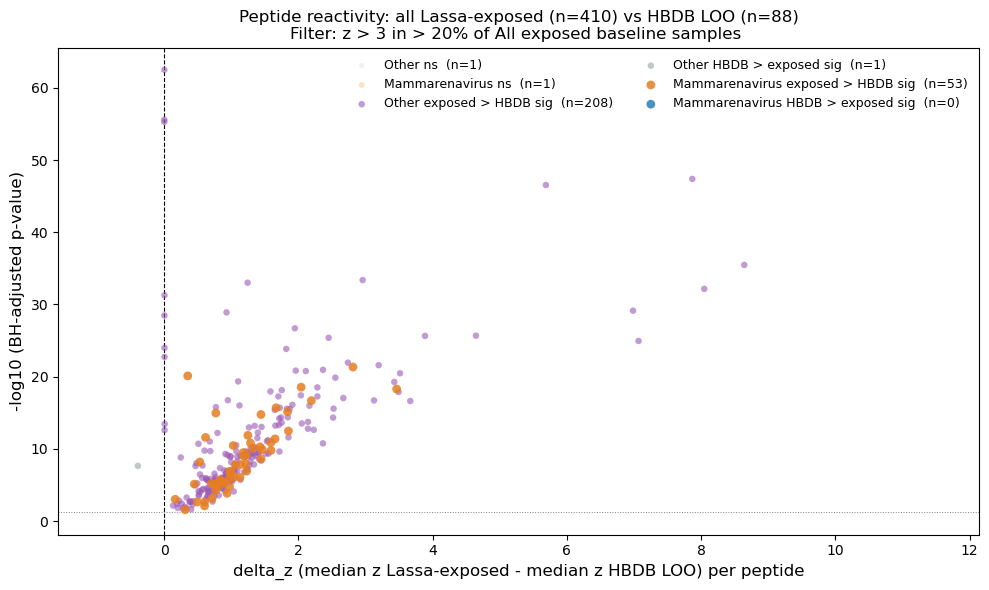

In [13]:
#plotting

MIN_FRAC = 0.2 # baseline fraction cutoff

#only plot peptides that are reactive in >30% of baseline samples
res_plot = res_exposed_hbdb[res_exposed_hbdb['frac_enriched'] > MIN_FRAC].copy()

# -------------------- volcano (single panel, data-driven x range) --------------------
is_mm = res_plot['is_mm']
is_sig = res_plot['pval_adj'] < SIG_FDR
is_up = res_plot['delta_z'] > 0

specs = [
    (~is_mm & ~is_sig, '#dddddd', 15, 0.4, 'Other ns'),
    (is_mm & ~is_sig, '#f5d07a', 18, 0.5, 'Mammarenavirus ns'),
    (~is_mm & is_sig & is_up, '#9b59b6', 22, 0.6, 'Other exposed > HBDB sig'),
    (~is_mm & is_sig & ~is_up, '#95a5a6', 22, 0.6, 'Other HBDB > exposed sig'),
    (is_mm & is_sig & is_up, '#e67e22', 40, 0.85, 'Mammarenavirus exposed > HBDB sig'),
    (is_mm & is_sig & ~is_up, '#2980b9', 40, 0.85, 'Mammarenavirus HBDB > exposed sig'),
]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for mask, col, sz, al, lbl in specs:
    sub = res_plot[mask]
    ax.scatter(
        sub['delta_z'],
        sub['neg_log10_p'],
        c=col,
        s=sz,
        alpha=al,
        edgecolors='none',
        label=f"{lbl}  (n={len(sub):,})",
        zorder=3,
    )

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axhline(-np.log10(SIG_FDR), color='grey', lw=0.7, ls=':')

x = res_plot['delta_z'].replace([np.inf, -np.inf], np.nan).dropna()
if len(x) > 0:
    lo, hi = np.quantile(x, [0.01, 0.99])
    pad = max((hi - lo) * 0.15, 0.5)
    ax.set_xlim(lo - pad, hi + pad)

n_exposed_all = baseline_z_mat.shape[1]
n_hbdb = len(hbdb_cols_z)
ax.set_xlabel('delta_z (median z Lassa-exposed - median z HBDB LOO) per peptide', fontsize=12)
ax.set_ylabel('-log10 (BH-adjusted p-value)', fontsize=12)
ax.set_title(
    f"Peptide reactivity: all Lassa-exposed (n={n_exposed_all}) vs HBDB LOO (n={n_hbdb})\n"
    f"Filter: z > {Z_THRESH:g} in > {int(MIN_FRAC * 100)}% of "
    f"All exposed baseline samples ",
    fontsize=12,
 )
ax.legend(fontsize=9, frameon=False, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

# -------------------- enriched peptide lists --------------------

cols_out = [
    'species', 'species', 'sequence', 'genus', 'family', 'protein_name', 'fragment',
    'median_z_exposed', 'median_z_hbdb', 'delta_z', 'pval_adj', 'frac_enriched'
 ]

sig_up = (
    res_exposed_hbdb[
        (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
        (res_exposed_hbdb['delta_z'] > 0)
    ]
    .sort_values('delta_z', ascending=False)
)
sig_down = (
    res_exposed_hbdb[
        (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
        (res_exposed_hbdb['delta_z'] < 0)
    ]
    .sort_values('delta_z', ascending=True)
)

#### identify the top peptides, so the ones which the highest delta_z in the cohort and shared by > 20% of the Sierra Leonean cohort

In [14]:
#res_exposed_hbdb.sort_values(by=['median_z_exposed','frac_enriched'], ascending=False).head(30)
#res_exposed_hbdb.sort_values(by='median_z_hbdb', ascending=False).head(30)

### look at the non-significant peptides out of curiosity

In [15]:
#select peptides which are not significant

non_sig_peps_w_metadata = protein_metadata.loc[~protein_metadata.seq_id.isin(res_exposed_hbdb.index)] #this ~ only works on boolean

In [16]:
baseline_z_mat.loc[baseline_z_mat.index.isin(non_sig_peps_w_metadata.seq_id)].mean(axis=1)

peptide
WFG38033.1|nucleoprotein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_13                                     0.0
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_26                                           0.0
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_59                                           0.0
XRB79013.1|polymerase|Mammarenavirus_wenzhouense|H2024-1|Mus_musculus|China|2024|?|?|tile_31                                             0.0
XQN12074.1|precursor|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|S|Candid_#1|tile_21                                          0.0
                                                                                                                                        ... 
YP_009091834.1|phosphoprotein|Ghana_virus|isolate=BatPV/Eid_hel/GH-M74a/GHA/2009|Eidolon_helvum|Ghana|2009|segment=?|strain=?|tile_28    0.0
YP_00

In [ ]:
z_hbdb_loo_df.loc[z_hbdb_loo_df.index.isin(non_sig_peps_w_metadata.seq_id)].head(2)

,HBDB-001,HBDB-010,HBDB-021,HBDB-030,HBDB-038,HBDB-047,HBDB-055,HBDB-064,HBDB-002,HBDB-003,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
peptide,,,,,,,,,,,,,,,,,,,,,
WFG38033.1|nucleoprotein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XRB79013.1|polymerase|Mammarenavirus_wenzhouense|H2024-1|Mus_musculus|China|2024|?|?|tile_31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XQN12074.1|precursor|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|S|Candid_#1|tile_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP_009091834.1|phosphoprotein|Ghana_virus|isolate=BatPV/Eid_hel/GH-M74a/GHA/2009|Eidolon_helvum|Ghana|2009|segment=?|strain=?|tile_28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YP_009091836.1|protein|Ghana_virus|isolate=BatPV/Eid_hel/GH-M74a/GHA/2009|Eidolon_helvum|Ghana|2009|segment=?|strain=?|tile_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YP_009091836.1|protein|Ghana_virus|isolate=BatPV/Eid_hel/GH-M74a/GHA/2009|Eidolon_helvum|Ghana|2009|segment=?|strain=?|tile_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
z_hbdb_loo_df.loc[z_hbdb_loo_df.index.isin(non_sig_peps_w_metadata.seq_id)].mean(axis=1)

peptide
WFG38033.1|nucleoprotein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_13                                    NaN
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_26                                          NaN
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_59                                          NaN
XRB79013.1|polymerase|Mammarenavirus_wenzhouense|H2024-1|Mus_musculus|China|2024|?|?|tile_31                                            NaN
XQN12074.1|precursor|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|S|Candid_#1|tile_21                                         NaN
                                                                                                                                         ..
YP_009091834.1|phosphoprotein|Ghana_virus|isolate=BatPV/Eid_hel/GH-M74a/GHA/2009|Eidolon_helvum|Ghana|2009|segment=?|strain=?|tile_28   NaN
YP_009091836

In [ ]:
exposed.loc[exposed.index.isin(non_sig_peps_w_metadata.seq_id)].mean(axis=1).head(2)

peptide
WFG38033.1|nucleoprotein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_13                                                     0.000826
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_26                                                           0.000770
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_59                                                           0.000126
XRB79013.1|polymerase|Mammarenavirus_wenzhouense|H2024-1|Mus_musculus|China|2024|?|?|tile_31                                                             0.000019
XQN12074.1|precursor|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|S|Candid_#1|tile_21                                                          0.000000
XQN12072.1|protein|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|L|Candid_#1|tile_4                                                             0.001137
XQN12073.1|polymeras

In [ ]:
df_hbdb.loc[df_hbdb.index.isin(non_sig_peps_w_metadata.seq_id)].mean(axis=1).head(2)

peptide
WFG38033.1|nucleoprotein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_13                                                     0.0
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_26                                                           0.0
WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|L|?|tile_59                                                           0.0
XRB79013.1|polymerase|Mammarenavirus_wenzhouense|H2024-1|Mus_musculus|China|2024|?|?|tile_31                                                             0.0
XQN12074.1|precursor|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|S|Candid_#1|tile_21                                                          0.0
XQN12072.1|protein|Mammarenavirus_juninense|?|Homo_sapiens|Argentina|1980|L|Candid_#1|tile_4                                                             0.0
XQN12073.1|polymerase|Mammarenavirus_juninense|?|H

## Do Fisher's exact test for each species to see if each species has more significant peptides than expected by chance (don't know how useful because antibody reactivity is very specific so if I see high enrichment for a peptide then that's probably a real signal -> can confirm with peptide ELISA)

In [21]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0) #significant for exposed
].index


In [22]:
peptide_table = protein_metadata[['seq_id', 'species']].set_index('seq_id')
peptide_table['is_sig'] = peptide_table.index.isin(sig_peps)

In [23]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

N = len(peptide_table)
K = peptide_table["is_sig"].sum()

species_stats = (
    peptide_table
    .groupby('species')["is_sig"] #groups by species but takes the column is_sig with it
    .agg(k_sig="sum", n_total='size') #only sums if is_sig is true, and size is just the total num of peptides in that species group
    .reset_index()
)

pvals = []
odds = []

for _, r in species_stats.iterrows():
    k = int(r["k_sig"])
    n = int(r["n_total"])
    table = [[k, n - k], [K - k, (N - n) - (K - k)]] # 2 X 2 table
    oratio, p = fisher_exact(table, alternative = "greater")
    odds.append(oratio)
    pvals.append(p)

species_stats["odds_ratio"] = odds
species_stats["p_fisher"] = pvals
species_stats["q_fdr"] = multipletests(species_stats["p_fisher"], method="fdr_bh")[1]
species_stats["sig_fraction"] = species_stats["k_sig"] / species_stats["n_total"]

species_stats = species_stats.sort_values(["q_fdr", "odds_ratio"], ascending=[True, False])
species_stats.head(30)


,species,k_sig,n_total,odds_ratio,p_fisher,q_fdr,sig_fraction
100,Mammarenavirus choriomeningitidis,1062,2267,1.296034,7.866420e-10,3.067904e-07,0.468461
331,Rubivirus rubellae,171,313,1.762702,3.911025e-07,7.626499e-05,0.546326
180,Orthohantavirus sp.,2912,6731,1.123706,2.896951e-06,3.766037e-04,0.432625
104,Mammarenavirus guanaritoense,152,296,1.544222,1.225995e-04,1.195345e-02,0.513514
140,Mobatvirus dakrongense,84,158,1.659727,9.719431e-04,4.748858e-02,0.531646
146,Mobatvirus xuansonense,102,195,1.603858,6.425446e-04,4.748858e-02,0.523077
168,Orthoflavivirus flavi,179,366,1.400269,8.121235e-04,4.748858e-02,0.489071
130,Mammarenavirus sp.,433,949,1.228534,9.741248e-04,4.748858e-02,0.456270
378,Wufeng shrew orthonairovirus 3,111,217,1.531324,1.098305e-03,4.759320e-02,0.511521
327,Rhipicephalus associated phlebovirus 1,61,113,1.714830,2.817252e-03,1.098728e-01,0.539823


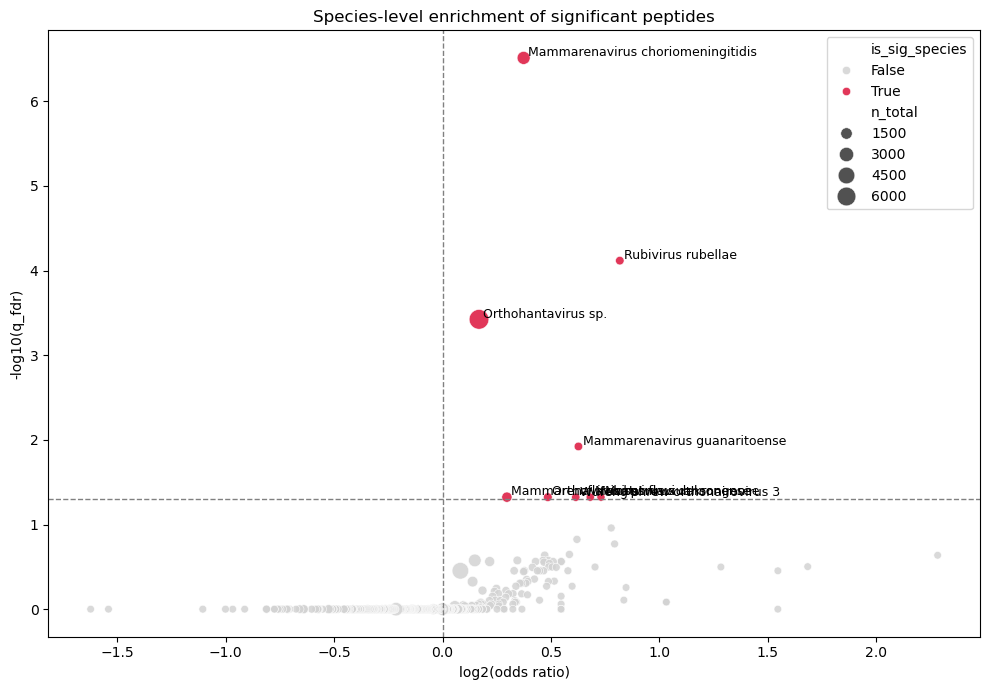

In [24]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = species_stats.copy()


#define significant species
plot_df["is_sig_species"] = (plot_df["q_fdr"] < 0.05) & (plot_df["odds_ratio"] > 1.0)


plot_df["log2_or"] = np.log2(plot_df["odds_ratio"].replace(0, np.nan))
plot_df["neglog10_q"] = -np.log10(plot_df["q_fdr"].clip(lower=1e-300))

# volcano-style species enrichment plot
plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    data=plot_df, 
    x="log2_or", 
    y="neglog10_q", 
    hue="is_sig_species", 
    palette={True: "crimson", False: "lightgray"},
    size="n_total", 
    sizes=(30, 200), 
    alpha=0.85
)

plt.axhline(-np.log10(0.05), ls="--", lw=1, color="gray")
plt.axvline(0, ls="--", lw=1, color="gray")

for _, r in plot_df[plot_df["is_sig_species"]].iterrows():
    ax.text(
        r["log2_or"] + 0.02, 
        r["neglog10_q"] + 0.02, 
        r["species"], 
        fontsize=9
    )
    
plt.xlabel("log2(odds ratio)")
plt.ylabel("-log10(q_fdr)")
plt.title("Species-level enrichment of significant peptides")
plt.tight_layout()
plt.show()

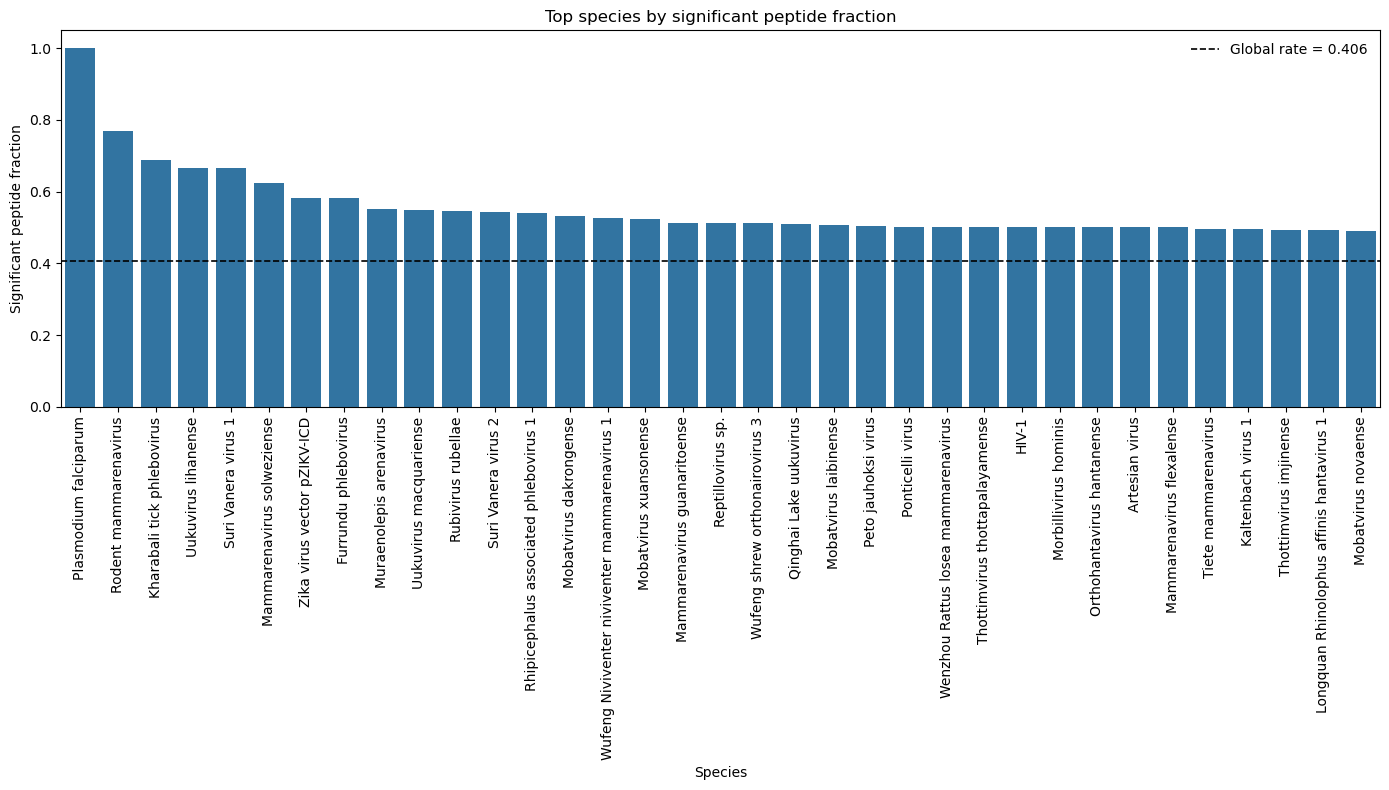

In [25]:
# 2) Fraction bar plot with global baseline
global_rate = plot_df["k_sig"].sum() / plot_df["n_total"].sum()
top = plot_df.sort_values("sig_fraction", ascending=False).head(35)

plt.figure(figsize=(14, 8))
sns.barplot(data=top, x="species", y="sig_fraction", hue="genus" if "genus" in top.columns else None, dodge=False)
plt.axhline(global_rate, ls="--", lw=1.2, color="black", label=f"Global rate = {global_rate:.3f}")
plt.xticks(rotation=90)
plt.ylabel("Significant peptide fraction")
plt.xlabel("Species")
plt.title("Top species by significant peptide fraction")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Visualize the top_hits which pass significance threshold, delta_z > 0 and are enriched in more than 20% of exposed

In [26]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0) & 
    (res_exposed_hbdb['frac_enriched'] > 0.2)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

Top hits (frac_enriched > 20%, FDR-sig, Δz > 0):  n = 261
     


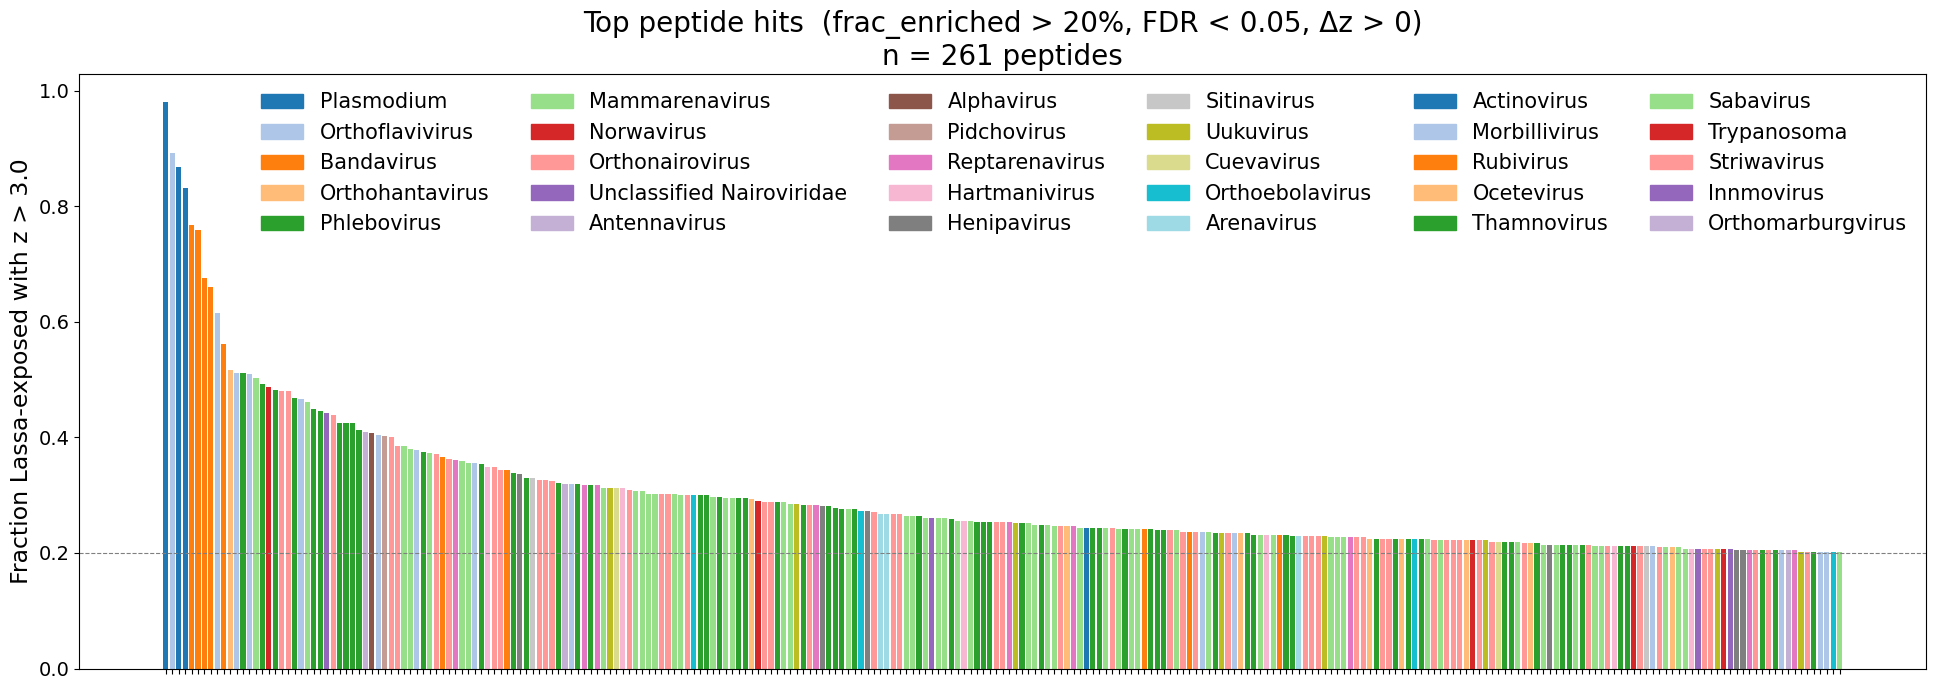

In [27]:
# ── Visualise top peptide hits: frac_enriched > 1% %, FDR-sig, Δz > 0 ────────
#
# Two panels:
#  1. Ranked bar chart — peptides sorted by frac_enriched, coloured by genus
#  2. Z-score heatmap  — Lassa-exposed samples (cols) × top peptides (rows)
#     Rows annotated by protein_name and genus; samples annotated by group.

import seaborn as sns
import matplotlib.patches as mpatches

FRAC_MIN = 0.2   # minimum fraction of Lassa-exposed with z > Z_THRESH

# z-score reactivity threshold for the filter == 3
SIG_FDR  = 0.05   # FDR threshold for volcano colouring

# ── filter ────────────────────────────────────────────────────────────────────

print(f'Top hits (frac_enriched > {int(FRAC_MIN*100)}%, FDR-sig, Δz > 0):  n = {len(top_hits)}')
print(top_hits[['protein_name', 'sequence', 'genus', 'species', 'frac_enriched',
                'delta_z', 'pval_adj']].to_string()[:5])


#color palette for genus
genera = top_hits['genus'].fillna('unknown').unique()
palette = sns.color_palette('tab20', n_colors=len(genera))
genus_pal = dict(zip(genera, palette))

if len(top_hits) == 0:
    print('No peptides pass the filter — try lowering FRAC_MIN or SIG_FDR.')
else:

    # ── Panel 1: ranked bar chart ─────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(20, 7))
    bar_colors = [genus_pal[g] for g in top_hits['genus'].fillna('unknown')]
    ax1.bar(range(len(top_hits)), top_hits['frac_enriched'], color=bar_colors, edgecolor='none')
    ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
    ax1.set_xticks(range(len(top_hits)))
    """ax1.set_xticklabels(
        [f"{r['species_corr']}"
         for _, r in top_hits.iterrows()],
        rotation=90, fontsize=15)"""
    ax1.set_xticklabels([])
    ax1.set_ylabel(f'Fraction Lassa-exposed with z > {Z_THRESH}', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_title(
        f'Top peptide hits  (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0)\n'
        f'n = {len(top_hits)} peptides',
        fontsize=20)
    legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
    ax1.legend(handles=legend_patches, fontsize=15, frameon=False,
               loc='upper right', ncol=max(1, len(genera)//5))
    plt.tight_layout()
    plt.show()

### now repeat the barplot but for the healthies to really show the contrast 

In [28]:
print(len(top_hits))

#subset to top_hits in exposed 
hbdb_comparison = z_hbdb_loo_df.loc[top_hits.index, :]

#hbdb_comparison.head()

261


In [29]:
#calculating the fraction of healthies passing z score threshold for those peptides 

n_healthies = len(hbdb_comparison.columns)

print(n_healthies)

fraction_hbdb_comparison = ((hbdb_comparison > 3).sum(axis=1) / n_healthies)

fraction_hbdb_comparison.head(2)

#fraction_hbdb_comparison.values, fraction_hbdb_comparison.index

88


peptide
PF3D7_0501400.1-p1|transcript=PF3D7_0501400.1|organism=Plasmodium_falciparum_3D7|gene_product=interspersed_repeat_antigen|tile_1    0.034091
UHI99942.1|polyprotein|Zika_virus|isolate=GO24|Homo_sapiens|Brazil:_Goiania-_Goais|01-Apr-2016|segment=?|strain=?|tile_144          0.022727
dtype: float64

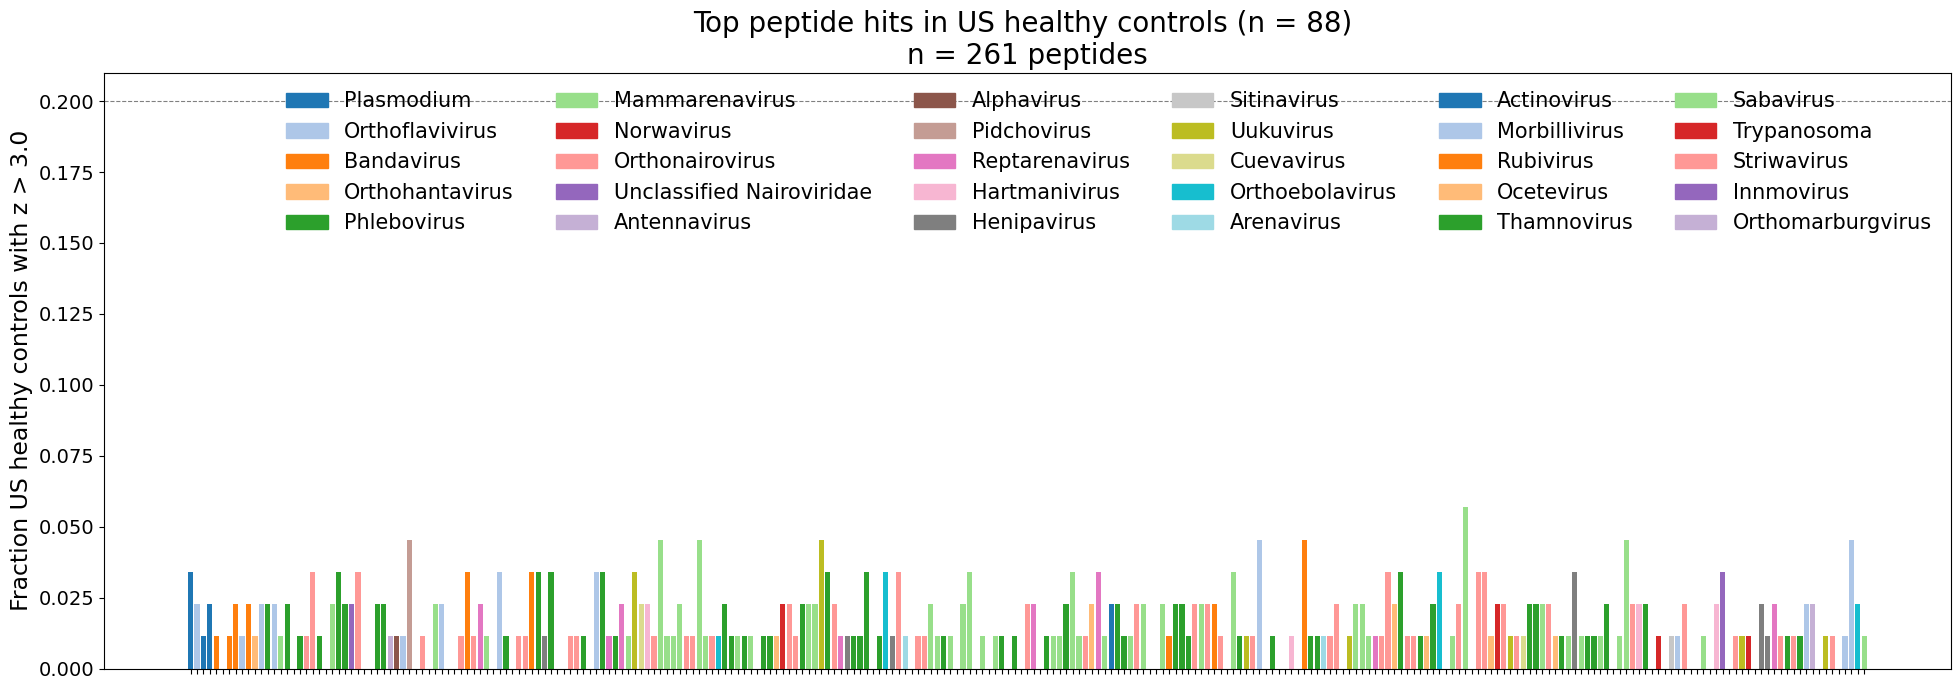

In [30]:
fig1, ax1 = plt.subplots(figsize=(20, 7))
bar_colors = [genus_pal[g] for g in top_hits['genus'].fillna('unknown')]
ax1.bar(range(len(fraction_hbdb_comparison)), fraction_hbdb_comparison.values, color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(top_hits)))
"""ax1.set_xticklabels(
    [f"{r['species_corr']}"
        for _, r in top_hits.iterrows()],
    rotation=90, fontsize=15)"""
ax1.set_xticklabels([])
ax1.set_ylabel(f'Fraction US healthy controls with z > {Z_THRESH}', fontsize=17)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_title(
    f'Top peptide hits in US healthy controls (n = {n_healthies}) \n'
    f'n = {len(top_hits)} peptides',
    fontsize=20)
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
ax1.legend(handles=legend_patches, fontsize=15, frameon=False,
            loc='upper right', ncol=max(1, len(genera)//5))
plt.tight_layout()
plt.show()

### now combining the plots above 

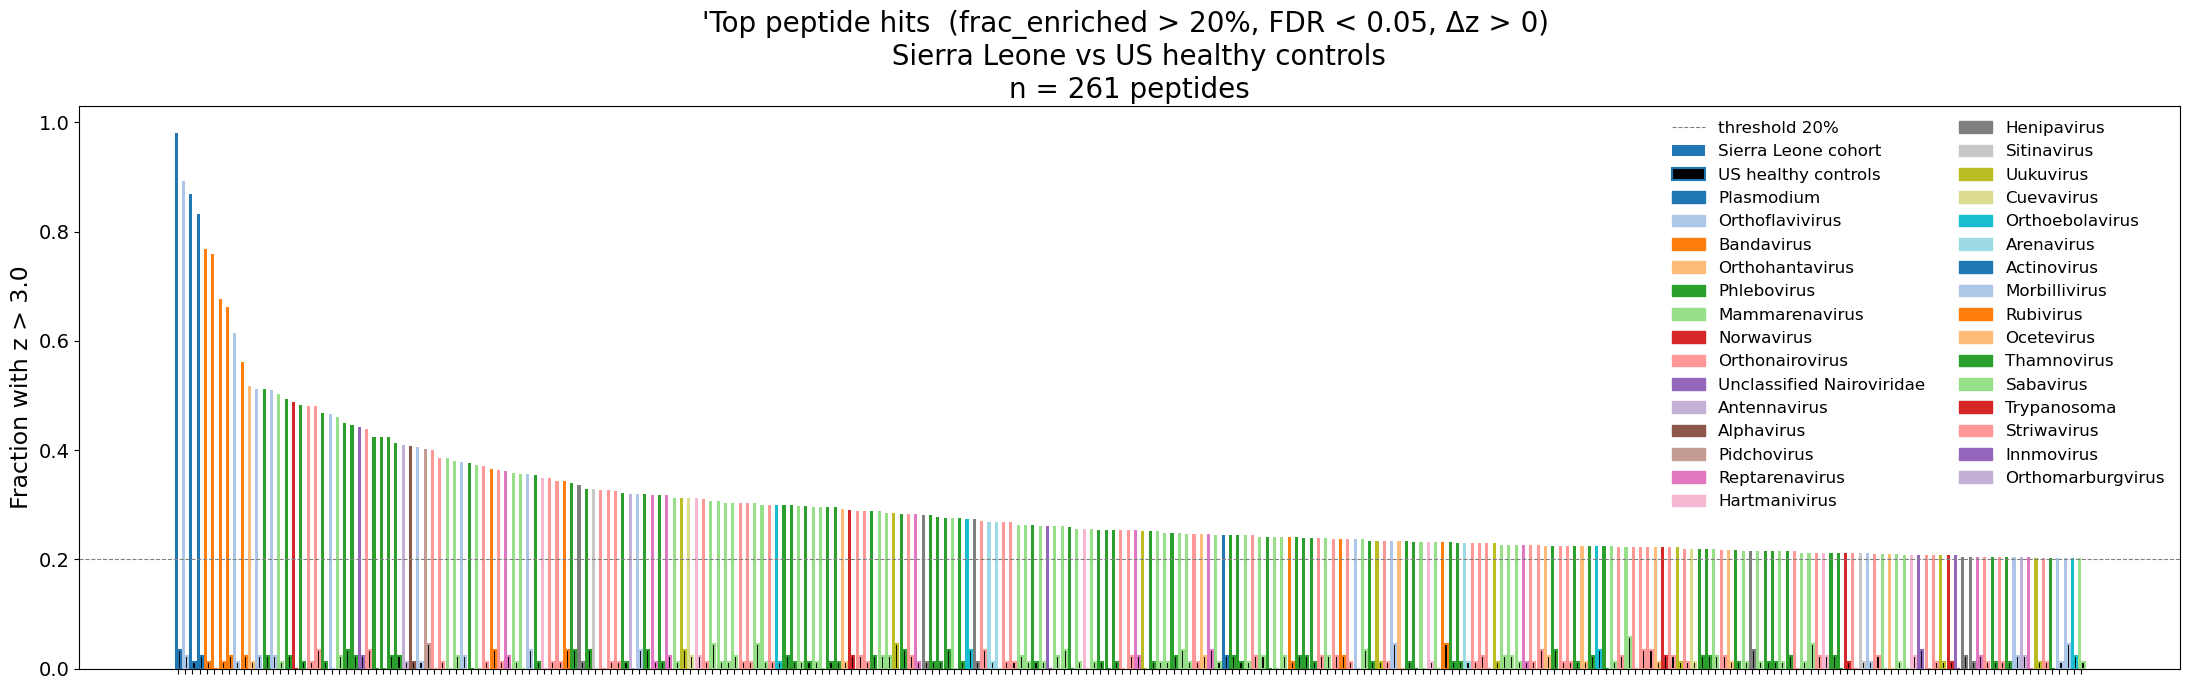

In [31]:
plot_df = top_hits.copy()

plot_df["frac_us_healthies"] = np.asarray(fraction_hbdb_comparison)

plot_df["frac_cohort"] = plot_df["frac_enriched"]

genera = plot_df["genus"].fillna("unknown").unique()
palette = sns.color_palette("tab20", n_colors=len(genera))
genus_pal = dict(zip(genera, palette))

bar_colors = [genus_pal[g] for g in plot_df["genus"].fillna("unknown")]

x = np.arange(len(plot_df))
width = 0.42

fig, ax1 = plt.subplots(figsize=(22, 7))

ax1.bar(
    x - width/2,
    plot_df["frac_cohort"],
    width=width,
    color=bar_colors,
    edgecolor="none",
    label="Sierra Leone cohort"
)

ax1.bar(
    x + width/2,
    plot_df["frac_us_healthies"],
    width=width,
    color="black",
    edgecolor=bar_colors,
    linewidth=1.5,
    label="US healthy controls"
)

ax1.axhline(FRAC_MIN, color="grey", lw=0.8, ls="--", label=f"threshold {int(FRAC_MIN*100)}%")

ax1.set_xticks(x)
ax1.set_xticklabels([])  # or add peptide labels if you want
ax1.set_ylabel(f"Fraction with z > {Z_THRESH}", fontsize=17)
ax1.tick_params(axis="y", labelsize=14)

ax1.set_title(
    f"'Top peptide hits  (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0) \n  Sierra Leone vs US healthy controls\n"
    f"n = {len(plot_df)} peptides",
    fontsize=20
)

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles + legend_patches, labels + list(genus_pal.keys()),
           fontsize=12, frameon=False, loc="upper right", ncol=2)

plt.tight_layout()
plt.show()

### Now I want to repeat the plots above, but have barplot height reflecting how many peptides of each genus are in the fraction > 0.2 group

In [32]:
top_hits_genus_peptide_sum = top_hits.groupby('genus').size() #.size() tells me how many rows ended up in that group

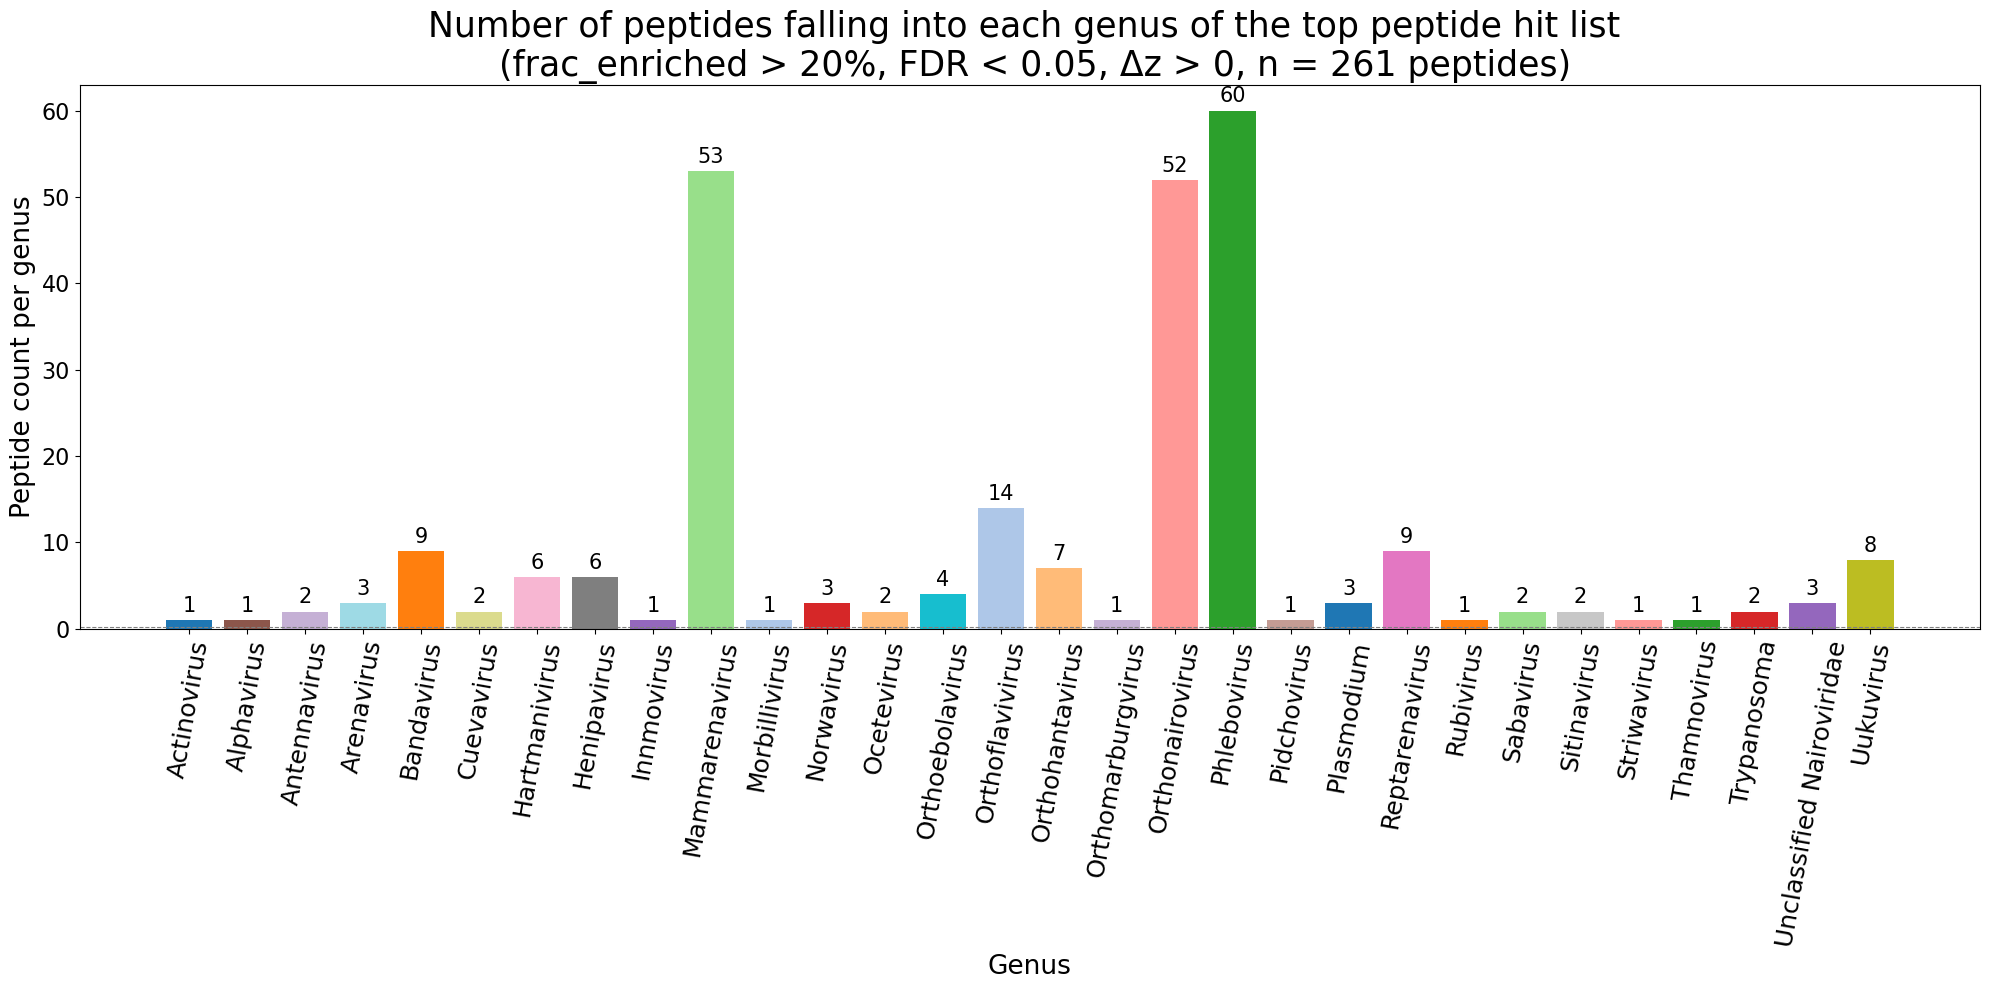

In [33]:
fig1, ax1 = plt.subplots(figsize=(20, 10))

bar_colors = [genus_pal[g] for g in top_hits_genus_peptide_sum.index]

ax1.bar(range(len(top_hits_genus_peptide_sum)), top_hits_genus_peptide_sum.values, color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(top_hits_genus_peptide_sum)))
ax1.set_xticklabels(top_hits_genus_peptide_sum.index,
    rotation=80, fontsize=18)
ax1.set_xlabel('Genus', fontsize=19)
ax1.set_ylabel('Peptide count per genus', fontsize=19)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_title(
    f'Number of peptides falling into each genus of the top peptide hit list \n (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0, n = {len(top_hits)} peptides)',
    fontsize=25)

for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=15)


plt.tight_layout()
plt.show()

### want to repeat the above plot but normalize the peptide count to total peptides for that genus

In [34]:
top_hits_genus_peptide_sum = top_hits.groupby('genus').size() # .size() tells me how many rows ended up in that group
tot_num_peps_per_genus = protein_metadata.groupby('genus').size()

peps_genus_avg = {}
for genus in top_hits_genus_peptide_sum.index:
    peps_genus_avg[genus] = (top_hits_genus_peptide_sum[genus] / tot_num_peps_per_genus[genus])

In [35]:
peps_genus_avg = pd.Series(
    peps_genus_avg, name='avg_top_hit_fraction'
)
peps_genus_avg.index.name = "genus"

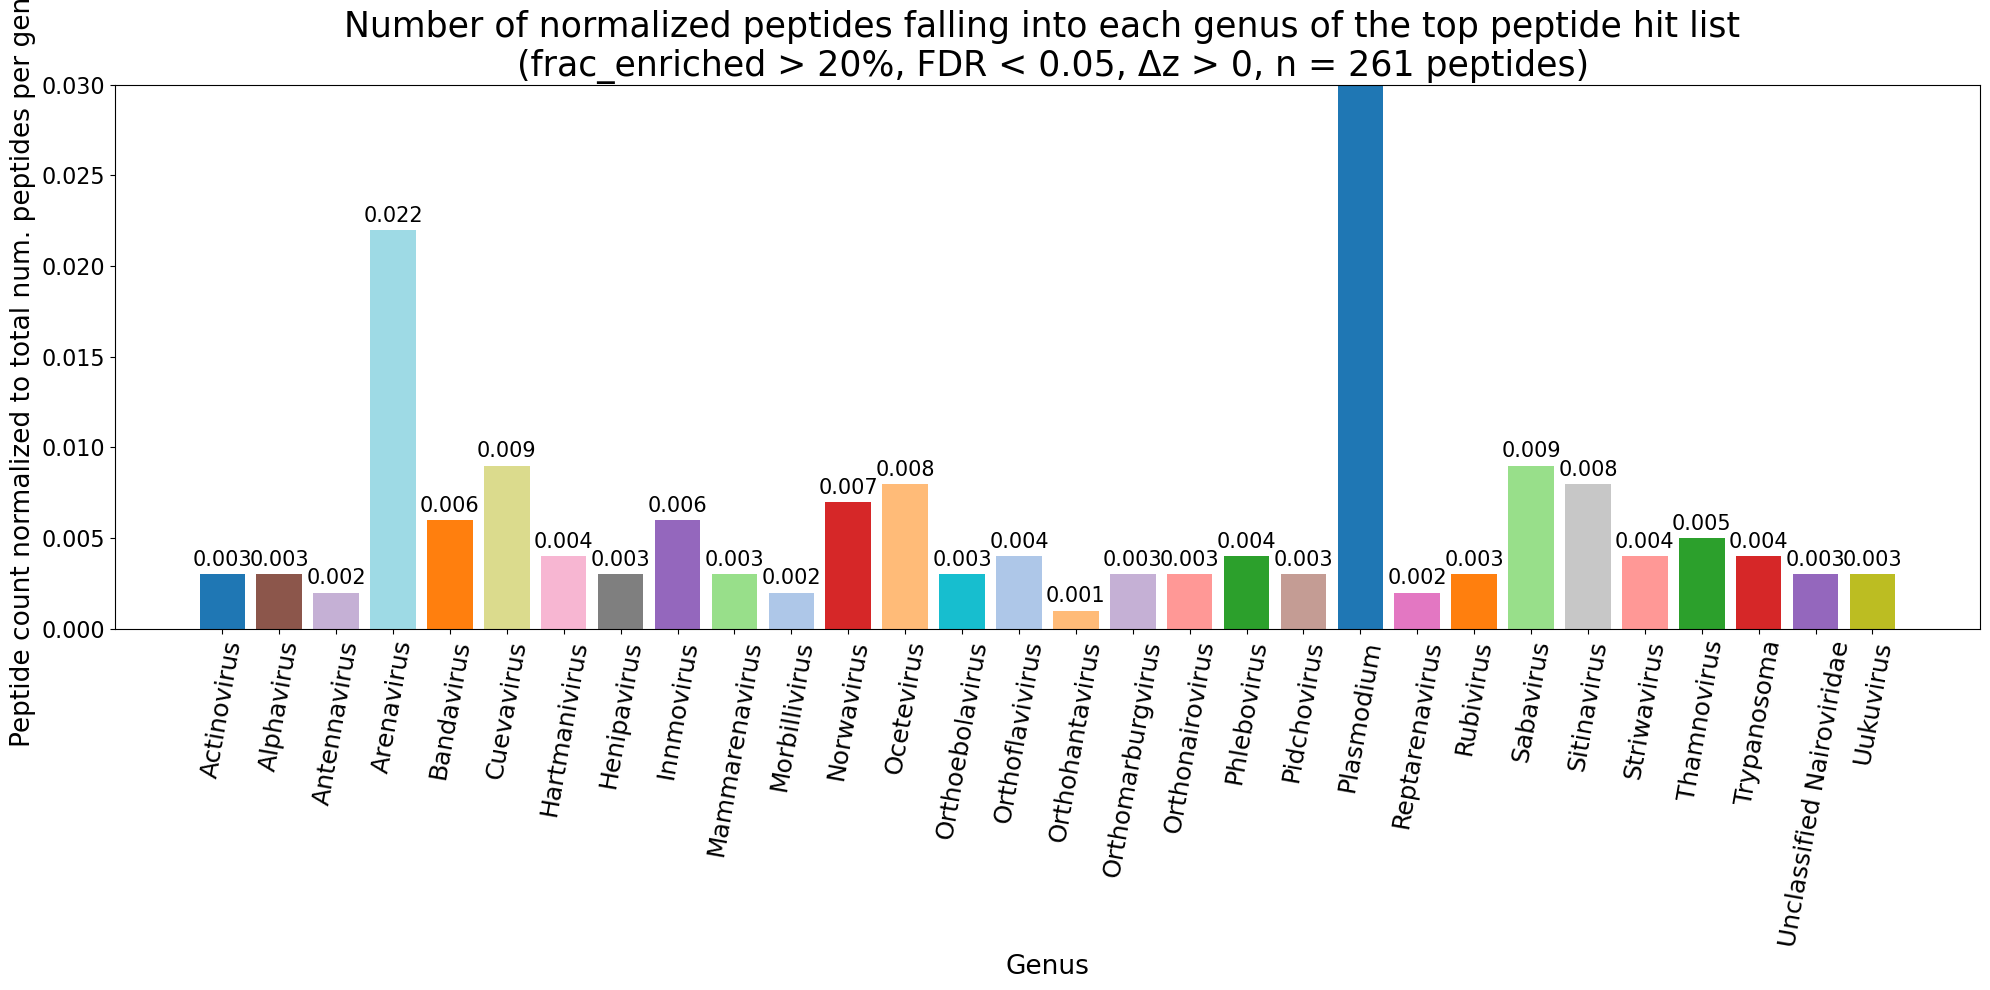

In [36]:
fig1, ax1 = plt.subplots(figsize=(20, 10))

bar_colors = [genus_pal[g] for g in peps_genus_avg.index]

ax1.bar(range(len(peps_genus_avg)), peps_genus_avg.values.round(3), color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(peps_genus_avg)))
ax1.set_xticklabels(peps_genus_avg.index,
    rotation=80, fontsize=18)
ax1.set_xlabel('Genus', fontsize=19)
ax1.set_ylabel('Peptide count normalized to total num. peptides per genus', fontsize=19)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_title(
    f'Number of normalized peptides falling into each genus of the top peptide hit list \n (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0, n = {len(top_hits)} peptides)',
    fontsize=25)

for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=15)

ax1.set_ylim(0, 0.03)

plt.tight_layout()
plt.show()

### Now I want to repeat the plots above, but have barplot height reflecting how many peptides of each species are in the fraction > 0.2 group

In [37]:
top_hits_species_peptide_sum = top_hits.groupby(['species', 'genus']).size().reset_index() #.size() tells me how many rows ended up in that group

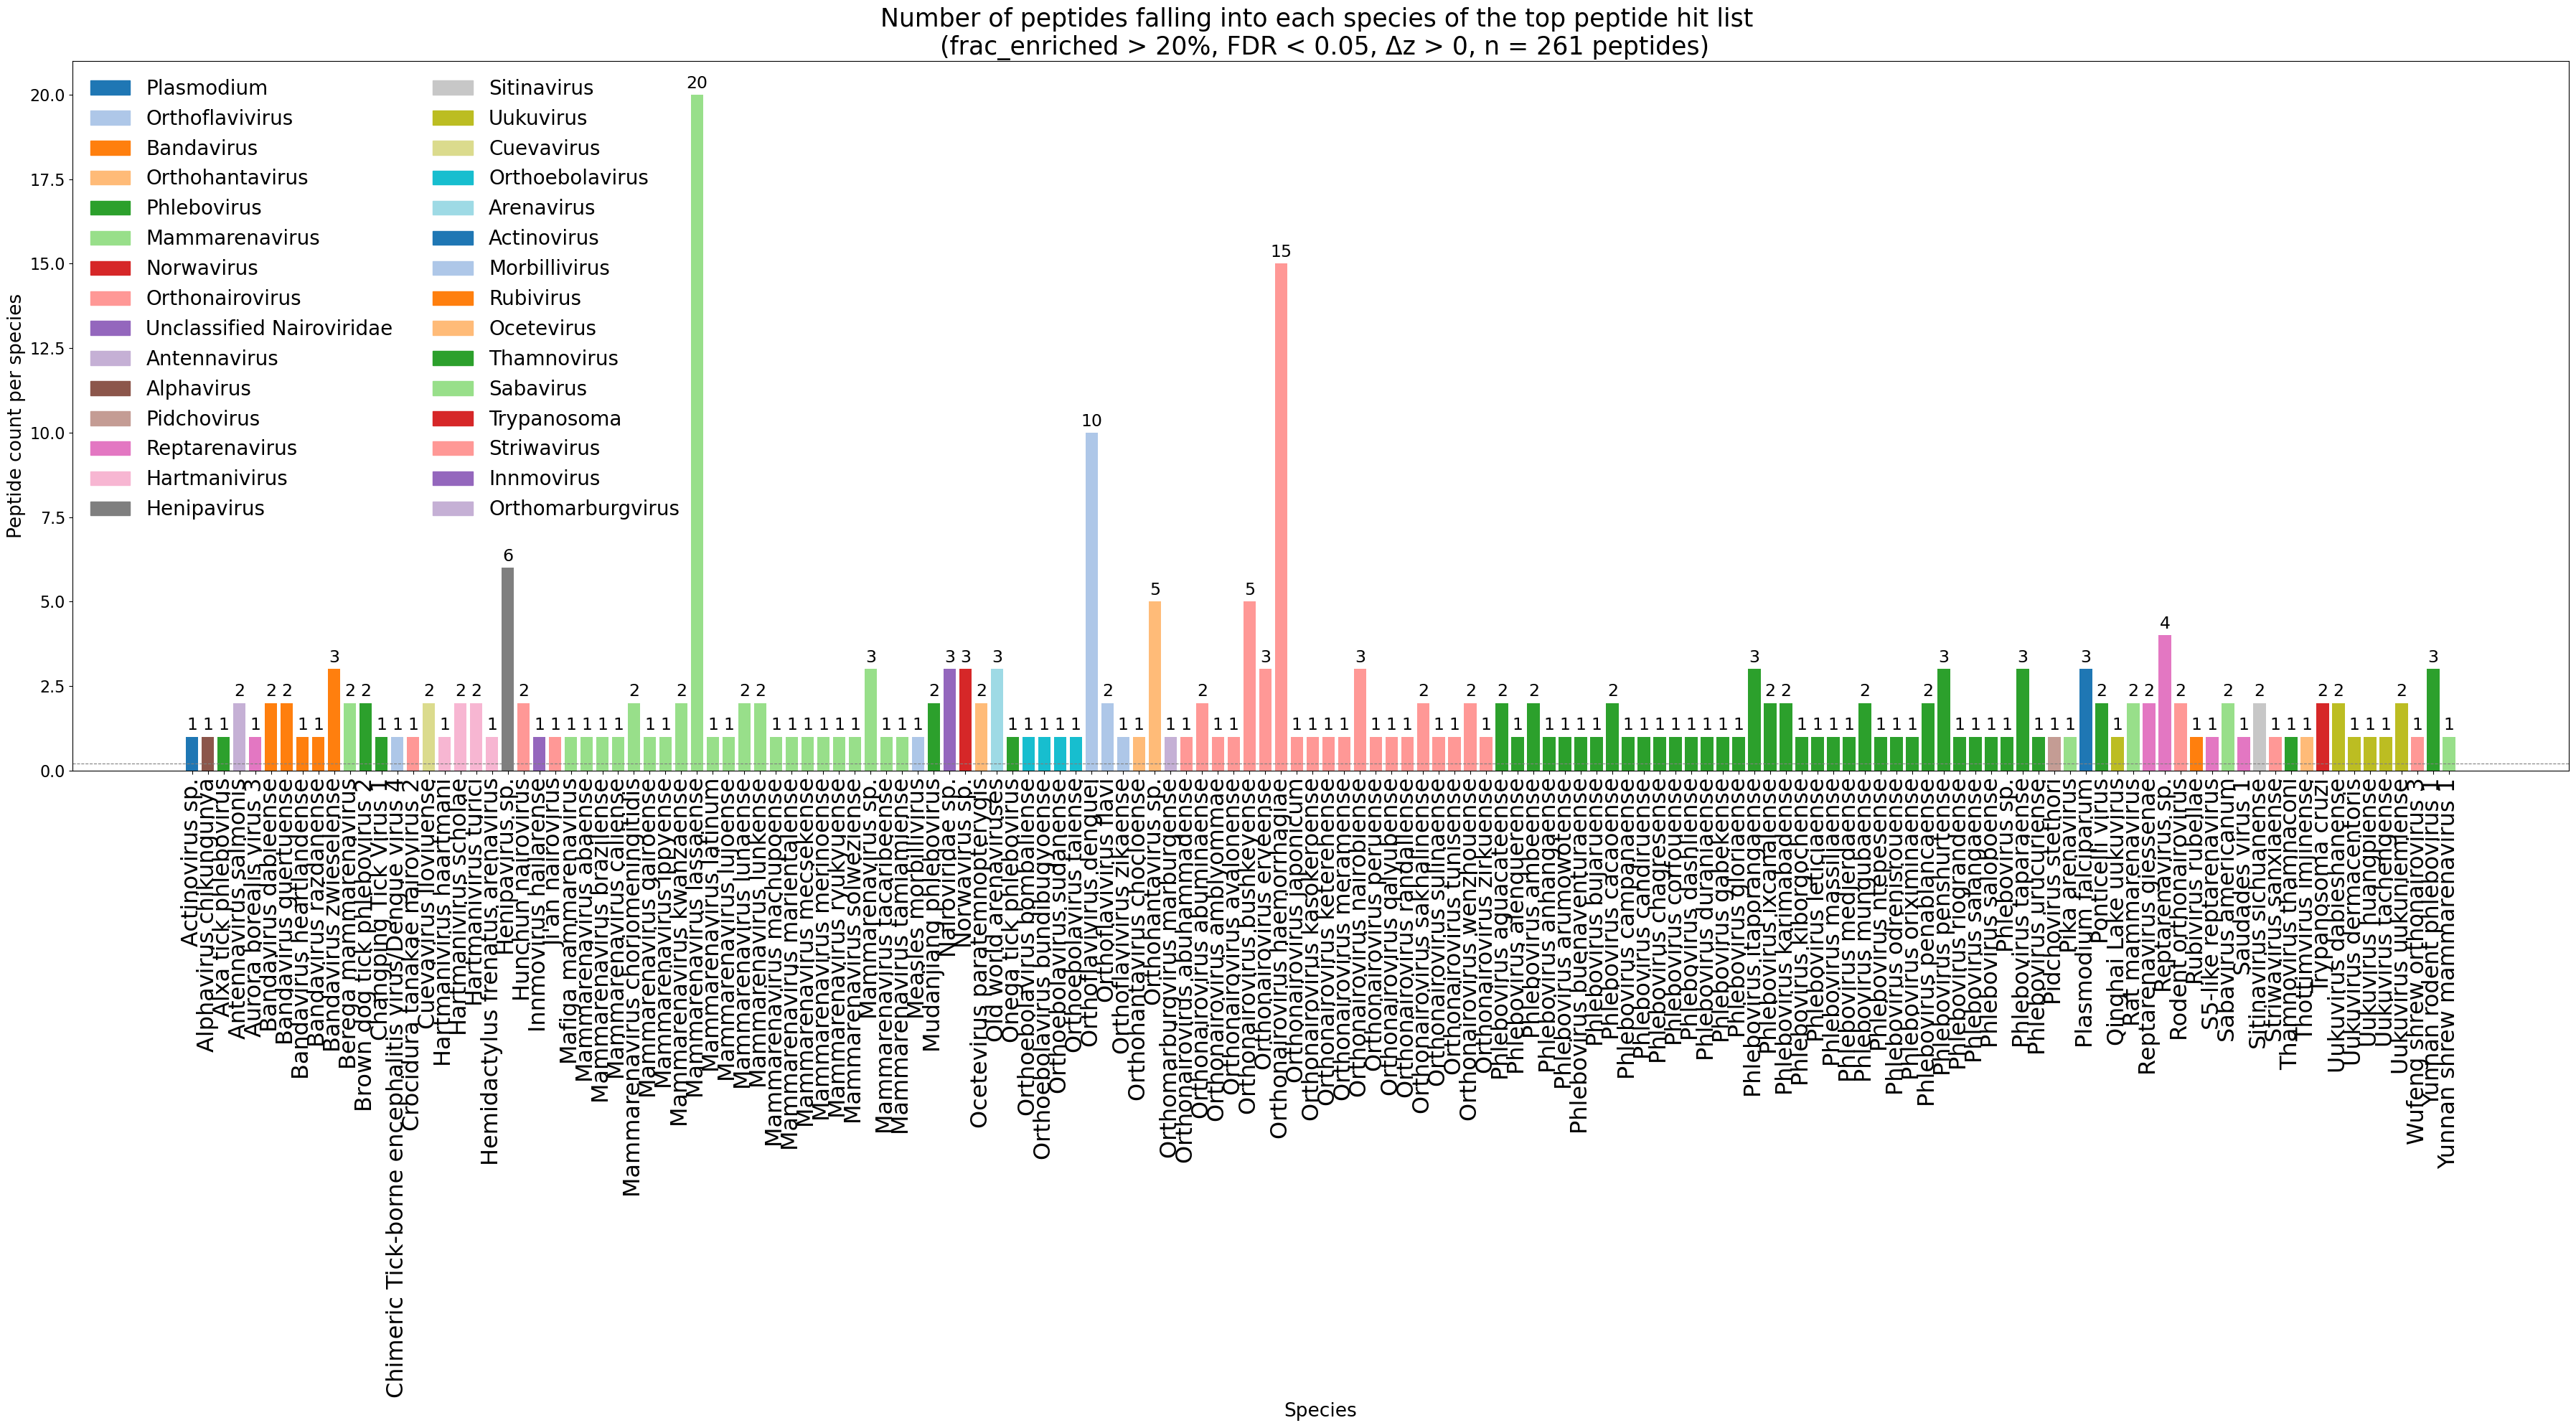

In [38]:
fig1, ax1 = plt.subplots(figsize=(36, 20))

bar_colors = [genus_pal[g] for g in top_hits_species_peptide_sum['genus']]

ax1.bar(range(len(top_hits_species_peptide_sum)), top_hits_species_peptide_sum[0], color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(top_hits_species_peptide_sum)))
ax1.set_xticklabels(top_hits_species_peptide_sum['species'],
    rotation=90, fontsize=23)
ax1.set_xlabel('Species', fontsize=19)
ax1.set_ylabel('Peptide count per species', fontsize=19)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_title(
    f'Number of peptides falling into each species of the top peptide hit list \n (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0, n = {len(top_hits)} peptides)',
    fontsize=25)

for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=17)

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
ax1.legend(handles=legend_patches, fontsize=20, frameon=False,
            loc='upper left', ncol=max(1, len(genera)//15))

plt.tight_layout()
plt.show()

### want to do the same but again normalize to total peptide counts per species in the library

In [39]:
top_hits_species_genus_sum = top_hits.groupby(['species', 'genus']).size() #tells me how many peptides end in that grouping filter
tot_num_peps_per_species = protein_metadata.groupby('species').size()

peps_species_avg = (
    top_hits_species_genus_sum
    .div(tot_num_peps_per_species, level='species')
    .fillna(0)
)

#.rename() changes the series name so the value column label
plot_df = peps_species_avg.rename("fraction").reset_index()

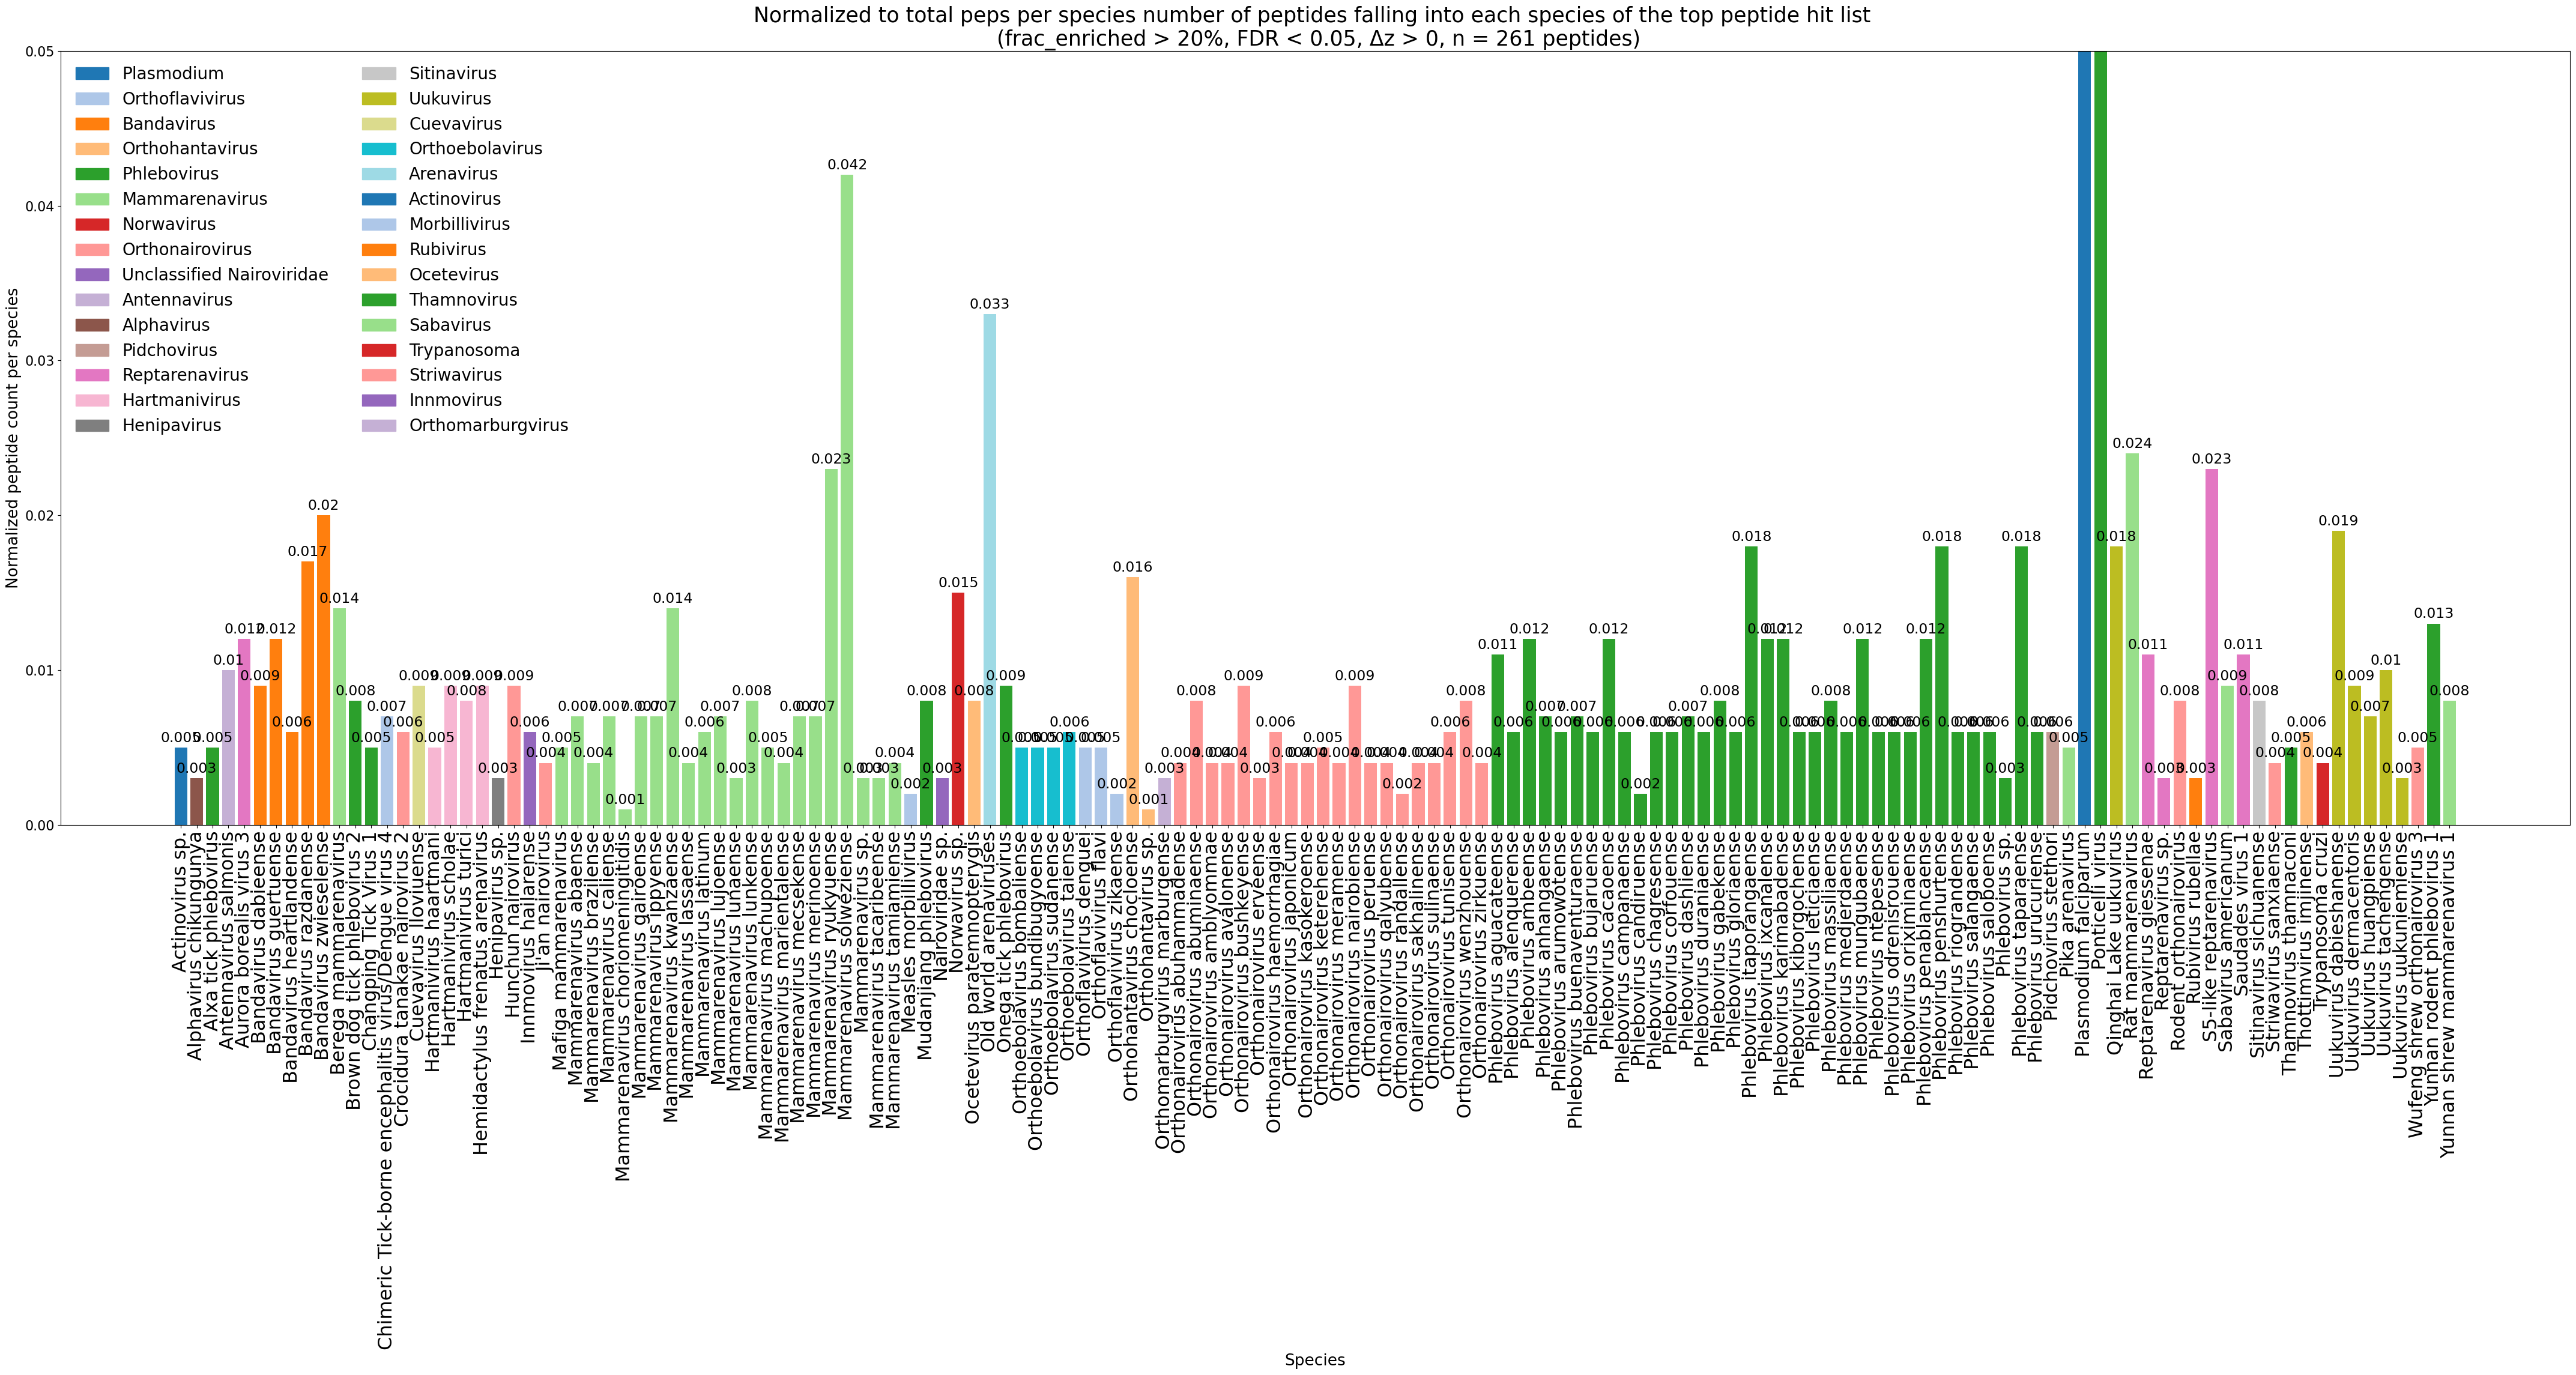

In [40]:
fig1, ax1 = plt.subplots(figsize=(43, 23))

bar_colors = [genus_pal[g] for g in plot_df['genus']]

ax1.bar(range(len(plot_df)), plot_df['fraction'].round(3), color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(plot_df)))
ax1.set_xticklabels(plot_df['species'],
    rotation=90, fontsize=23)
ax1.set_xlabel('Species', fontsize=19)
ax1.set_ylabel('Normalized peptide count per species', fontsize=19)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_title(
    f'Normalized to total peps per species number of peptides falling into each species of the top peptide hit list \n (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0, n = {len(top_hits)} peptides)',
    fontsize=25)

for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=17)

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
ax1.legend(handles=legend_patches, fontsize=20, frameon=False,
            loc='upper left', ncol=max(1, len(genera)//15))

ax1.set_ylim(0, 0.05)

plt.tight_layout()
plt.show()

### is there any sequence similarity between e.g. CCHF virus peptides in those top peptides and lassa virus peptides? 

In [45]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0) & 
    (res_exposed_hbdb['frac_enriched'] > 0.2)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

In [50]:
top_hits_by_species = top_hits.groupby('species')['sequence'].apply(list).to_dict()

In [52]:
species_of_interest = ['Orthonairovirus haemorrhagiae','Orthoflavivirus denguei', 'Mammarenavirus lassaense']

#select keys 

selected_species = {k: top_hits_by_species[k] for k in species_of_interest if k in top_hits_by_species}

In [60]:
#compare every peptide sequence to every other item in the dictionary using nested loops
from itertools import combinations
from Bio import Align

#initialize aligner
aligner = Align.PairwiseAligner()

#assign standard protein scoring substitution matrix
aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")

#configure gap penalties for petides
aligner.open_gap_score = -10.0 #starting a gap is heavily penalized
aligner.extend_gap_score = -0.5 #extending an existing gap less costly


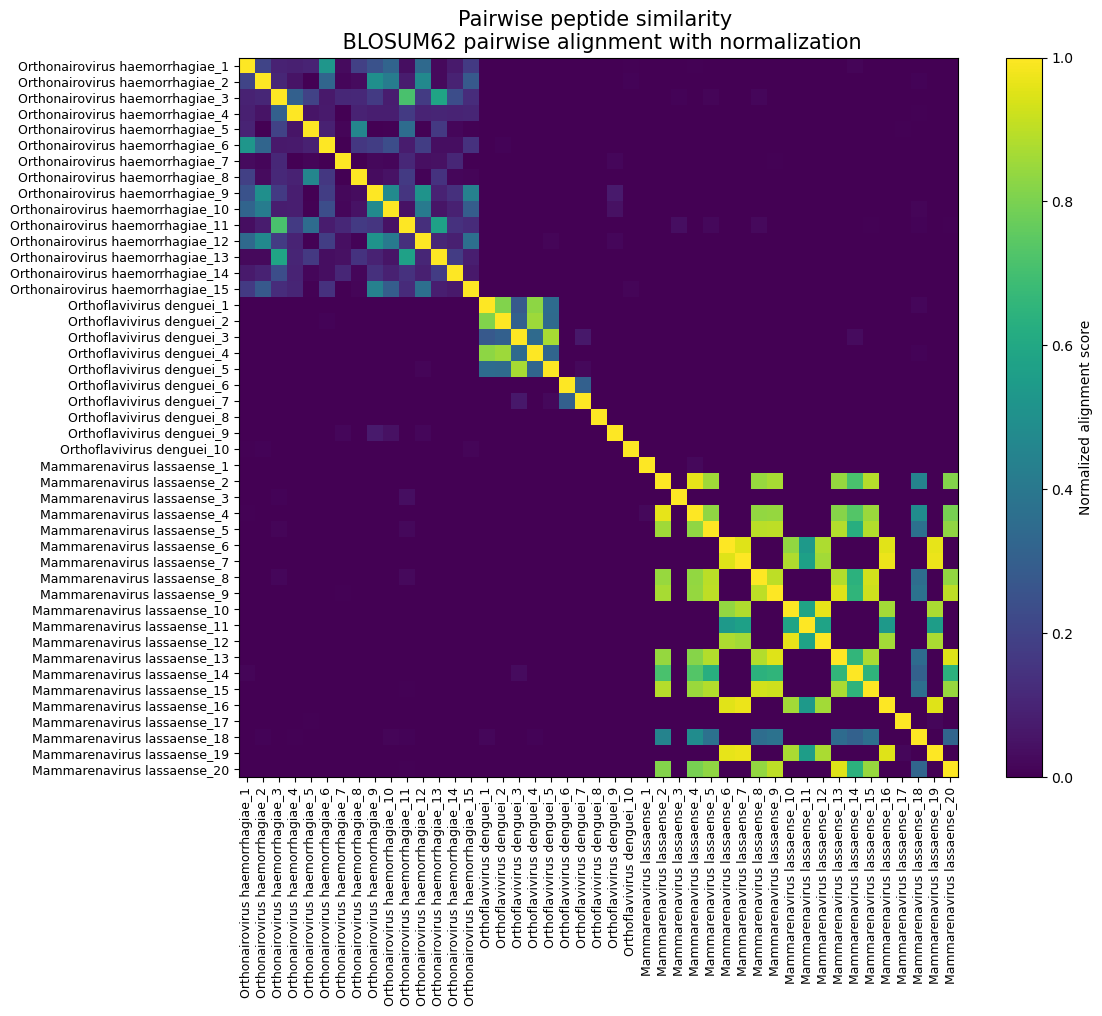

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten all peptides into one list
items = []
for species, peptides in selected_species.items():
    for i, pep in enumerate(peptides):
        items.append((f"{species}_{i+1}", pep))

names = [x[0] for x in items]
peptides = [x[1] for x in items]

n = len(items)
score_matrix = np.zeros((n, n))
norm_matrix = np.zeros((n, n))

# Self-scores for normalization
"""
we are normalizing, as raw scores won't necessarily be the same, 
even if two peptides are nearly identical as BLOSUM62 gives different match scores to different
amino acids. 

normalization is essentially the alignment score between pep1 and pep2
divided by the square root of the product of self alignment score of pep1 and the self alignment score of pep2
"""

self_scores = [aligner.score(pep, pep) for pep in peptides]

for i in range(n):
    for j in range(n):
        s = aligner.score(peptides[i], peptides[j])
        score_matrix[i, j] = s
        norm_matrix[i, j] = s / np.sqrt(self_scores[i] * self_scores[j])

plt.figure(figsize=(12, 10))
im = plt.imshow(norm_matrix, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, label="Normalized alignment score")
plt.xticks(range(n), names, rotation=90, fontsize=9)
plt.yticks(range(n), names, fontsize=9)
plt.title("Pairwise peptide similarity \n BLOSUM62 pairwise alignment with normalization", fontsize=15)
plt.tight_layout()
plt.show()

### Now I want to sum the rpk for each individual for the significant peptides per species and generate a jitterplot for visualization - comparing Sierra Leonean cohort vs healthies - do dengue, lassa and cchfv

In [65]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0) 
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

Text(0.5, 1.0, 'Summed CCHFV peptide values for US healthies')

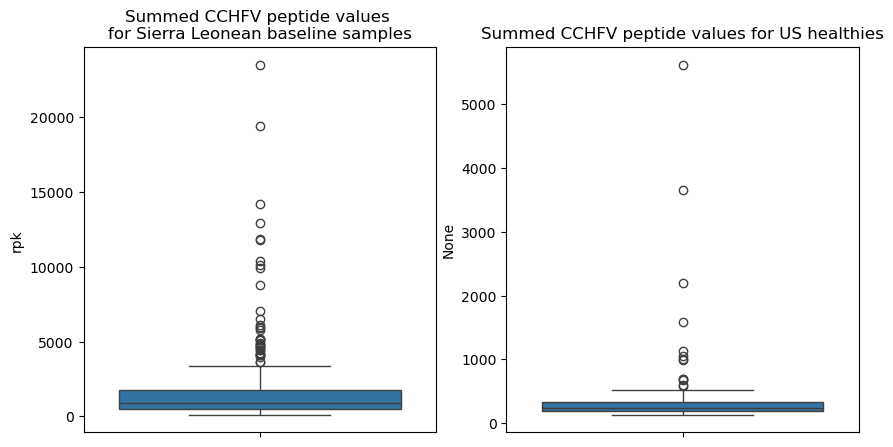

In [ ]:
#starting with cchfv

sig_peps_cchfv = top_hits.loc[top_hits['species']== "Orthonairovirus haemorrhagiae"]

#select to those peptides in RPK dataframes

baseline_cchfv = baseline_long.loc[sig_peps_cchfv.index]

hbdb_cchfv = df_hbdb.loc[sig_peps_cchfv.index]

#sum the rpk of all peptides belonging to that viral species

exposed_cchfv_rpk_sum = baseline_cchfv.groupby('sample_id')['rpk'].sum()

hbdb_cchfv_rpk_sum = hbdb_cchfv.sum(axis = 0)

#plot the summed RPKs as boxplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#plot the first boxplot on the left subplot (ax=axes[0])
sns.boxplot(y=exposed_cchfv_rpk_sum, ax=axes[0])
axes[0].set_title('Summed CCHFV peptide values \nfor Sierra Leonean baseline samples')

sns.boxplot(y=hbdb_cchfv_rpk_sum, ax=axes[1])
axes[1].set_title('Summed CCHFV peptide values for US healthies')


Text(0.5, 1.0, 'Summed LASV peptide values for US healthies')

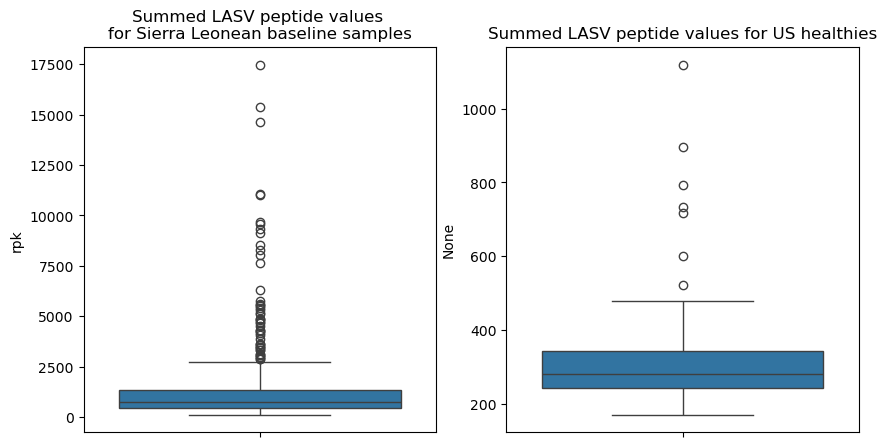

In [107]:
#starting with cchfv

sig_peps_cchfv = top_hits.loc[top_hits['species']== "Mammarenavirus lassaense"]

#select to those peptides in RPK dataframes

baseline_cchfv = baseline_long.loc[sig_peps_cchfv.index]

hbdb_cchfv = df_hbdb.loc[sig_peps_cchfv.index]

#sum the rpk of all peptides belonging to that viral species

exposed_cchfv_rpk_sum = baseline_cchfv.groupby('sample_id')['rpk'].sum()

hbdb_cchfv_rpk_sum = hbdb_cchfv.sum(axis = 0)

#plot the summed RPKs as boxplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#plot the first boxplot on the left subplot (ax=axes[0])
sns.boxplot(y=exposed_cchfv_rpk_sum, ax=axes[0])
axes[0].set_title('Summed LASV peptide values \nfor Sierra Leonean baseline samples')

sns.boxplot(y=hbdb_cchfv_rpk_sum, ax=axes[1])
axes[1].set_title('Summed LASV peptide values for US healthies')


### now I want to know to which viral proteins these viral species peptides map which are shared in >20% of cohort

-taking the species with more than 3 peptides

In [42]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0) & 
    (res_exposed_hbdb['frac_enriched'] > 0.2)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

In [43]:
#keep species with more than 3 peptide hits

species_filtered = top_hits_species_peptide_sum[top_hits_species_peptide_sum[0] > 3]

#subset peptides shared in more than 20% of cohort to those species 
top_hits_species_filtered = top_hits.loc[top_hits['species'].isin(species_filtered['species'])]

#count how many peptides fall onto each viral protein

protein_counts = (
    top_hits_species_filtered
    .groupby(['species', 'protein_name'])
    .size()
    .reset_index(name='n_peptides')

)

Text(0.5, 1.0, 'Viral species with > 3 enriched peptides to protein count \n (frac_enriched > 20%, FDR < 0.05, Δz > 0')

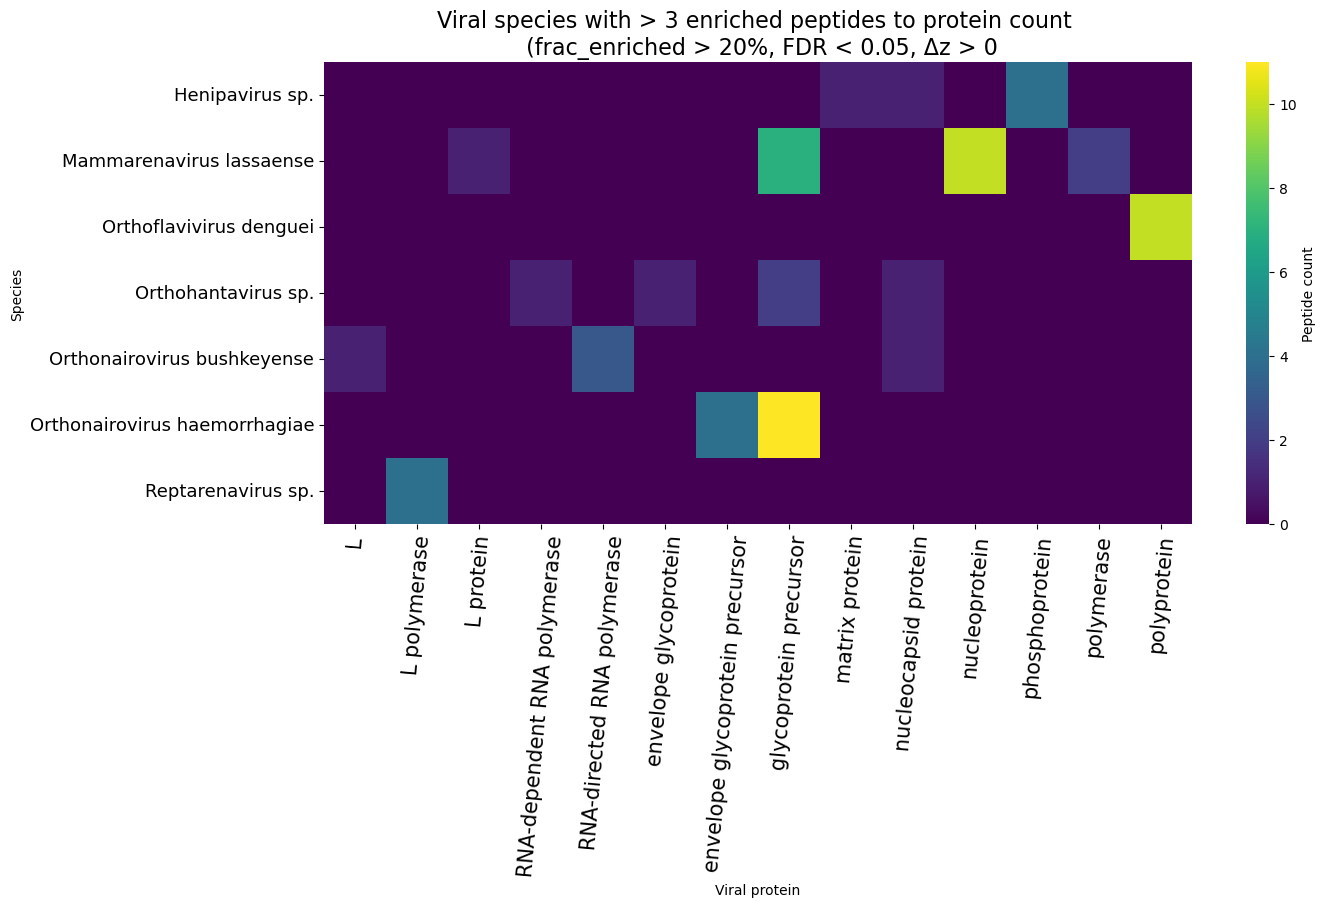

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#pivot reshapes from a long format to a wide format
heatmap = protein_counts.pivot(
    index='species', 
    columns='protein_name', 
    values='n_peptides'
).fillna(0)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap, cmap='viridis', cbar_kws={"label": "Peptide count"})
plt.xticks(fontsize=15, rotation=85)
plt.yticks(fontsize=13)
plt.xlabel("Viral protein")
plt.ylabel("Species")
plt.title(f"Viral species with > 3 enriched peptides to protein count \n (frac_enriched > {int(FRAC_MIN*100)}%, FDR < {SIG_FDR}, Δz > 0",  fontsize=16)

###  mapping the CCHF virus peptide seroreactivity to the glycoprotein precursor


In [ ]:
### mapping the CCHF virus peptide seroreactivity to the glycoprotein precursor

top_hits_CCHF_filtered = top_hits.loc[top_hits['species'] == 'Orthonairovirus haemorrhagiae'].copy()

### 

# >NP_950235.1 glycoprotein precursor [Orthonairovirus haemorrhagiae]
glycoprotein_precursor_refseq = """
>NP_950235.1 glycoprotein precursor [Orthonairovirus haemorrhagiae]
MHISLMYAILCLQLCGLGETHGSHNETRHNKTDTMTTPGDNPSSEPPVSTALSITLDPSTVTPTTPASGL
EGSGEVYTSPPITTGSLPLSETTPELPVTTGTDTLSAGDVDPSTQTAGGTSAPTVRTSLPNSPSTPSTPQ
DTHHPVRNLLSVTSPGPDETSTPSGTGKESSATSSPHPVSNRPPTPPATAQGPTENDSHNATEHPESLTQ
SATPGLMTSPTQIVHPQSATPITVQDTHPSPTNRSKRNLKMEIILTLSQGLKKYYGKILRLLQLTLEEDT
EGLLEWCKRNLGLDCDDTFFQKRIEEFFITGEGHFNEVLQFRTPGTLSTTESTPAGLPTAEPFKSYFAKG
FLSIDSGYYSAKCYSGTSNSGLQLINITRHSTRIVDTPGPKITNLKTINCINLKASIFKEHREVEINVLL
PQVAVNLSNCHVVIKSHVCDYSLDIDGAVRLPHIYHEGVFIPGTYKIVIDKKNKLNDRCTLFTDCVIKGR
EVRKGQSVLRQYKTEIRIGKASTGSRRLLSEEPSDDCISRTQLLRTETAEIHGDNYGGPGDKITICNGST
IVDQRLGSELGCYTINRVRSFKLCENSATGKNCEIDSVPVKCRQGYCLRITQEGRGHVKLSRGSEVVLDA
CDTSCEIMIPKGTGDILVDCSGGQQHFLKDNLIDLGCPKIPLLGKMAIYICRMSNHPKTTMAFLFWFSFG
YVITCILCKAIFYLLIIVGTLGKRLKQYRELKPQTCTICETTPVNAIDAEMHDLNCSYNICPYCASRLTS
DGLARHVIQCPKRKEKVEETELYLNLERIPWVVRKLLQVSESTGVALKRSSWLIVLLVLFTVSLSPVQSA
PIGQGKTIEAYRAREGYTSICLFVLGSILFIVSCLMKGLVDSVGNSFFPGLSICKTCSISSINGFEIESH
KCYCSLFCCPYCRHCSTDKEIHKLHLSICKKRKKGSNVMLAVCKLMCFRATMEVSNRALFIRSIINTTFV
LCILILAVCVVSTSAVEMENLPAGTWEREEDLTNFCHQECQVTETECLCPYEALVLRKPLFLDSTAKGMK
NLLNSTSLETSLSIEAPWGAINVQSTYKPTVSTANIALSWSSVEHRGNKILVSGRSESIMKLEERTGISW
DLGVEDASESKLLTVSVMDLSQMYSPVFEYLSGDRQVGEWPKATCTGDCPERCGCTSSTCLHKEWPHSRN
WRCNPTWCWGVGTGCTCCGLDVKDLFTDYMFVKWKVEYIKTEAIVCVELTSQERQCSLIEAGTRFNLGPV
TITLSEPRNIQQKLPPEIITLHPRIEEGFFDLMHVQKVLSASTVCKLQSCTHGVPGDLQVYHIGNLLKGD
KVNGHLIHKIEPHFNTSWMSWDGCDLDYYCNMGDWPSCTYTGVTQHNHASFVNLLNIETDYTKNFHFHSK
RVTAHGDTPQLDLKARPTYGAGEITVLVEVADMELHTKKIEISGLKFASLACTGCYACSSGISCKVRIHV
DEPDELTVHVKSDDPDVVAASSSLMARKLEFGTDSTFKAFSAMPKTSLCFYIVEREHCKSCSEEDTKKCV
NTKLEQPQSILIEHKGTIIGKQNSTCTAKASCWLESVKSFFYGLKNMLSGIFGNVFMGIFLFLAPFILLI
LFFMFGWRILFCFKCCRRTRGLFKYRHLKDDEETGYRRIIEKLNNKKGKNKLLDGERLADRRIAELFSTK
THIG
"""


In [ ]:
#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
ref_seq = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in glycoprotein_precursor_refseq.splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

### define the map_peptide function

In [119]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

#-- creates a pairwise sequence aligner
aligner = Align.PairwiseAligner()
aligner.mode = "local" #will find the best matching region between two sequences, not necessarily end-to-end
aligner.match_score = 2 #identical letters get +2
aligner.mismatch_score = -1 #different letteres get -1
aligner.open_gap_score = -5 #starting a gap is penalized heavily
aligner.extend_gap_score = -1 #extending an existing gap is penalized less

def map_peptide(peptide, reference):
    #defines a function that tries to map one peptide onto the reference sequence
    #exact substring match. Pos is the starting index if found, or -1 if not found.
    pos = reference.find(peptide) 
    if pos != -1: #if the peptide is found exactly, then start is recorded using 1-based numbering
        #end is the last residue position of the match. method: exact marks this as a perfect substring match
        #score is set to peptide length as a simple score
        return {
            "peptide": peptide,
            "start": pos + 1,               # 1-based
            "end": pos + len(peptide),      # 1-based inclusive
            "method": "exact",
            "score": len(peptide),
        }

    # fallback: local alignment
    #if exact matching fails, do aligner, mode is set to 'local'
    #so alns = aligner.align(reference, peptide) returns an alignment object collection. 
    #alns contains all possible alignments, ranked by score. 
    alns = aligner.align(reference, peptide)
    if len(alns) == 0:
        return {
            "peptide": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    aln = alns[0] #finds the best alignment, which is the first one returned
    #when you print this best possible alignment, you get two arrays. the first array are the coordinates
    #on the reference sequence. array([[6, 12]]) for example means reference[6:12] is aligned. 
    #The second array, are the coordinates on the peptide. So array([[0, 6]]) for example means that
    #peptide[0:6] is aligned. The best alignment may contain two matching blocks, indicating that 
    #the best alignment has two matching blocks. One aligned block from e.g. 0-2, another from 3-7.
    
    ref_blocks = aln.aligned[0]   # list of (start, end) blocks on reference
    if len(ref_blocks) == 0:
        return {
            "peptide": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    start = ref_blocks[0][0] + 1 #this here is the beginning of the first aligned block, converted to 1-based indexing
    #suppose ref_blocks is array([[6, 13]]), then ref_blocks[0] is [6, 13] which is the first aligned block. 
    #then ref_blocks[0][0] is 6, which is the starting python index. adding one gives 7, because protein residue
    #numbering is conventionally 1-based
    end = ref_blocks[-1][1] #end of the last aligned block
    #for a simple alignment e.g. [[6, 13]] the first block and the last block are the same. 
    #so ref_blocks[-1] is [6, 13] and ref_blocks[-1][1] is 13, which corresponds to residue 13 in 1-based numbering
    #as biopython alignment uses an exclusive end index. 
    #but sometimes an alignment contains gaps, and the best alignment might be [[0, 3], [6, 9]], so start would be
    #0 + 1 = 1, and end would be 9. even though there is a gap, the peptide is considered to span the entire region
    #from the first aligned residue to the last aligned residue. 

    return { #this returns the peptide mapping result from local alignment
        "peptide": peptide, #peptide here is the amino acid sequence for the peptide
        "start": start,
        "end": end,
        "method": "local", 
        "score": aln.score,
    }


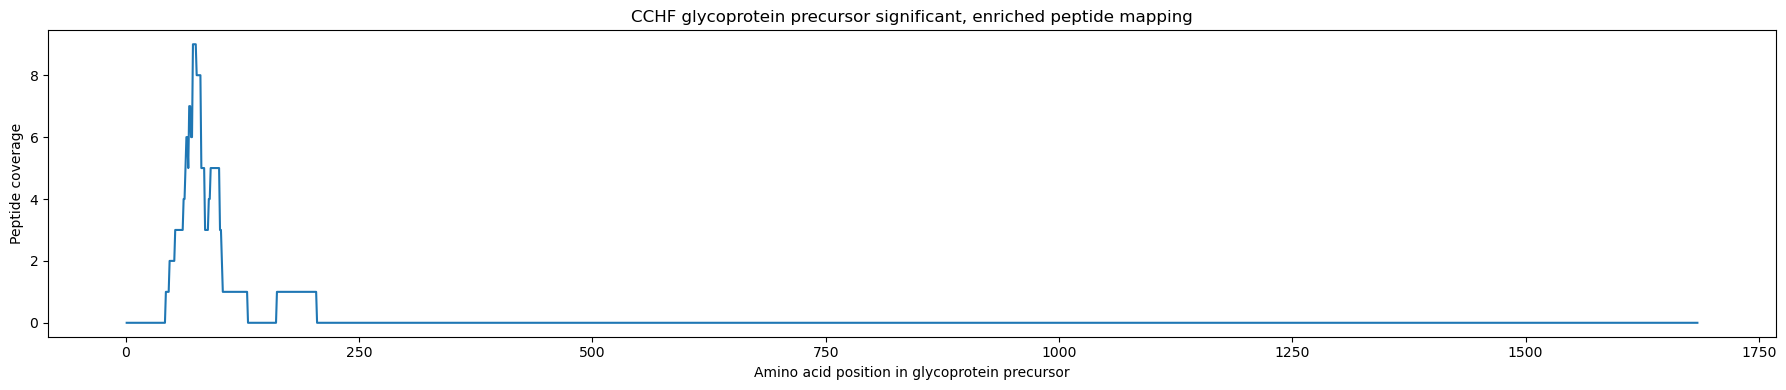

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

#- choosing which column to use for the peptide sequence
peptides = top_hits_CCHF_filtered["sequence"].dropna().astype(str).tolist()


mapped = pd.DataFrame([map_peptide(p, ref_seq) for p in peptides]) #this is a list comprehension. 
#so for every peptide in my peptides list, it calls the map_peptide(p, ref_seq) function, tries an exact match, 
#if that fails performs a local alignment and returns a dictionary like above. After doing this for every peptide, 
#pd.DataFrame(...) converts the list of dictionaries into a table. 

#this line removes any peptides that couldn't be mapped
mapped_ok = mapped.dropna(subset=["start", "end"]).copy()

# --- residue-level profile ---
n = len(ref_seq) #length of reference sequence
coverage = np.zeros(n, dtype=int)          # how many peptides cover each residue
aln_score = np.zeros(n, dtype=float)       # float array, one value per residues, initialized to zero

for _, row in mapped_ok.iterrows():
    s = int(row["start"]) - 1   # convert to 0-based
    e = int(row["end"])         # end is exclusive in Python slicing
    coverage[s:e] += 1 #will count how many peptides cover residue i
    #adds the peptide's score to every residue it covers
    #if score is missing, it adds 1.0 instead
    aln_score[s:e] += float(row["score"]) if pd.notna(row["score"]) else 1.0 

# optional normalization so long peptides do not dominate too much
#aln_score = aln_score / np.max(aln_score) if np.max(aln_score) > 0 else aln_score

residue_df = pd.DataFrame({
    "position": np.arange(1, n + 1),
    "residue": list(ref_seq),
    "coverage": coverage,
    "aln_score": aln_score,
})

# --- plot ---
plt.figure(figsize=(18, 4))
plt.plot(residue_df["position"], residue_df["coverage"], linewidth=1.5)
plt.xlabel("Amino acid position in glycoprotein precursor")
plt.ylabel("Peptide coverage")
plt.title("CCHF glycoprotein precursor significant, enriched peptide mapping")
plt.tight_layout()
plt.show()


### repeat map with all peptides which were filtered as being significant - this is NOT a seroreactivity map!

In [ ]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :]

In [ ]:
#subsetting to significant CCHF peptides and subsetting to glycoprotein peptides

sig_CCHF_peptides = top_hits.loc[top_hits['species'] == 'Orthonairovirus haemorrhagiae'].copy()

glycoprotein_valid = ['envelope glycoprotein precursor', 'glycoprotein', 'glycoprotein precursor', 'putative polyprotein']

sig_CCHF_glycoprotein_peptides = sig_CCHF_peptides.loc[sig_CCHF_peptides['protein_name'].isin(glycoprotein_valid)]


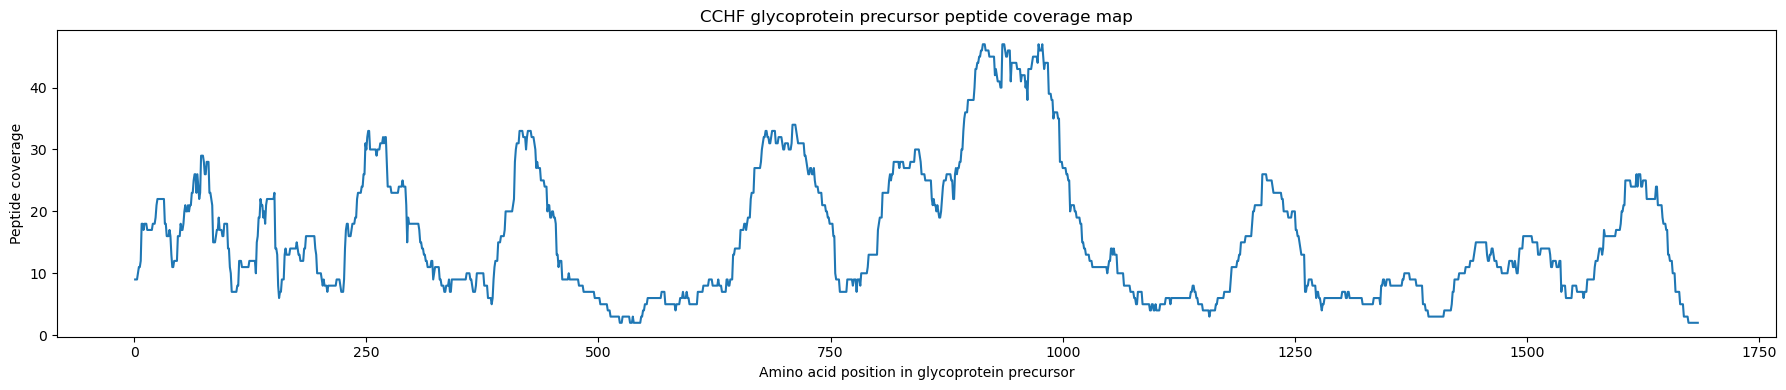

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align


#-- choose which peptide column to use
#tolist() throws away all the ppetide indexing so now peptides is just a plain python list
peptides = sig_CCHF_glycoprotein_peptides["sequence"].dropna().astype(str).tolist()

mapped = pd.DataFrame([map_peptide(p, ref_seq) for p in peptides])

# keep only mapped peptides
mapped_ok = mapped.dropna(subset=["start", "end"]).copy()

#-- residue-level profile 
n = len(ref_seq)
coverage = np.zeros(n, dtype=int)          # how many peptides cover each residue
aln_score = np.zeros(n, dtype=float)       # weighted by peptide score

for _, row in mapped_ok.iterrows():
    s = int(row["start"]) - 1   # convert to 0-based
    e = int(row["end"])         # end is exclusive in Python slicing
    coverage[s:e] += 1
    aln_score[s:e] += float(row["score"]) if pd.notna(row["score"]) else 1.0


residue_df = pd.DataFrame({
    "position": np.arange(1, n + 1),
    "residue": list(ref_seq),
    "coverage": coverage,
    "aln_score": aln_score,
})


# --- plot ---
plt.figure(figsize=(18, 4))
plt.plot(residue_df["position"], residue_df["coverage"], linewidth=1.5)
plt.xlabel("Amino acid position in glycoprotein precursor")
plt.ylabel("Peptide coverage")
plt.title("CCHF glycoprotein precursor peptide coverage map")
plt.tight_layout()
plt.show()


### repeat with all significant CCHF peptides and their RPK values

In [ ]:
#subsetting to significant CCHF peptides and subsetting to glycoprotein peptides

sig_CCHF_peptides = top_hits.loc[top_hits['species'] == 'Orthonairovirus haemorrhagiae'].copy()

glycoprotein_valid = ['envelope glycoprotein precursor', 'glycoprotein', 'glycoprotein precursor', 'putative polyprotein']

sig_CCHF_glycoprotein_peptides = sig_CCHF_peptides.loc[sig_CCHF_peptides['protein_name'].isin(glycoprotein_valid)]

#fetching the RPK values for the baseline samples for these peptides
#use level=0 to select the outermost index, so allows to group by the labels rather than passing the name of a specific column
#this produces a residue-level profile
CCHF_gpc_peptide_mean_rpk = baseline_long.loc[sig_CCHF_glycoprotein_peptides.index].groupby(level=0)["rpk"].mean()

#attach this to the significant peptide table
sig_CCHF_glycoprotein_peptides = sig_CCHF_glycoprotein_peptides.copy()
sig_CCHF_glycoprotein_peptides['mean_baseline_rpk'] = CCHF_gpc_peptide_mean_rpk

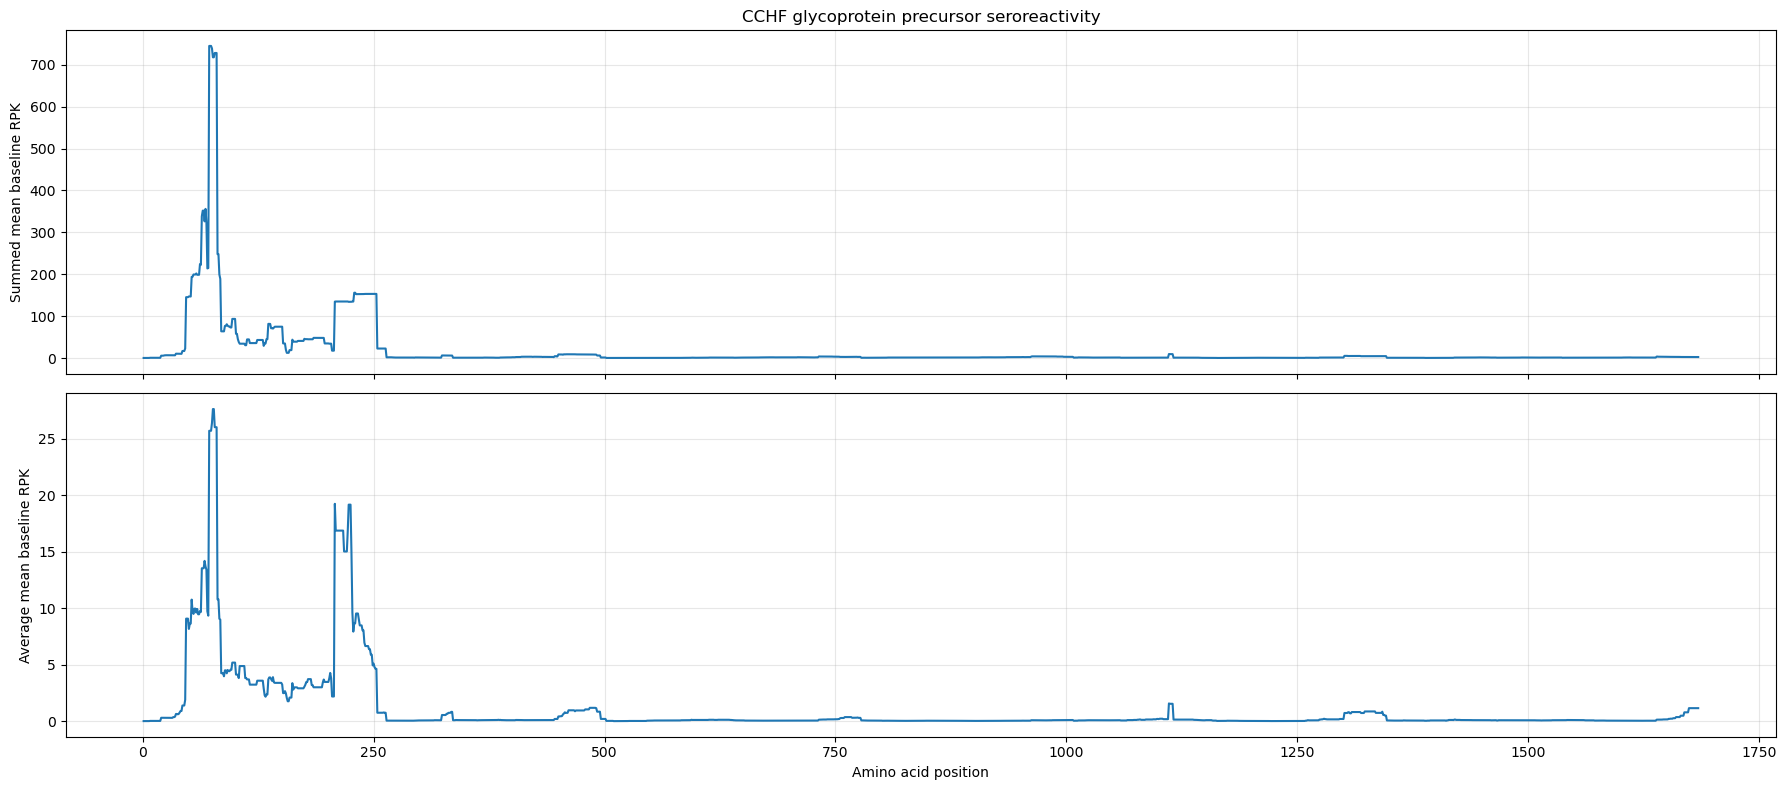

'\nmapped_ok.to_csv("CCHF_glycoprotein_peptide_mapping.csv", index=True)\nresidue_df.to_csv("CCHF_glycoprotein_residue_profile.csv", index=False)\n\n'

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

# map peptides while preserving the peptide index
#.apply() means take every value in this Series and run a function on it
mapped = (
    sig_CCHF_glycoprotein_peptides["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, ref_seq)))
    #.apply() automatically returns a DataFrame
)

# add the mean baseline RPK
mapped["mean_baseline_rpk"] = sig_CCHF_glycoprotein_peptides["mean_baseline_rpk"]

# remove unmapped peptides
mapped_ok = mapped.dropna(subset=["start", "end", "mean_baseline_rpk"]).copy()

mapped_ok["start"] = mapped_ok["start"].astype(int)
mapped_ok["end"] = mapped_ok["end"].astype(int)
mapped_ok["mean_baseline_rpk"] = mapped_ok["mean_baseline_rpk"].astype(float)

#-- residue-level profile 
n = len(ref_seq)
sum_signal = np.zeros(n, dtype=float) #initialize the sum_signal to be an array of zeros with length n (ref_seq length)
counts = np.zeros(n, dtype=int) #initialize the peptide count assay to be filled with zeros and have length n

for _, row in mapped_ok.iterrows():
    s = row["start"] - 1 #start of alignment on the ref_seq, -1 to revert to python indexing for array access
    e = row["end"] #leave end unchanged so the slice includes the correct last residue

    sum_signal[s:e] += row["mean_baseline_rpk"] #sum the mean_baseline_rpk of all peptides spanning this region
    counts[s:e] += 1

#this computes the element-wise average while safely handling cases where the divisor is zero
#out creates an output array initialized with zeros. where where is False, i.e. counts == 0, 
#the corresponding output value remains zero instead of attempting division

#divide the summed avg RPK signal of all peptides spanning the region by num of peptides covering the residues 
avg_signal = np.divide( 
    sum_signal,
    counts,
    out=np.zeros_like(sum_signal),
    where=counts > 0
)

residue_df = pd.DataFrame({
    "position": np.arange(1, n + 1), #back to 1-based indexing
    #the arrays never know about biological numbering, they are just indexed from 0. 
    #so can explicitly create a 1-based position column. 
    #The plot uses the position column. so row 0 gets position = 1, row 1 gets position = 2 etc.
    "residue": list(ref_seq),
    "sum_mean_rpk": sum_signal,
    "avg_mean_rpk": avg_signal,  #this is still being avg_signal[0] (which is value for residue 1), avg_signal[1] etc. for column values
    "peptide_count": counts,
})

# plot residue level seroreactivity

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
#I could theoretically do fig, axes= plt.subplots(2, 2) and I would have 4 subplots. 
#each is an independent graph. I could access these separately with axes[0, 0].plot(x1, y1), axes[0, 1].hits(data) etc. 
#all four on the same figure. 

# Summed signal
axes[0].plot(
    residue_df["position"],
    residue_df["sum_mean_rpk"],
    linewidth=1.5,
)
axes[0].set_ylabel("Summed mean baseline RPK")
axes[0].set_title("CCHF glycoprotein precursor seroreactivity")
axes[0].grid(alpha=0.3)

# Average signal
axes[1].plot(
    residue_df["position"],
    residue_df["avg_mean_rpk"],
    linewidth=1.5,
)
axes[1].set_xlabel("Amino acid position")
axes[1].set_ylabel("Average mean baseline RPK")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# save mapped peptide counts if desired

"""
mapped_ok.to_csv("CCHF_glycoprotein_peptide_mapping.csv", index=True)
residue_df.to_csv("CCHF_glycoprotein_residue_profile.csv", index=False)

"""


### now do the same for DENV! (using DENV type 2 as refseq, apparently circulates in Sierra Leone)

In [ ]:
### mapping the DENV virus peptide seroreactivity to the polyprotein
### 

# NP_056776.2 polyprotein [dengue virus type 2]
denv2_polyprotein_refseq = """
>NP_056776.2 polyprotein [dengue virus type 2]
MNNQRKKAKNTPFNMLKRERNRVSTVQQLTKRFSLGMLQGRGPLKLFMALVAFLRFLTIPPTAGILKRWG
TIKKSKAINVLRGFRKEIGRMLNILNRRRRSAGMIIMLIPTVMAFHLTTRNGEPHMIVSRQEKGKSLLFK
TEDGVNMCTLMAMDLGELCEDTITYKCPLLRQNEPEDIDCWCNSTSTWVTYGTCTTMGEHRREKRSVALV
PHVGMGLETRTETWMSSEGAWKHVQRIETWILRHPGFTMMAAILAYTIGTTHFQRALIFILLTAVTPSMT
MRCIGMSNRDFVEGVSGGSWVDIVLEHGSCVTTMAKNKPTLDFELIKTEAKQPATLRKYCIEAKLTNTTT
ESRCPTQGEPSLNEEQDKRFVCKHSMVDRGWGNGCGLFGKGGIVTCAMFRCKKNMEGKVVQPENLEYTIV
ITPHSGEEHAVGNDTGKHGKEIKITPQSSITEAELTGYGTVTMECSPRTGLDFNEMVLLQMENKAWLVHR
QWFLDLPLPWLPGADTQGSNWIQKETLVTFKNPHAKKQDVVVLGSQEGAMHTALTGATEIQMSSGNLLFT
GHLKCRLRMDKLQLKGMSYSMCTGKFKVVKEIAETQHGTIVIRVQYEGDGSPCKIPFEIMDLEKRHVLGR
LITVNPIVTEKDSPVNIEAEPPFGDSYIIIGVEPGQLKLNWFKKGSSIGQMFETTMRGAKRMAILGDTAW
DFGSLGGVFTSIGKALHQVFGAIYGAAFSGVSWTMKILIGVIITWIGMNSRSTSLSVTLVLVGIVTLYLG
VMVQADSGCVVSWKNKELKCGSGIFITDNVHTWTEQYKFQPESPSKLASAIQKAHEEGICGIRSVTRLEN
LMWKQITPELNHILSENEVKLTIMTGDIKGIMQAGKRSLRPQPTELKYSWKTWGKAKMLSTESHNQTFLI
DGPETAECPNTNRAWNSLEVEDYGFGVFTTNIWLKLKEKQDVFCDSKLMSAAIKDNRAVHADMGYWIESA
LNDTWKIEKASFIEVKNCHWPKSHTLWSNGVLESEMIIPKNLAGPVSQHNYRPGYHTQITGPWHLGKLEM
DFDFCDGTTVVVTEDCGNRGPSLRTTTASGKLITEWCCRSCTLPPLRYRGEDGCWYGMEIRPLKEKEENL
VNSLVTAGHGQVDNFSLGVLGMALFLEEMLRTRVGTKHAILLVAVSFVTLITGNMSFRDLGRVMVMVGAT
MTDDIGMGVTYLALLAAFKVRPTFAAGLLLRKLTSKELMMTTIGIVLLSQSTIPETILELTDALALGMMV
LKMVRNMEKYQLAVTIMAILCVPNAVILQNAWKVSCTILAVVSVSPLLLTSSQQKTDWIPLALTIKGLNP
TAIFLTTLSRTSKKRSWPLNEAIMAVGMVSILASSLLKNDIPMTGPLVAGGLLTVCYVLTGRSADLELER
AADVKWEDQAEISGSSPILSITISEDGSMSIKNEEEEQTLTILIRTGLLVISGLFPVSIPITAAAWYLWE
VKKQRAGVLWDVPSPPPMGKAELEDGAYRIKQKGILGYSQIGAGVYKEGTFHTMWHVTRGAVLMHKGKRI
EPSWADVKKDLISYGGGWKLEGEWKEGEEVQVLALEPGKNPRAVQTKPGLFKTNAGTIGAVSLDFSPGTS
GSPIIDKKGKVVGLYGNGVVTRSGAYVSAIAQTEKSIEDNPEIEDDIFRKRRLTIMDLHPGAGKTKRYLP
AIVREAIKRGLRTLILAPTRVVAAEMEEALRGLPIRYQTPAIRAEHTGREIVDLMCHATFTMRLLSPVRV
PNYNLIIMDEAHFTDPASIAARGYISTRVEMGEAAGIFMTATPPGSRDPFPQSNAPIIDEEREIPERSWN
SGHEWVTDFKGKTVWFVPSIKAGNDIAACLRKNGKKVIQLSRKTFDSEYVKTRTNDWDFVVTTDISEMGA
NFKAERVIDPRRCMKPVILTDGEERVILAGPMPVTHSSAAQRRGRIGRNPKNENDQYIYMGEPLENDEDC
AHWKEAKMLLDNINTPEGIIPSMFEPEREKVDAIDGEYRLRGEARKTFVDLMRRGDLPVWLAYRVAAEGI
NYADRRWCFDGVKNNQILEENVEVEIWTKEGERKKLKPRWLDARIYSDPLALKEFKEFAAGRKSLTLNLI
TEMGRLPTFMTQKARDALDNLAVLHTAEAGGRAYNHALSELPETLETLLLLTLLATVTGGIFLFLMSGRG
IGKMTLGMCCIITASILLWYAQIQPHWIAASIILEFFLIVLLIPEPEKQRTPQDNQLTYVVIAILTVVAA
TMANEMGFLEKTKKDLGLGSIATQQPESNILDIDLRPASAWTLYAVATTFVTPMLRHSIENSSVNVSLTA
IANQATVLMGLGKGWPLSKMDIGVPLLAIGCYSQVNPITLTAALFLLVAHYAIIGPGLQAKATREAQKRA
AAGIMKNPTVDGITVIDLDPIPYDPKFEKQLGQVMLLVLCVTQVLMMRTTWALCEALTLATGPISTLWEG
NPGRFWNTTIAVSMANIFRGSYLAGAGLLFSIMKNTTNTRRGTGNIGETLGEKWKSRLNALGKSEFQIYK
KSGIQEVDRTLAKEGIKRGETDHHAVSRGSAKLRWFVERNMVTPEGKVVDLGCGRGGWSYYCGGLKNVRE
VKGLTKGGPGHEEPIPMSTYGWNLVRLQSGVDVFFIPPEKCDTLLCDIGESSPNPTVEAGRTLRVLNLVE
NWLNNNTQFCIKVLNPYMPSVIEKMEALQRKYGGALVRNPLSRNSTHEMYWVSNASGNIVSSVNMISRML
INRFTMRYKKATYEPDVDLGSGTRNIGIESEIPNLDIIGKRIEKIKQEHETSWHYDQDHPYKTWAYHGSY
ETKQTGSASSMVNGVVRLLTKPWDVVPMVTQMAMTDTTPFGQQRVFKEKVDTRTQEPKEGTKKLMKITAE
WLWKELGKKKTPRMCTREEFTRKVRSNAALGAIFTDENKWKSAREAVEDSRFWELVDKERNLHLEGKCET
CVYNMMGKREKKLGEFGKAKGSRAIWYMWLGARFLEFEALGFLNEDHWFSRENSLSGVEGEGLHKLGYIL
RDVSKKEGGAMYADDTAGWDTRITLEDLKNEEMVTNHMEGEHKKLAEAIFKLTYQNKVVRVQRPTPRGTV
MDIISRRDQRGSGQVGTYGLNTFTNMEAQLIRQMEGEGVFKSIQHLTITEEIAVQNWLARVGRERLSRMA
ISGDDCVVKPLDDRFASALTALNDMGKIRKDIQQWEPSRGWNDWTQVPFCSHHFHELIMKDGRVLVVPCR
NQDELIGRARISQGAGWSLRETACLGKSYAQMWSLMYFHRRDLRLAANAICSAVPSHWVPTSRTTWSIHA
KHEWMTTEDMLTVWNRVWIQENPWMEDKTPVESWEEIPYLGKREDQWCGSLIGLTSRATWAKNIQAAINQ
VRSLIGNEEYTDYMPSMKRFRREEEEAGVLW
"""


In [112]:
#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
denv2_ref_seq = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in denv2_polyprotein_refseq.splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [ ]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :]

In [ ]:
#subsetting to significant CCHF peptides and subsetting to glycoprotein peptides

top_hits_denv_filtered = top_hits.loc[top_hits['species'] == 'Orthoflavivirus denguei'].copy()

top_hits_denv_filtered

#fetching the RPK values for the baseline samples for these peptides
#use level=0 to select the outermost index, so allows to group by the labels rather than passing the name of a specific column
#this produces a residue-level profile
denv_polyprotein_peptide_mean_rpk = baseline_long.loc[top_hits_denv_filtered.index].groupby(level=0)["rpk"].mean()

top_hits_denv_filtered['mean_baseline_rpk'] = denv_polyprotein_peptide_mean_rpk

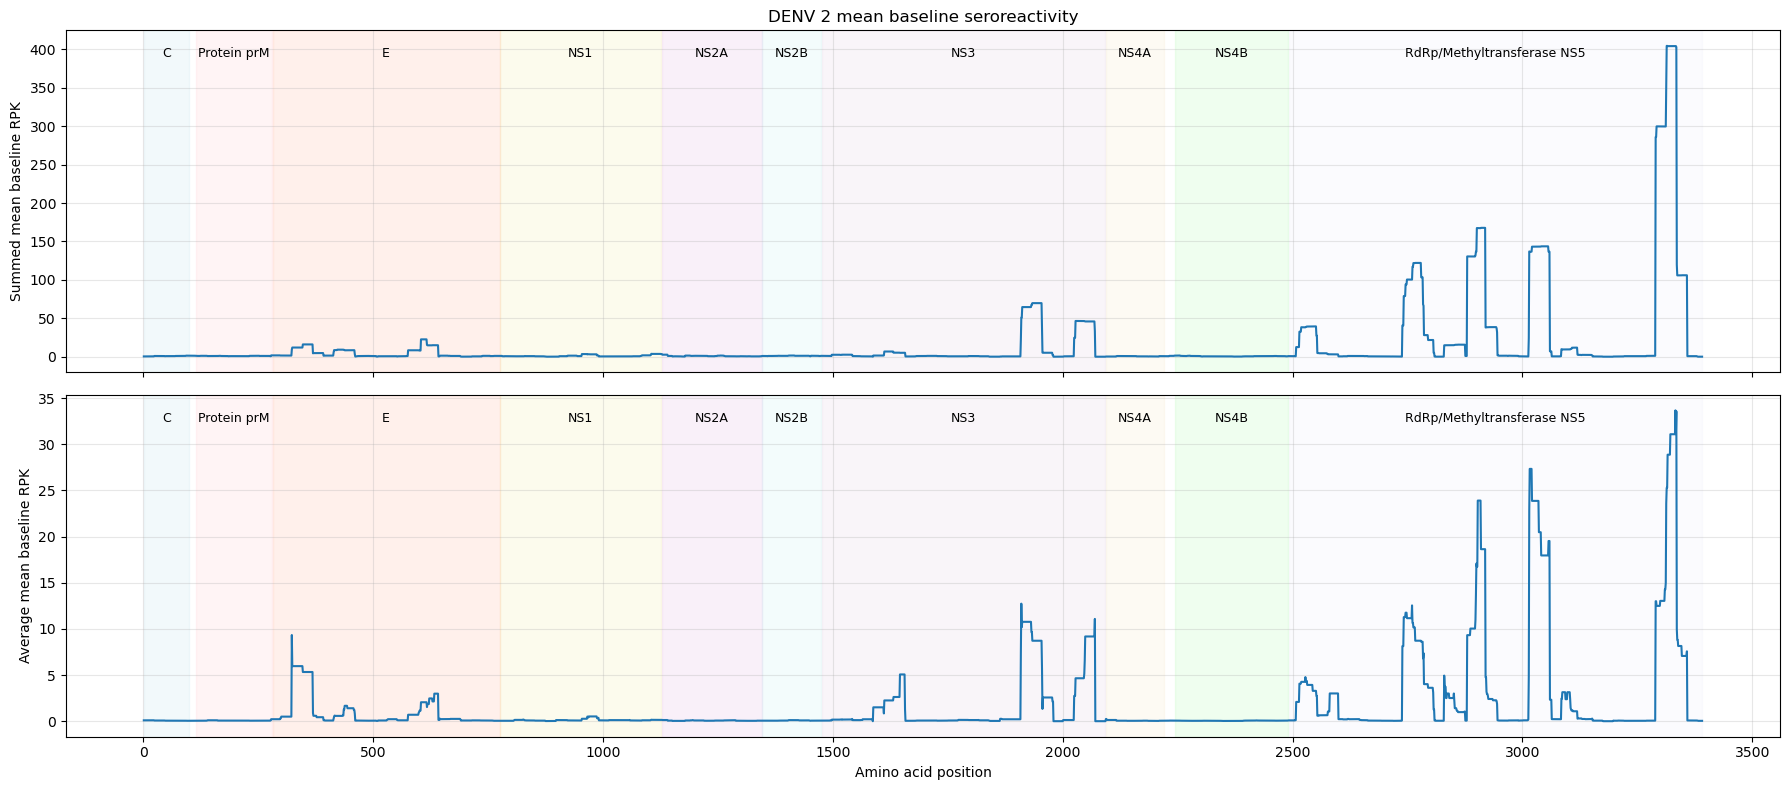

'\nmapped_ok.to_csv("CCHF_glycoprotein_peptide_mapping.csv", index=True)\nresidue_df.to_csv("CCHF_glycoprotein_residue_profile.csv", index=False)\n\n'

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

# map peptides while preserving the peptide index
#.apply() means take every value in this Series and run a function on it
mapped = (
    top_hits_denv_filtered["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, denv2_ref_seq)))
    #.apply() automatically returns a DataFrame
)

# add the mean baseline RPK
mapped["mean_baseline_rpk"] = top_hits_denv_filtered["mean_baseline_rpk"]

# remove unmapped peptides
mapped_ok = mapped.dropna(subset=["start", "end", "mean_baseline_rpk"]).copy()

mapped_ok["start"] = mapped_ok["start"].astype(int)
mapped_ok["end"] = mapped_ok["end"].astype(int)
mapped_ok["mean_baseline_rpk"] = mapped_ok["mean_baseline_rpk"].astype(float)

#-- residue-level profile 
n = len(denv2_ref_seq)
sum_signal = np.zeros(n, dtype=float) #initialize the sum_signal to be an array of zeros with length n (ref_seq length)
counts = np.zeros(n, dtype=int) #initialize the peptide count assay to be filled with zeros and have length n

for _, row in mapped_ok.iterrows():
    s = row["start"] - 1 #start of alignment on the ref_seq, -1 to revert to python indexing for array access
    e = row["end"] #leave end unchanged so the slice includes the correct last residue

    sum_signal[s:e] += row["mean_baseline_rpk"] #sum the mean_baseline_rpk of all peptides spanning this region
    counts[s:e] += 1

#this computes the element-wise average while safely handling cases where the divisor is zero
#out creates an output array initialized with zeros. where where is False, i.e. counts == 0, 
#the corresponding output value remains zero instead of attempting division

#divide the summed avg RPK signal of all peptides spanning the region by num of peptides covering the residues 
avg_signal = np.divide( 
    sum_signal,
    counts,
    out=np.zeros_like(sum_signal),
    where=counts > 0
)

residue_df = pd.DataFrame({
    "position": np.arange(1, n + 1), #back to 1-based indexing
    #the arrays never know about biological numbering, they are just indexed from 0. 
    #so can explicitly create a 1-based position column. 
    #The plot uses the position column. so row 0 gets position = 1, row 1 gets position = 2 etc.
    "residue": list(denv2_ref_seq),
    "sum_mean_rpk": sum_signal,
    "avg_mean_rpk": avg_signal,  #this is still being avg_signal[0] (which is value for residue 1), avg_signal[1] etc. for column values
    "peptide_count": counts,
})

# plot residue level seroreactivity

#do annotations
#got annotations from Uniprot: P14340 · POLG_DEN2N

annotations = [
    {"start": 1,    "end": 100,  "label": "C",                         "color": "lightblue"}, #capsid protein
    #{"start": 101,  "end": 114,  "label": "ER anchor for C",           "color": "lightgreen"},
    {"start": 115,  "end": 280,  "label": "Protein prM",               "color": "lightpink"},
    {"start": 281,  "end": 775,  "label": "E",                         "color": "lightsalmon"}, #Envelope protein 
    {"start": 776,  "end": 1127, "label": "NS1",                       "color": "khaki"},
    {"start": 1128, "end": 1345, "label": "NS2A",                      "color": "plum"},
    {"start": 1346, "end": 1475, "label": "NS2B",                      "color": "paleturquoise"},
    {"start": 1476, "end": 2093, "label": "NS3",                       "color": "thistle"},
    {"start": 2094, "end": 2220, "label": "NS4A",                      "color": "wheat"},
    #{"start": 2221, "end": 2243, "label": "Peptide 2k",                "color": "lightgray"},
    {"start": 2244, "end": 2491, "label": "NS4B",                      "color": "palegreen"},
    {"start": 2492, "end": 3391, "label": "RdRp/Methyltransferase NS5","color": "lavender"},
]

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
#I could theoretically do fig, axes= plt.subplots(2, 2) and I would have 4 subplots. 
#each is an independent graph. I could access these separately with axes[0, 0].plot(x1, y1), axes[0, 1].hits(data) etc. 
#all four on the same figure. 

# Summed signal
axes[0].plot(
    residue_df["position"],
    residue_df["sum_mean_rpk"],
    linewidth=1.5,
)
axes[0].set_ylabel("Summed mean baseline RPK")
axes[0].set_title("DENV 2 mean baseline seroreactivity")
axes[0].grid(alpha=0.3)

# Average signal
axes[1].plot(
    residue_df["position"],
    residue_df["avg_mean_rpk"],
    linewidth=1.5,
)
axes[1].set_xlabel("Amino acid position")
axes[1].set_ylabel("Average mean baseline RPK")
axes[1].grid(alpha=0.3)

#add shaded annotation regions to both plots
for ax in axes:
    for ann in annotations:
        ax.axvspan(ann["start"], ann["end"], color=ann["color"], alpha=0.15)
        ax.text(
            (ann["start"] + ann["end"]) / 2, #calculates the middle of annotated region so the label is centered
            0.95, 
            ann["label"], 
            transform=ax.get_xaxis_transform(), #x in data coords, y in axes coords
            ha="center", 
            va="top", 
            fontsize=9, 
            rotation=0

        )

plt.tight_layout()
plt.show()

# save mapped peptide counts if desired

"""
mapped_ok.to_csv("CCHF_glycoprotein_peptide_mapping.csv", index=True)
residue_df.to_csv("CCHF_glycoprotein_residue_profile.csv", index=False)

"""


### Repeat with Lassa virus glycoprotein

In [138]:

# >NP_950235.1 glycoprotein precursor [Orthonairovirus haemorrhagiae]
lasv_glycoprotein_refseq = """
>NP_694870.1 glycoprotein [Mammarenavirus lassaense]
MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTSLYKGVYELQT
LELNMETLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHKFCNLSDAHKKNLYDHALMSIISTF
HLSIPNFNQYEAMSCDFNGGKISVQYNLSHSYAGDAANHCGTVANGVLQTFMRMAWGGSYIALDSGRGNW
DCIMTSYQYLIIQNTTWEDHCQFSRPSPIGYLGLLSQRTRDIYISRRLLGTFTWTLSDSEGKDTPGGYCL
TRWMLIEAELKCFGNTAVAKCNEKHDEEFCDMLRLFDFNKQAIQRLKAEAQMSIQLINKAVNALINDQLI
MKNHLRDIMGIPYCNYSKYWYLNHTTTGRTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYM
ERQGKTPLGLVDLFVFSTSFYLISIFLHLVKIPTHRHIVGKSCPKPHRLNHMGICSCGLYKQPGVPVKWK
R

"""

#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
lasv_gpc_ref_seq = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in lasv_glycoprotein_refseq.splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [147]:
# ------ stringent filter: MWU + FDR + exposure-specific (for final plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) &
    (res_exposed_hbdb['delta_z']  > 0)
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :]

In [ ]:
#subsetting to significant CCHF peptides and subsetting to glycoprotein peptides

top_hits_lasv_filtered = top_hits.loc[top_hits['species'] == 'Mammarenavirus lassaense'].copy()

top_hits_lasv_filtered['protein_name'].unique()


glycoprotein_valid = ['envelope glycoprotein precursor', 'glycoprotein', 'glycoprotein precursor', 'putative polyprotein', 'gpc']

top_hits_lasv_filtered = top_hits_lasv_filtered.loc[top_hits_lasv_filtered['protein_name'].isin(glycoprotein_valid)]


#fetching the RPK values for the baseline samples for these peptides
#use level=0 to select the outermost index, so allows to group by the labels rather than passing the name of a specific column
#this produces a residue-level profile
lasv_glycoprotein_peptide_mean_rpk = baseline_long.loc[top_hits_lasv_filtered.index].groupby(level=0)["rpk"].mean()

top_hits_lasv_filtered['mean_baseline_rpk'] = lasv_glycoprotein_peptide_mean_rpk

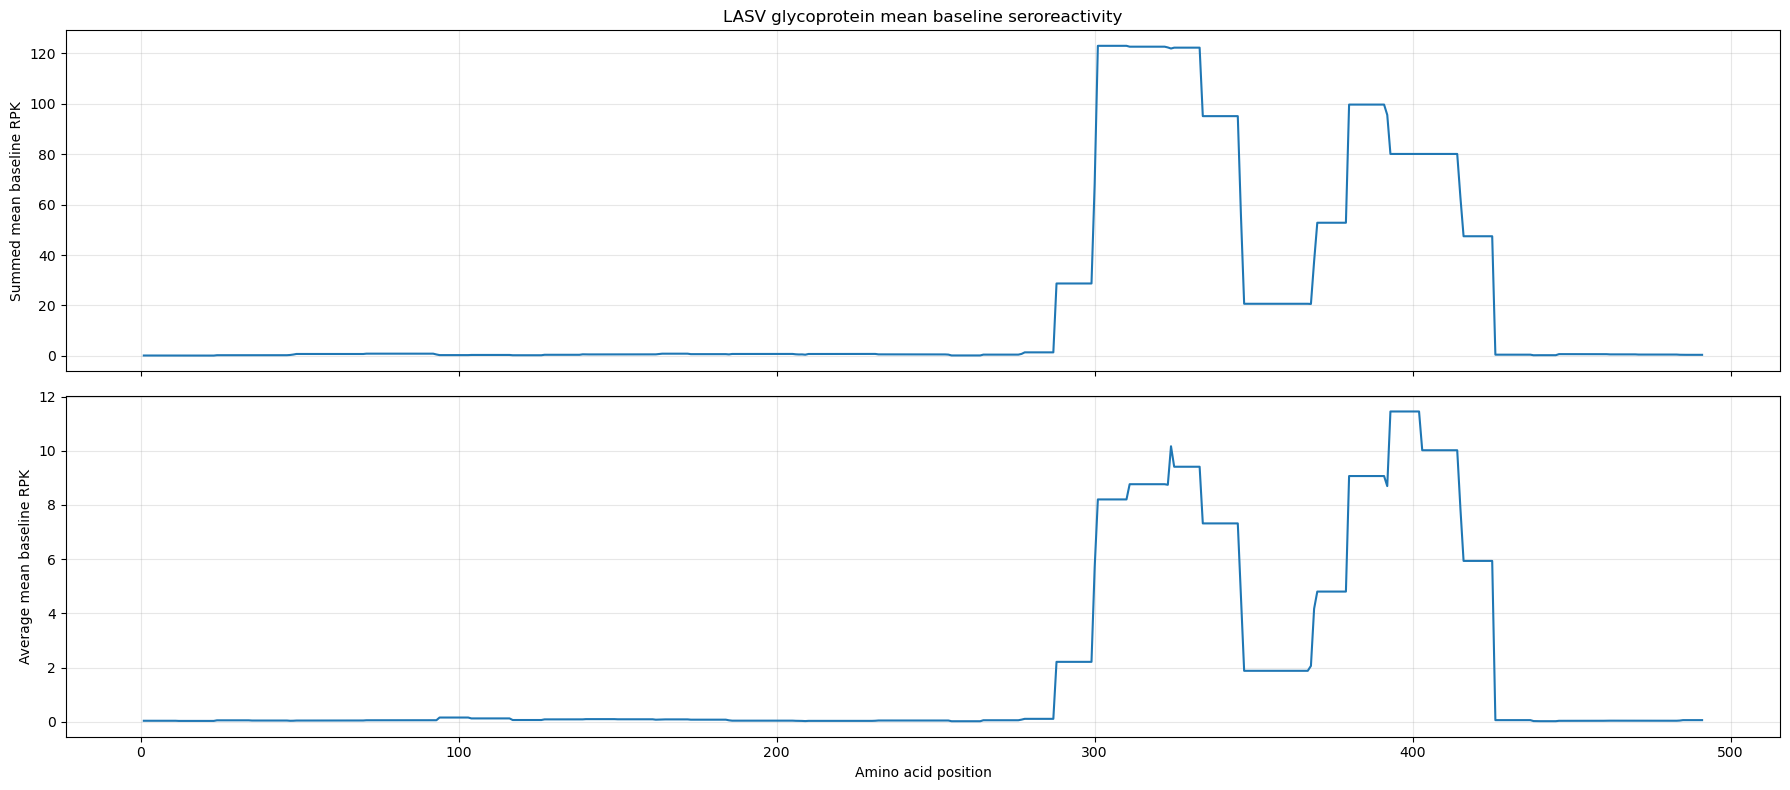

In [168]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

# map peptides while preserving the peptide index
#.apply() means take every value in this Series and run a function on it
mapped = (
    top_hits_lasv_filtered["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, lasv_gpc_ref_seq)))
    #.apply() automatically returns a DataFrame
)

# add the mean baseline RPK
mapped["mean_baseline_rpk"] = top_hits_lasv_filtered["mean_baseline_rpk"]

# remove unmapped peptides
mapped_ok = mapped.dropna(subset=["start", "end", "mean_baseline_rpk"]).copy()

mapped_ok["start"] = mapped_ok["start"].astype(int)
mapped_ok["end"] = mapped_ok["end"].astype(int)
mapped_ok["mean_baseline_rpk"] = mapped_ok["mean_baseline_rpk"].astype(float)

#-- residue-level profile 
n = len(lasv_gpc_ref_seq)
sum_signal = np.zeros(n, dtype=float) #initialize the sum_signal to be an array of zeros with length n (ref_seq length)
counts = np.zeros(n, dtype=int) #initialize the peptide count assay to be filled with zeros and have length n

for _, row in mapped_ok.iterrows():
    s = row["start"] - 1 #start of alignment on the ref_seq, -1 to revert to python indexing for array access
    e = row["end"] #leave end unchanged so the slice includes the correct last residue

    sum_signal[s:e] += row["mean_baseline_rpk"] #sum the mean_baseline_rpk of all peptides spanning this region
    counts[s:e] += 1

#this computes the element-wise average while safely handling cases where the divisor is zero
#out creates an output array initialized with zeros. where where is False, i.e. counts == 0, 
#the corresponding output value remains zero instead of attempting division

#divide the summed avg RPK signal of all peptides spanning the region by num of peptides covering the residues 
avg_signal = np.divide( 
    sum_signal,
    counts,
    out=np.zeros_like(sum_signal),
    where=counts > 0
)

residue_df = pd.DataFrame({
    "position": np.arange(1, n + 1), #back to 1-based indexing
    #the arrays never know about biological numbering, they are just indexed from 0. 
    #so can explicitly create a 1-based position column. 
    #The plot uses the position column. so row 0 gets position = 1, row 1 gets position = 2 etc.
    "residue": list(lasv_gpc_ref_seq),
    "sum_mean_rpk": sum_signal,
    "avg_mean_rpk": avg_signal,  #this is still being avg_signal[0] (which is value for residue 1), avg_signal[1] etc. for column values
    "peptide_count": counts,
})

# plot residue level seroreactivity

#do annotations

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
#I could theoretically do fig, axes= plt.subplots(2, 2) and I would have 4 subplots. 
#each is an independent graph. I could access these separately with axes[0, 0].plot(x1, y1), axes[0, 1].hits(data) etc. 
#all four on the same figure. 

# Summed signal
axes[0].plot(
    residue_df["position"],
    residue_df["sum_mean_rpk"],
    linewidth=1.5,
)
axes[0].set_ylabel("Summed mean baseline RPK")
axes[0].set_title("LASV glycoprotein mean baseline seroreactivity")
axes[0].grid(alpha=0.3)

# Average signal
axes[1].plot(
    residue_df["position"],
    residue_df["avg_mean_rpk"],
    linewidth=1.5,
)
axes[1].set_xlabel("Amino acid position")
axes[1].set_ylabel("Average mean baseline RPK")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()


### Figure 3: Mapping peptides to parent antigen

- summarize reactivity to each strain (use the accession IDs)
- I already have the mean and median z_scores for each peptide for the entire cohort, I subset to significant peptides (FDR thresh)
- group by accession and then take the average z_score for that accession
- group by viral genus
- subset to the protein you used for the phylogenetic tree
- the output should be 
-> sequences.fasta (one sequence per accession used in the library)
-> metadata.tsv (one row per sequence used in the tree with seroreactivity columns)
    would be great to have strain_acc_location, then virus, then genbank_accession, the protein or segment, the date of collection, the region, the country, the division, the host (if I want to color or filter by host).
    then phip_mean_reactivity (mean or median normalized peptide reactivity for that accession across all sera)
    the phip_seroprevalence (numeric between 0 and 1: fraction of sera with aggregate reactivity above a threshold for that accession)
    phip_groupX_mean - separate columns like phip_survivor_mean and phip_control_mean
    I can list those column names under colorings in the Nextstrain config
    
-> tree.nwk (phylogeny of these sequences)

then I can try to configure nextstrain and inspect the tree colored by seroreactivity


In [ ]:
# ------ stringent filter: MWU + FDR + exposure-specific (for the next plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) 
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

In [ ]:
baseline_long_sig_peps = baseline_long.loc[top_hits.index]

In [ ]:
data = baseline_long_sig_peps.groupby(['genus', 'status'])['rpk'].mean().reset_index()

#normalize the rpk values to the 0-1 range 

rpk_min = data['rpk'].min()
rpk_max = data['rpk'].max()

#have to subtact rpk_min so that the smallest value becomes 0 and all other values are measured
#relative to that minimum before rescaling
data['rpk_norm'] = (data['rpk'] - rpk_min) / (rpk_max - rpk_min)


#reshape to 2D matrix using a pivot table
matrix_df = data.pivot(index='genus', columns='status', values='rpk_norm')


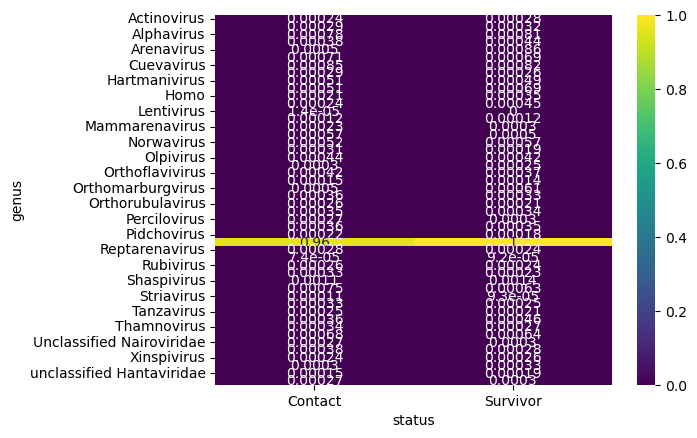

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix_df, cmap='viridis', annot=True)

plt.show()

In [ ]:
#subsetting to significant CCHF peptides and subsetting to glycoprotein peptides

sig_CCHF_peptides = top_hits.loc[top_hits['species'] == 'Orthonairovirus haemorrhagiae'].copy()

glycoprotein_valid = ['envelope glycoprotein precursor', 'glycoprotein', 'glycoprotein precursor', 'putative polyprotein']

sig_CCHF_glycoprotein_peptides = sig_CCHF_peptides.loc[sig_CCHF_peptides['protein_name'].isin(glycoprotein_valid)]

#fetching the RPK values for the baseline samples for these peptides
#use level=0 to select the outermost index, so allows to group by the labels rather than passing the name of a specific column
#this produces a residue-level profile
CCHF_gpc_peptide_mean_rpk = baseline_long.loc[sig_CCHF_glycoprotein_peptides.index].groupby(level=0)["rpk"].mean()

#attach this to the significant peptide table
sig_CCHF_glycoprotein_peptides = sig_CCHF_glycoprotein_peptides.copy()
sig_CCHF_glycoprotein_peptides['mean_baseline_rpk'] = CCHF_gpc_peptide_mean_rpk

In [ ]:
#subset to significant peptides only
z_long_sig_peps = z_long.loc[sig_peps]

In [ ]:
#-- saple metadata
baseline_lookup = (
    z_long_sig_peps[z_long_sig_peps["is_baseline"] == 'yes']
    .sort_values(["participant_id", "collection_date"])
    .groupby("participant_id", as_index=False)
    .first()[["participant_id", "sample_id"]] #first() grabs first value
    .set_index("participant_id")["sample_id"] #participant_id will be key, sample_id will be values .set_index(column to be key)[column to be values]
    .to_dict()
)
followups = z_long_sig_peps[z_long_sig_peps["is_baseline"] == 'no'].copy()
followups = followups.sort_values(["participant_id", "years_since_baseline", "collection_date"])


In [ ]:
for pid, p_df in z_long_sig_peps.groupby("participant_id"):
    base_id = baseline_lookup.get(pid) #retreives values from dictionary
    if base_id is None:
        continue

    p_follow = followups[followups["participant_id"] == pid]
    if p_follow.empty:
        continue
    
    #only keep peptides from this participants baseline + follow up samples
    sample_ids = [base_id] + p_follow["sample_id"].to_list()

    #subset to the z_score values for this patient's baseline and follow up samples
    p_df = p_df[p_df["sample_id"].isin(sample_ids)].copy()

    for genus, g_df in p_df.groupby('genus'):
        #peptide x sample matrix
        mat = g_df.pivot_table( #pivot table is a data summarization tool provided by pandas library
            #this consolidates data restructuring and analysis into a single, highly readable function
            #index: columns from original data that will become the rows of your new table
            #columns: columns whose unique values will become the new column headers 
            #values: the specific numeric columns you want to aggregate and display inside the cells
            #aggfunc: the mathematical function used to summarize duplicate values
            index="peptide", 
            columns="sample_id",
            values="z_score", 
            aggfunc="mean"
        )

        if base_id not in mat.columns:
            continue
        
        base_vec = mat[base_id]

        for _, fu in p_follow.iterrows(): #iterrows lets us loop through the rows of the dataframe, for index, row in df.iterrows()
            fu_id = fu["sample_id"]
            if fu_id not in mat.columns:
                continue
            
            pair = pd.concat([base_vec, mat[fu_id]], axis=1, join="inner").dropna()

            if len(pair) < MIN_PEPTIDES:
                continue

            x = pair.iloc[:, 0].values #baseline vector peptide values for the genus
            y = pair.iloc[:, 1].values #follow up vector peptide values for the genus

            #skip if either vector is constant
            #pearson correlation is calculated by dividing with stds of both variables (vectors), so if zero won't work
            #r = sum[(xi-mean(vector x)) x (yi-mean(vector y)] / sqrt[sum(xi-mean(vector x))^2 x sum(yi-mean(vector y))^2]
            if np.std(x) == 0 or np.std(y) == 0:
                continue
            
            r, pval = pearsonr(x, y)

            rows.append({ #this adds a new dictionary to the end of an existing list called rows, defined earlier
                "participant_id": pid, 
                "genus": genus,
                "baseline_sample": base_id,
                "followup_sample": fu_id, 
                "years_since_baseline": fu["years_since_baseline"], 
                "r": r, 
                "pval": pval, 
                "n_peptides": len(pair)
            })


NameError: name 'MIN_PEPTIDES' is not defined

### Figure 3: Genus-by-sample Kernel density correlation plot - comparison Survivor vs Contact

for the following genuses:
- Mammarenavirus
- Orthonairovirus
- Phlebovirus
- Orthoflavivirus 

In [ ]:
# ------ stringent filter: MWU + FDR + exposure-specific (for the next plots)

sig_peps = res_exposed_hbdb[
    (res_exposed_hbdb['pval_adj'] < SIG_FDR) 
].index

top_hits = res_exposed_hbdb.loc[sig_peps, :].sort_values('frac_enriched', ascending=False)

In [ ]:
#subset to significant peptides only
z_long_sig_peps = z_long.loc[sig_peps]

### starting the kernel density analysis

In [ ]:
z_long_sig_peps.head(2)

,sample_id,z_score,participant_id,collection_date,collection_year,visit_number,years_since_baseline,is_baseline,genus
peptide,,,,,,,,,
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_1,C-452-2_5_H3,-0.557635,C-452-2,2022-03-11,2022,3,2.464,no,Mammarenavirus
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_1,C-109-3_4_E7,-0.557635,C-109-3,2020-12-02,2020,1,0.000,yes,Mammarenavirus


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, gaussian_kde

#-- Settings

Z_THRESH = 3.0 #this is the threshold with which the sig_peps were chosen, z_long_sig_peps stores them
MIN_PEPTIDES = 20 #minimum peptides needed for a correlation
TOP_N_GENERA = 6 #only plot the most represented genera
USE_SIG_PEPTIDES = True 
USE_EXPOSED_ENRICHED_ONLY = False #keep false for a longitudinal stability plot 

#Time bins in days since baseline
TIME_BINS = [0, 1, 2, np.inf]
TIME_LABELS = ["<1 year", "1-2 years", ">2 years"]

#-- copy long table with sig peps
z_long_sig_peps = z_long_sig_peps.copy()

#-- drop rows if values missing in any of these columns
z_long_sig_peps = z_long_sig_peps.dropna(subset=["participant_id", "sample_id", "genus", "z_score"])

#-- saple metadata
baseline_lookup = (
    z_long_sig_peps[z_long_sig_peps["is_baseline"] == 'yes']
    .sort_values(["participant_id", "collection_date"])
    .groupby("participant_id", as_index=False)
    .first()[["participant_id", "sample_id"]] #first() grabs first value
    .set_index("participant_id")["sample_id"] #participant_id will be key, sample_id will be values .set_index(column to be key)[column to be values]
    .to_dict()
)
followups = z_long_sig_peps[z_long_sig_peps["is_baseline"] == 'no'].copy()
followups = followups.sort_values(["participant_id", "years_since_baseline", "collection_date"])

#compute baseline-vs-follow-up Pearson r 
#for each participant, genus, and follow-up sample
rows = []

for pid, p_df in z_long_sig_peps.groupby("participant_id"):
    base_id = baseline_lookup.get(pid) #retreives values from dictionary
    if base_id is None:
        continue

    p_follow = followups[followups["participant_id"] == pid]
    if p_follow.empty:
        continue
    
    #only keep peptides from this participants baseline + follow up samples
    sample_ids = [base_id] + p_follow["sample_id"].to_list()

    #subset to the z_score values for this patient's baseline and follow up samples
    p_df = p_df[p_df["sample_id"].isin(sample_ids)].copy()

    for genus, g_df in p_df.groupby('genus'):
        #peptide x sample matrix
        mat = g_df.pivot_table( #pivot table is a data summarization tool provided by pandas library
            #this consolidates data restructuring and analysis into a single, highly readable function
            #index: columns from original data that will become the rows of your new table
            #columns: columns whose unique values will become the new column headers 
            #values: the specific numeric columns you want to aggregate and display inside the cells
            #aggfunc: the mathematical function used to summarize duplicate values
            index="peptide", 
            columns="sample_id",
            values="z_score", 
            aggfunc="mean"
        )

        if base_id not in mat.columns:
            continue
        
        base_vec = mat[base_id]

        for _, fu in p_follow.iterrows(): #iterrows lets us loop through the rows of the dataframe, for index, row in df.iterrows()
            fu_id = fu["sample_id"]
            if fu_id not in mat.columns:
                continue
            
            pair = pd.concat([base_vec, mat[fu_id]], axis=1, join="inner").dropna()

            if len(pair) < MIN_PEPTIDES:
                continue

            x = pair.iloc[:, 0].values #baseline vector peptide values for the genus
            y = pair.iloc[:, 1].values #follow up vector peptide values for the genus

            #skip if either vector is constant
            #pearson correlation is calculated by dividing with stds of both variables (vectors), so if zero won't work
            #r = sum[(xi-mean(vector x)) x (yi-mean(vector y)] / sqrt[sum(xi-mean(vector x))^2 x sum(yi-mean(vector y))^2]
            if np.std(x) == 0 or np.std(y) == 0:
                continue
            
            r, pval = pearsonr(x, y)

            rows.append({ #this adds a new dictionary to the end of an existing list called rows, defined earlier
                "participant_id": pid, 
                "genus": genus,
                "baseline_sample": base_id,
                "followup_sample": fu_id, 
                "years_since_baseline": fu["years_since_baseline"], 
                "r": r, 
                "pval": pval, 
                "n_peptides": len(pair)
            })

corr_df = pd.DataFrame(rows)

if corr_df.empty:
    raise ValueError("No participant/genus/sample pairs had enough peptides for each correlation")

#-- keep genera with enough data
genus_counts = corr_df.groupby("genus").size().sort_values(ascending=False) #.size() returns a series containing the total number of rows in each group, including NaN values
top_genera = genus_counts.head(TOP_N_GENERA).index.to_list()

corr_df = corr_df[corr_df["genus"].isin(top_genera)].copy()

#bin by time since baseline
corr_df["time_bin"] = pd.cut(
    corr_df["years_since_baseline"], 
    bins=TIME_BINS, 
    labels=TIME_LABELS,
    right=False
)


KeyboardInterrupt: 

In [ ]:
print(z_long_sig_peps)

In [ ]:
#save corr_df in csv so you don't have to recalculate it

#define the group
corr_df["group"] = np.where(
    corr_df["participant_id"].str.startswith("S-"), 
    "Survivor", 
    "Contact"
)

#np.where(condition, value_if_true, value_if_false)

corr_df.to_csv("corr_peptide_z_scores_per_genera_for_longitudinal_samples_070226")

In [ ]:
#-- scatter plot with one point per participant-follow-up pair with a smooth trend line on top

#-- still need to color survivor vs contact

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import re


nplots = len(top_genera)
ncols = 2 #there will be 2 columns of plots
nrows = int(np.ceil(nplots / ncols)) #depending on the number of genera, there will be this many row plots

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.8 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1) #flattening the axes to make it easier to loop over

for ax, genus in zip(axes, top_genera):
    #first this will subset the data to the genus
    sub = corr_df[corr_df["genus"] == genus].dropna(subset=["years_since_baseline", "r"]).copy()

    if sub.empty:
        ax.axis("off")
        continue
    
    colors = {
    "Survivor": "tab:red", 
    "Contact": "tab:blue"}

    # Scatter points
    #now every row becomes one point, suppose years 0.7 -> r = 0.97 (one participant)
    #years 1.3 -> 0.95
    for group, group_df in sub.groupby("group")
        ax.scatter(
            sub["years_since_baseline"],
            sub["r"],
            s=45,
            alpha=0.75, 
            color=colors[group], 
            label=group
        )

    # LOWESS smooth if enough points -> this is a locally weighted regression
    #instead of fitting a straight line, it asks: around this x-value, what do nearby observations look like? 
    if len(sub) >= 5:
        sm = lowess(
            endog=sub["r"].values,
            exog=sub["years_since_baseline"].values,
            frac=0.6,
            return_sorted=True
        )
        ax.plot(sm[:, 0], sm[:, 1], linewidth=2) #plot the smooth, sm[:,0] means x-coordinate, sm[:, 1] means smoothed y values

    ax.axhline(0, color="black", lw=0.8, ls="--") #this is a reference line to immediately see positive vs neg. correlations
    ax.set_title(genus)
    ax.set_xlabel("Years since baseline")
    ax.set_ylabel("Pearson r")
    ax.set_ylim(-1.05, 1.05)

# Turn off unused axes
for ax in axes[len(top_genera):]:
    ax.axis("off")

fig.suptitle(
    "Longitudinal stability of seroreactivity profiles by genus\n"
    "Baseline vs follow-up Pearson correlation for each participant",
    fontsize=14,
    y=1.02
)

#add a single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, log="upper right")

plt.tight_layout()
plt.show()


In [ ]:
#-- Mixed Effects Model

In [ ]:
#-- Kernel density plot

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

#x-axis for density estimation
xgrid = np.linspace(-1, 1, 400) #this creates evenly spaced numbrs over a specified interval 
#np.linspace(start, stop, num, endpoint=True) wiuth start: starting value of sequence, stop: end value of sequence
#num = number of samples to generate (defaults to 50), endpoint=True if True, then stop is included as last value
nplots = len(top_genera)
ncols = 2
nrows = int(np.ceil(nplots/ncols))

fig, axes = plt.subplots(
    nrows, 
    ncols, 
    figsize=(12, 4.5 * nrows), 
    sharex=True, 
    sharey=True
)

axes = np.array(axes).reshape(-1)

for ax, genus in zip(axes, top_genera):
    sub = corr_df[corr_df["genus"] == genus]
    
    for tb in TIME_LABELS:

        vals = (
            sub.loc[sub["time_bin"] == tb, "r"]
            .dropna()
            .values
        )

        #Need at least a few observations
        if len(vals) < 3: 
            continue

        #KDE fails if all values are identical
        if np.std(vals) < 1e-8:
            continue

        kde = gaussian_kde(vals)

        ax.plot(
            xgrid, 
            kde(xgrid), 
            lw=2, 
            label=f"{tb} (n={len(vals)})"
        )
    
    ax.axvline(0, color="black", ls="--", lw=0.8)

    ax.set_title(genus)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Pearson correlation (r)")
    ax.set_ylabel("Density")

    ax.legend(frameon=False, fontsize=8)

#Turn off unused panels
for ax in axes[len(top_genera):]:
    ax.axis("off")

fig.suptitle(
    "Longitudinal stability of seroreactivity profiles \n"
    "Baseline vs follow-up Pearson correlations", 
    fontsize=14, 
    y=1.02
)

plt.tight_layout()
plt.show()

### Figure 3: Genus-by-sample heatmap

genus-by-sample heatmap: fraction of significant peptides in each genus that are reactive in each sample
baseline-vs-follow-up plot: fraction of significant peptides in each genus that are reactive at baseline versus follow-up, paired within participant

1) Paired trajectories of overall genus antibody breadth of top peptides
2) hetmap of the top 100-300 exposed-associated peptides across baseline and follow-up samples
3) scatter plot of peptide prevalence at baseline vs follow-up
4) protein-level persistence (GP, NP,L, Z) fraction of reactive peptides in each protein at baseline and follow up


# Figure 3: Arenavirus / Mammarenavirus cross-reacitity and phylogenetic breadth

How much of the Mammarenavirus phylogeny is 'covered' by antibodies from a Lassa survivor? 

calculate number of Mammarenavirus species recognized 
phylogenetic diversity
total branch length covered by reactive species


# Figure 4: Longitudinal immune dynamics

# Figure 5: Epitope landscape

GP vs NP vs L proteins
conserved peptides
species-specific peptides
structural/sequence mapping

### Now I want to know how similar the peptides are to each other and if they are truly assigned to one viral species or rather cross-reactive 

1) cluster peptides based on Hamming distance OR percent identity

2) for each peptide, compute physiochemical features (use UMAP/TSNE on this feature space)
- net charge at ph7 and PI
- hydrophobicity profile
- aromatic density, proline/glycine content

2) k-mer/Jaccard similarity to see if there are shared motifs. 


In [ ]:
#have to add a column to shorten the peptide name! as a too long peptide name breaks the blast-p code downstream (limit is length 50 for peptide name)

top_hits['peptide_short'] = (top_hits.index.str.split('|').str[0] + '_' + top_hits['species_corr'].astype(str) + '_' + top_hits['fragment'].astype(str))
top_hits['peptide_short'].str.len().max()

top_hits_short_pep_name = top_hits.copy().set_index('peptide_short')

KeyError: 'species_corr'

In [ ]:
import pandas as pd
import numpy as np
import subprocess
import tempfile
from pathlib import Path

def blast_bitscore_matrix(
        #defining 4 parameters which the function accepts
        top_hits: pd.DataFrame, #accepts a dataframe only
        seq_col: str="sequence", #excpects type: string, default value is 'sequence'
        blast_task: str="blastp-short", #optional string parameter, default value is 
        num_threads: int=4
):
    """
    Run an all-v-all blast and return the symmetric bitscore matrix
    
    Returns:

    score_df : pd.DataFrame
        symmetric bitscore matrix with peptide IDs as rows/columns
        Diagonal is set to NaN so self-hits are excluded

    """

    df = top_hits.reset_index().copy()
    id_col = top_hits.index.name #assignes the peptide_id column as the id_col, name makes it a string

    #subset to only the id_col and the seq_col
    df = df[[id_col, seq_col]].dropna().copy() #keeps only rows where both of these columns have valid values. any row with NaN, None, or NaT will be discarded
    df[id_col] = df[id_col].astype(str)
    df[seq_col] = df[seq_col].astype(str).str.upper() #safely converts all elements in a column to uppercase strings

    #if same peptide occurs more than once, keep first occurence
    df = df.drop_duplicates(subset=[id_col])

    ids = df[id_col].to_list()
    seqs = df[seq_col].to_list()

    #tempfile creates a new temporary directory that is automatically cleaned up when I'm done

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        fasta_path = tmpdir / "peptides.faa"
        db_prefix = tmpdir / "peptide_db"
        blast_out = tmpdir / "blast.tsv"

  
        with open(fasta_path, "w") as f:
            for pid, seq in zip(df[id_col], df[seq_col]):
                f.write(f">{pid}\n{seq}\n")
        
        #build BLAST database 
        subprocess.run( #this code is using Python to run an external command-line program (makeblastdb)
            [ #usually you would type this in a terminal makeblastdb -in sequences.fasta -dtype prot -parse_seqids -out mydb
            #by adding subprocess.run() this python code can run on the terminal, the list of strings is the command broken into pieces
            "makeblastdb",
            "-in", str(fasta_path),
            "-dbtype", "prot", 
            "-parse_seqids", #tells BLAST to keep the sequence IDs, so stores the peptide name identifiers
            "-out", str(db_prefix) #BLAST will create files such as peptide_db.pin, phr, psq - together forming the peptide database
        ],
        check = True, #checks if makeblastdb fails, if yes it raises an exception
        #stdout=subprocess.DEVNULL, #discards the normal output, instead of printing 'building a new DB..., added 100 sequences...
        #stderr=subprocess.DEVNULL, #discards error messages too 
        )

        #do ALL-vs-all BLAST
        subprocess.run(
            [
                "blastp", #run protein-vs-protein blast
                "-task", blast_task,  #define the blast task, as BLAST has different presets blastp-short is optimized for short prrotein sequences
                "-query", str(fasta_path), #define the sequences you want to search. BLAST will search every query sequence against the database
                "-db", str(db_prefix), #call the BLAST database you created by makeblastdb
                "-out", str(blast_out), #output file for results
                "-outfmt", "6 qseqid sseqid bitscore", #Format 6 means tab-separated table, selected columns are qseqid= query sequence ID, sseqid=database sequence ID, bitscore=alignment score
                "-evalue", "10000", #normally BLAST filters weak hits, 1e-5 is a typical value, but here very permissive, keeps almost everything
                #the evalue reports how often you would see a match this good (e.g. bitscore 100) by chance. but I also want to keep the weak scores for my bitscore matrix
                "-word_size", "2", #BLAST begins by looking for short exact matches, here starts at 2 amino acids
                "-seg", "no", #do not mask low-complexity regions like AAAAA or PQPQPQPQP which BLAST usually masks as they generate meaningless matches, uses every amino acid
                "-comp_based_stats", "0", #turns off composition-based score adjustments, modern BLAST usually modifies scoring depending on amino-acid composition.
                #the comp_base_stats set to 0 uses raw scoring only, which is common when generating distance/similarity matrices
                "-max_hsps", "1", #HSP = high-scoring segment pair. a query and subject may have several local alignments. seting it to 1 says to keep only the best, only one score per sequence pair
                "-num_threads", str(num_threads), #number of CPU cores BLAST should use. more threads = faster
            ],
            check=True, 
            #stdout=subprocess.DEVNULL,
            #stderr=subprocess.DEVNULL
        )
        hits = pd.read_csv(blast_out, sep="\t", names=["qseqid", "sseqid", "bitscore"])

        #initialize matrix
        score_df = pd.DataFrame(np.nan, index=ids, columns=ids, dtype=float)

        #fill matrix from BLAST hits
        for q, s, b in hits.itertuples(index=False):
            q = str(q)
            s = str(s)
            b = float(b)

            #keep best score if there are duplicates
            if pd.isna(score_df.at[q, s]) or b > score_df.at[q, s]:
                score_df.at[q, s] = b

        #symmetrize using the max of forward/reverse hits
        sym = score_df.copy()
        for i in ids:
            for j in ids:
                if i == j:
                    continue #loops over every pair of IDs except the diagonal
                #use df.at[] as this is optimized for one scalar cell, whereas .loc can handle slices and multiple rows / columns
                vals = [v for v in [score_df.at[i, j], score_df.at[j, i]] if pd.notna(v)] #for each pair, it collects the directional score and removes NaN e.g. vals = [80, 60]
                
                sym.at[i, j] = max(vals) if vals else np.nan #sets the symmetric (bit)score to the larger of the two
        

        return sym #returns the symmetric bitscore matrix, where for every A-B B-A pair the maximum bitscore is shown, and self-alignment score is kept (used for normalization for clustering)
            


In [ ]:
bitscore_matrix = blast_bitscore_matrix(top_hits_short_pep_name)



Building a new DB, current time: 07/01/2026 19:27:19
New DB name:   /tmp/tmpqjfllyut/peptide_db
New DB title:  /tmp/tmpqjfllyut/peptides.faa
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B

No volumes were created.



BLAST Database creation error: Near line 1, the local id is too long.  Its length is 55 but the maximum allowed local id length is 50.  Please find and correct all local ids that are too long.


CalledProcessError: Command '['makeblastdb', '-in', '/tmp/tmpqjfllyut/peptides.faa', '-dbtype', 'prot', '-parse_seqids', '-out', '/tmp/tmpqjfllyut/peptide_db']' returned non-zero exit status 1.

In [ ]:
bitscore_matrix.head(10)

,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,UHI99942.1_Zika_virus_144,PF3D7_0801000.1-p1_Plasmodium_falciparum_3D7_1,XQZ82370.1_Bandavirus_dabieense_84,XQZ82370.1_Bandavirus_dabieense_85,YP_009666941.1_Guertu_virus_85,YP_009666941.1_Guertu_virus_84,XLT96517.1_dengue_virus_type_3_145,YP_010086092.1_Gabek_Forest_virus_9,WRI50013.1_Norwavirus_sp._19,...,XNX24835.1_Nairobi_sheep_disease_virus_4,XJU75806.1_Camp_Hill_virus_21,APG38067.1_Orthonairovirus_haemorrhagiae_4,YP_009346018.1_Ambe_virus_57,WDW20710.1_Berega_mammarenavirus_84,AYD75258.1_Mammarenavirus_lassaense_21,YP_009666124.1_Haartman_Institute_snake_virus_4,WFG38027.1_Pika_arenavirus_20,WLV27569.1_Orthonairovirus_haemorrhagiae_5,QGZ98814.1_Chikungunya_virus_82
PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,149.0,10.4,NaN,18.5,18.5,18.5,18.5,NaN,NaN,NaN,...,NaN,NaN,24.8,NaN,NaN,NaN,NaN,NaN,19.7,NaN
UHI99942.1_Zika_virus_144,10.4,160.0,NaN,9.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PF3D7_0801000.1-p1_Plasmodium_falciparum_3D7_1,NaN,NaN,160.0,NaN,NaN,NaN,NaN,NaN,NaN,18.0,...,NaN,NaN,NaN,11.2,NaN,NaN,NaN,15.9,NaN,NaN
XQZ82370.1_Bandavirus_dabieense_84,18.5,9.5,NaN,152.0,77.8,68.5,128.0,NaN,NaN,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.5,NaN
XQZ82370.1_Bandavirus_dabieense_85,18.5,NaN,NaN,77.8,149.0,136.0,68.5,NaN,NaN,NaN,...,9.1,10.8,NaN,NaN,NaN,9.5,NaN,NaN,15.5,NaN
YP_009666941.1_Guertu_virus_85,18.5,NaN,NaN,68.5,136.0,148.0,76.1,NaN,NaN,17.6,...,12.1,10.8,NaN,9.5,NaN,11.7,NaN,NaN,15.5,NaN
YP_009666941.1_Guertu_virus_84,18.5,NaN,NaN,128.0,68.5,76.1,151.0,NaN,NaN,9.5,...,12.1,NaN,NaN,9.5,NaN,NaN,NaN,NaN,15.5,NaN
XLT96517.1_dengue_virus_type_3_145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YP_010086092.1_Gabek_Forest_virus_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0,NaN,...,NaN,8.7,12.5,NaN,NaN,NaN,NaN,NaN,NaN,15.5
WRI50013.1_Norwavirus_sp._19,NaN,NaN,18.0,9.5,NaN,17.6,9.5,NaN,NaN,151.0,...,NaN,NaN,NaN,NaN,10.0,NaN,10.4,NaN,NaN,NaN


In [ ]:
#now going to define the plotting function. I want a clustermap

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import squareform #many scipy clustering functions don't want the full matrix, as distance(a,b) == distance(b, a)
#so squareform(distance_matrix) returns an array which corresponds to a-b, a-c, b-c for example. this is called the condensed distance matrix, so a condensed vector

from scipy.cluster.hierarchy import linkage #linkage then performs the hierarchical clustering. it repeatedly finds the closes clusters, merges them, records what was merged and at what distance
#the output Z is a linkage matrix. 


def plot_bitscore_clustermap(score_df, figsize=(12, 12), cmap="viridis"):
    """
    Plot a clustermap from a bitscore matrix.

    Clustering is done on a distance matrix derived from bitscore:
        distance = max_bitscore = bitscore
    """

    
    #for the normalization and the clustering, I want to keep the self values (will be replaced with zero for the clustering later)
    sim = score_df.copy()
    self_scores = pd.Series(np.diag(sim.values), index=sim.index) #build a series which has the peptide id as index, and its self score as value

    #np.outer computes the outer product of two vectors, so the function multiplies every element of vector A by every element of vector B
    den = np.sqrt(np.outer(self_scores.values, self_scores.values))
    norm_values = sim.values / den

    norm = pd.DataFrame(norm_values, index=sim.index, columns=sim.columns)

    #keep only real BLAST hits and get rid of everything else!
    #introduce this as some intermediate operations can introduce values where the original data was missing
    norm = norm.where(sim.notna())

    #remove diagonal from pairwise comparison
    #np.fill_diagonal(sim.values, np.nan)

    """
    norm = sim.copy()

    #use BLAST bitscore relative to each sequence's own self score (normalized similarity), then convert to distance
    #normalized version says: how similar are these two peptides compared with how similar each is to itself?
    
    for i in norm.index:
        for j in norm.columns:
            if pd.notna(sim.at[i, j]) and pd.notna(self_scores[i]) and pd.notna(self_scores[j]) and self_scores[i] > 0 and self_scores[j] > 0:
                norm.at[i, j] = sim.at[i, j] / np.sqrt(self_scores[i] * self_scores[j]) #here I am calculating the normalized S(i,j)
            else:
                norm.at[i, j] = np.nan
    """
    
    
    #convert similarity to distance
    dist_mat = 1.0 - norm.fillna(0.0).clip(0,1).values #(distance is 1 - S), so the more similar, the less the distance!

    np.fill_diagonal(dist_mat, 0.0) #need to convert diagonal values to 0.0, so that clustering works


    #hierarchical clustering
    row_linkage = linkage(squareform(dist_mat, checks=False), method='average')
    col_linkage = linkage(squareform(dist_mat, checks=False), method='average')

    #making shorter labels
    short_labels = [label.split("_", 1)[1] for label in sim.index]

    sim.index = short_labels
    sim.columns = short_labels

    #plot heatmap of the original bitscore matrix, clustered by the distance matrix

     #clustering is done using a distance derived from the bitscore: high-bitscore = small distance and vice versa
    g = sns.clustermap(
        sim.fillna(0.0), #the cell value is the BLAST bitscore between the two peptide sequences
        row_linkage=row_linkage, #row linkage and col linkage are hierarchical clustering trees which tell Seaborn how to reorder the rows and columns
        col_linkage=col_linkage, #so similar sequences will be ordered next to each other (their peptide ID string)
        #since this matrix is symmetric, the row and column dendrograms are the same tree
        cmap=cmap,
        figsize=figsize,
        linewidths=0.0,
        vmin=0, 
        vmax= 100,
        cbar_pos=(0.07, 0.5, 0.03, 0.2) #left, bottom, width, height
    )


    g.ax_heatmap.set_xlabel('Peptide')
    g.ax_heatmap.set_ylabel('Peptide')


    g.cax.set_ylabel('BLAST bit score')

    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)

    g.fig.suptitle("Top 44 peptides: All-vs-All BLAST Similarity Heatmap\n " \
    "Heatmap values: BLAST bit scores \n " \
    "hierarchical clustering based on \n "
    "Dij = 1 - (Bij / sqrt(Bii * Bjj))", y=0.91)

    plt.show()

    return g

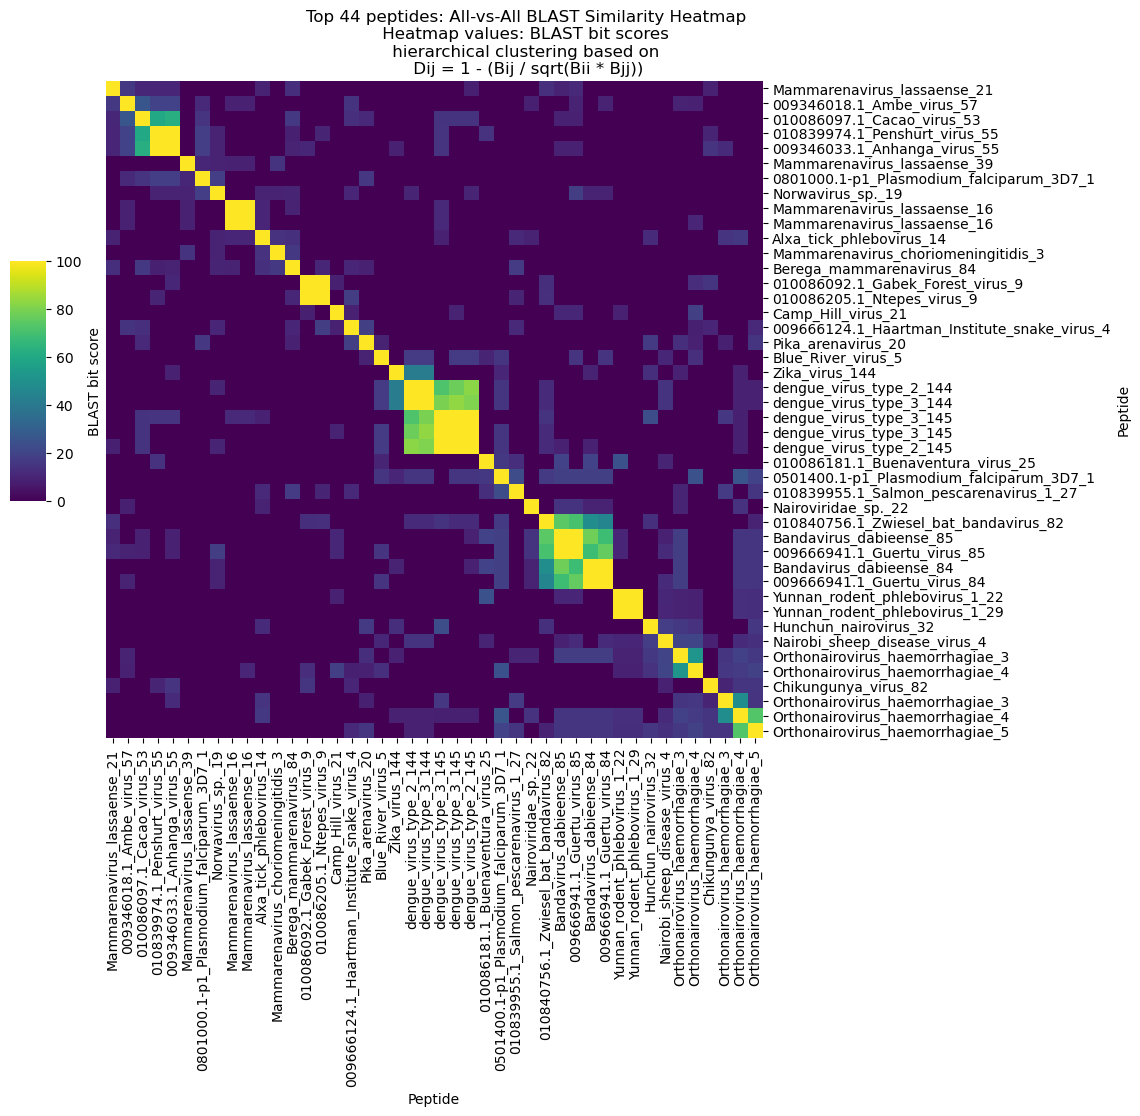

In [ ]:
plot_bitscore_clustermap(bitscore_matrix)

In [ ]:
bitscore_matrix.head()

,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,UHI99942.1_Zika_virus_144,PF3D7_0801000.1-p1_Plasmodium_falciparum_3D7_1,XQZ82370.1_Bandavirus_dabieense_84,XQZ82370.1_Bandavirus_dabieense_85,YP_009666941.1_Guertu_virus_85,YP_009666941.1_Guertu_virus_84,XLT96517.1_dengue_virus_type_3_145,YP_010086092.1_Gabek_Forest_virus_9,WRI50013.1_Norwavirus_sp._19,...,XNX24835.1_Nairobi_sheep_disease_virus_4,XJU75806.1_Camp_Hill_virus_21,APG38067.1_Orthonairovirus_haemorrhagiae_4,YP_009346018.1_Ambe_virus_57,WDW20710.1_Berega_mammarenavirus_84,AYD75258.1_Mammarenavirus_lassaense_21,YP_009666124.1_Haartman_Institute_snake_virus_4,WFG38027.1_Pika_arenavirus_20,WLV27569.1_Orthonairovirus_haemorrhagiae_5,QGZ98814.1_Chikungunya_virus_82
PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,149.0,10.4,NaN,18.5,18.5,18.5,18.5,NaN,NaN,NaN,...,NaN,NaN,24.8,NaN,NaN,NaN,NaN,NaN,19.7,NaN
UHI99942.1_Zika_virus_144,10.4,160.0,NaN,9.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PF3D7_0801000.1-p1_Plasmodium_falciparum_3D7_1,NaN,NaN,160.0,NaN,NaN,NaN,NaN,NaN,NaN,18.0,...,NaN,NaN,NaN,11.2,NaN,NaN,NaN,15.9,NaN,NaN
XQZ82370.1_Bandavirus_dabieense_84,18.5,9.5,NaN,152.0,77.8,68.5,128.0,NaN,NaN,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.5,NaN
XQZ82370.1_Bandavirus_dabieense_85,18.5,NaN,NaN,77.8,149.0,136.0,68.5,NaN,NaN,NaN,...,9.1,10.8,NaN,NaN,NaN,9.5,NaN,NaN,15.5,NaN


In [ ]:
threshold = 20

matches = (
    bitscore_matrix.where(bitscore_matrix > threshold).stack().reset_index()
)

matches.columns =['peptide1', 'peptide2', 'bitscore']

matches = matches.sort_values('bitscore', ascending=True)

matches.head(20)

,peptide1,peptide2,bitscore
105,XNX24835.1_Nairobi_sheep_disease_virus_4,BAB84576.1_Orthonairovirus_haemorrhagiae_3,20.2
70,BAB84576.1_Orthonairovirus_haemorrhagiae_3,XNX24835.1_Nairobi_sheep_disease_virus_4,20.2
111,APG38067.1_Orthonairovirus_haemorrhagiae_4,XNX24835.1_Nairobi_sheep_disease_virus_4,20.6
107,XNX24835.1_Nairobi_sheep_disease_virus_4,APG38067.1_Orthonairovirus_haemorrhagiae_4,20.6
2,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,YP_010839955.1_Salmon_pescarenavirus_1_27,22.7
102,YP_010839955.1_Salmon_pescarenavirus_1_27,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,22.7
92,XJP49223.1_Hunchun_nairovirus_32,XLT96517.1_dengue_virus_type_3_145,23.1
33,XLT96517.1_dengue_virus_type_3_145,XJP49223.1_Hunchun_nairovirus_32,23.1
109,APG38067.1_Orthonairovirus_haemorrhagiae_4,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1,24.8
81,YP_010086181.1_Buenaventura_virus_25,XOB76307.1_Yunnan_rodent_phlebovirus_1_22,24.8


In [ ]:
top_hits

,mean_z_exposed,mean_z_hbdb,pval,pval_adj,delta_z,neg_log10_p,sequence,species,genus,family,protein_name,fragment,species_corr,is_mm,species_short,frac_enriched,peptide_short
peptide,,,,,,,,,,,,,,,,,
PF3D7_0501400.1-p1|transcript=PF3D7_0501400.1|organism=Plasmodium_falciparum_3D7|gene_product=interspersed_repeat_antigen|tile_1,4675.553818,0.013597,2.114051e-48,2.147588e-47,4675.540221,10.000000,TTQEPVTTQEPVTTQEPVTTQEPVTTQEPVTTQEPVTTQEPVTTQE,NaN,Plasmodium,NaN,NaN,1,Plasmodium_falciparum_3D7,False,unknown,0.982927,PF3D7_0501400.1-p1_Plasmodium_falciparum_3D7_1
UHI99942.1|polyprotein|Zika_virus|isolate=GO24|Homo_sapiens|Brazil:_Goiania-_Goais|01-Apr-2016|segment=?|strain=?|tile_144,231.648357,0.025576,1.215604e-43,1.071821e-42,231.622781,10.000000,HRRDLRLMANAICSSVPVDWVPTGRTTWSIHGRGEWMTTEDMLVVW,Orthoflavivirus zikaense,Orthoflavivirus,Flaviviridae,polyprotein,144,Zika_virus,False,Orthoflavivirus zikaense,0.885366,UHI99942.1_Zika_virus_144
PF3D7_0801000.1-p1|transcript=PF3D7_0801000.1|organism=Plasmodium_falciparum_3D7|gene_product=Plasmodium_exported_protein_(PHISTc)-_unknown_function|tile_1,135.475823,0.406304,1.323871e-44,1.201323e-43,135.069519,10.000000,FDDRDQNIMDRKNFDERNQQVNDRRNFDERNQQVNDRRNFDDRDQN,NaN,Plasmodium,NaN,NaN,1,Plasmodium_falciparum_3D7,False,unknown,0.846341,PF3D7_0801000.1-p1_Plasmodium_falciparum_3D7_1
XQZ82370.1|polymerase|Bandavirus_dabieense|isolate=WQS|Homo_sapiens|China:_Quzhou|2025-02-20|segment=L|strain=?|tile_84,461.111278,0.021004,6.737535e-33,4.483367e-32,461.090274,10.000000,IDNRAMGNIFRDCLEGSLRKQGLMRSKLTEMVEKNVVPLTTQELVD,NaN,Bandavirus,Phenuiviridae,RNA polymerase,84,Bandavirus_dabieense,False,unknown,0.792683,XQZ82370.1_Bandavirus_dabieense_84
XQZ82370.1|polymerase|Bandavirus_dabieense|isolate=WQS|Homo_sapiens|China:_Quzhou|2025-02-20|segment=L|strain=?|tile_85,247.047009,0.007472,1.279062e-33,8.679775e-33,247.039537,10.000000,MRSKLTEMVEKNVVPLTTQELVDILEEDIDFSDVIAVELSEGSLDI,NaN,Bandavirus,Phenuiviridae,RNA polymerase,85,Bandavirus_dabieense,False,unknown,0.770732,XQZ82370.1_Bandavirus_dabieense_85
YP_009666941.1|polymerase|Guertu_virus|isolate=?|Dermacentor_nuttalli|China|May-2013|segment=L|strain=DXM|tile_85,73.110298,0.045485,2.727260e-27,1.577087e-26,73.064813,10.000000,MRSKLSELVEKNVIPLTTQELVDILEEDIDFSDVIATELSEGSLDI,Bandavirus guertuense,Bandavirus,Phenuiviridae,RNA-dependent RNA polymerase,85,Guertu_virus,False,Bandavirus guertuense,0.695122,YP_009666941.1_Guertu_virus_85
YP_009666941.1|polymerase|Guertu_virus|isolate=?|Dermacentor_nuttalli|China|May-2013|segment=L|strain=DXM|tile_84,106.876907,0.015230,1.112439e-30,7.010269e-30,106.861677,10.000000,INNELMGNIFRDCLEGSLRKQGLMRSKLSELVEKNVIPLTTQELVD,Bandavirus guertuense,Bandavirus,Phenuiviridae,RNA-dependent RNA polymerase,84,Guertu_virus,False,Bandavirus guertuense,0.682927,YP_009666941.1_Guertu_virus_84
XLT96517.1|polyprotein|dengue_virus_type_3|isolate=NIMH-1341_Z1_2024-07-22|Homo_sapiens|India|2024-07-22|segment=?|strain=?|tile_145,117.318591,0.010265,5.172946e-24,2.762107e-23,117.308326,10.000000,PWMEDKTPITTWENVPYLGKREGQSCGSLIGLTSRATWAQNIPAAI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,145,dengue_virus_type_3,False,Orthoflavivirus denguei,0.660976,XLT96517.1_dengue_virus_type_3_145
YP_010086092.1|glycoprotein|Gabek_Forest_virus|isolate=Sud_AN_754-61|Acomys_cahirinus|Sudan|1961|segment=M|strain=?|tile_9,87.835441,0.022714,1.530880e-20,7.472657e-20,87.812726,10.000000,EHRARLNELNQQKSDFAEEVSRLKEEMKVIRERKEESTKAAMAKEQ,Phlebovirus gabekense,Phlebovirus,Phenuiviridae,membrane glycoprotein,9,Gabek_Forest_virus,False,Phlebovirus gabekense,0.568293,YP_010086092.1_Gabek_Forest_virus_9


## Main question: what is the evidence in my data that suppports seroprevalence for each viral genus? 

In [ ]:
#first have to concat df (so survivors and contacts RPK) and the df_HBDB (US healthies RPK)

df_all = pd.concat([df, df_hbdb], axis=1)

#subset to contacts, survivors and HBDBs

df_all = df_all.filter(regex=('^C-|^S-|^HBDB'))

In [ ]:
#now going to locate protein metadata peptides belonging to Dengue and Zika 

cols_to_search = ['seq_id', 'species', 'taxonomy_lineage']

mask_dengue = protein_metadata[cols_to_search].apply(lambda x: x.str.contains('dengue', na=False, case=False)) #use na=False to handle missing (NaN values) and case=False to make the search case-insensitive
mask_zika = protein_metadata[cols_to_search].apply(lambda x: x.str.contains('zika', na=False, case=False))
mask_lassa = protein_metadata[cols_to_search].apply(lambda x: x.str.contains('lassa', na=False, case=False))

#collapse to one column = was e.g. 'dengue' found in any column for this row? use that boolean Series
#to filter protein_metadata_kept_peps 
dengue_peptides = protein_metadata[mask_dengue.any(axis=1)].set_index('seq_id') #collapses the boolean mask into a single column, marking a row True if any of its columns is matched
zika_peptides = protein_metadata[mask_zika.any(axis=1)].set_index('seq_id')
lassa_peptides = protein_metadata[mask_lassa.any(axis=1)].set_index('seq_id')

#now going to subset df_all to those peptides 
#drop rows where all values are missing

dengue_df_all = df_all[df_all.index.isin(dengue_peptides.index)].dropna(how='all')
zika_df_all = df_all[df_all.index.isin(zika_peptides.index)].dropna(how='all')
lassa_df_all = df_all[df_all.index.isin(lassa_peptides.index)].dropna(how='all')


{'Exposed dengue': (np.float64(1295832.1406641775), 410), 'Healthy dengue': (np.float64(250777.77119306964), 88), 'Exposed zika': (np.float64(168162.2788242753), 410), 'Healthy zika': (np.float64(28197.11890240735), 88), 'Exposed lassa': (np.float64(1836716.09439719), 410), 'Healthy lassa': (np.float64(406846.1441206536), 88)}


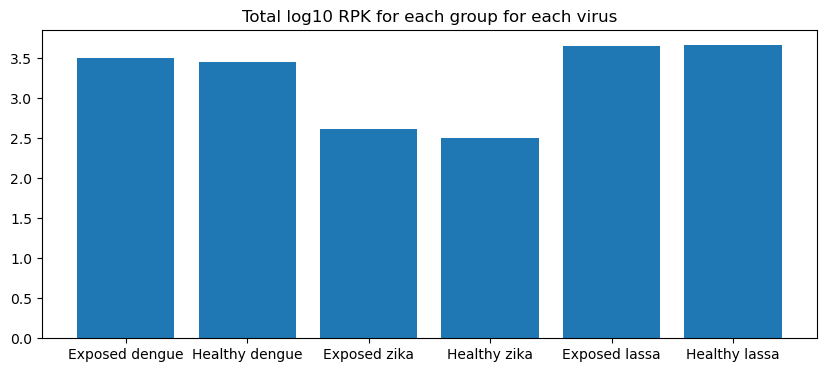

In [ ]:
virus_dfs = {
    'dengue' : dengue_df_all, 
    'zika': zika_df_all, 
    'lassa': lassa_df_all
}

results = {}

"""
in this step I have a dictionary with two values, the Exposed dengue and the Exposed healthies value. the key is basically the cumulative RPK for those viral peptides for each group
"""

#using .items() to pair key values into a tuple
for virus, df in virus_dfs.items():
    exposed = df.filter(regex=('^C-|^S-'))
    healthies = df.filter(regex=('^HBDB-'))
    #each entry in results stores a tuple of two numbers
    results[f'Exposed {virus}'] = (exposed.sum().sum(), exposed.shape[1])
    results[f'Healthy {virus}'] = (healthies.sum().sum(), healthies.shape[1])

print(results)

"""
Now I am going to sum the RPKs and normalize to group size
"""

norm_values = {
    group: total / n_samples
    for group, (total, n_samples) in results.items()
}

#convert to a series
norm_values = pd.Series(norm_values)

"""
Plot figure
"""

plt.figure(figsize=(10, 4))
plt.bar(norm_values.index, np.log10(norm_values))
plt.title('Total log10 RPK for each group for each virus')
plt.show()



## Now subsetting to include only peptides which 
1. passed the initial the stringent z_scoring threshold > 3 in >= 1% of exposed compared vs HBDB healthies, 
2. showed significantly higher reactivity in Lassa exposed vs healthies by MWU test BH-adjusted FDR < 0.05, where HBDB z-scores were computed with LOO correction to avoid self-comparison bias, and 
3. are enriched in the exposed direction (dz > 0)

- repeat from previous block, but now only focus on those peptides which passed the threshold. 
- see if the barplots change! (and report how many peptides were kept)

In [ ]:
#kept_peps was computed earlier on and are the peptides that pass z_score threshold of 3 over healthies and in more than 10% of exposed (survivor + contact)
kept_peps = sig_peps

#set index to seq_id in protein_metadata
protein_metadata = protein_metadata.set_index('seq_id')

In [ ]:
#subset protein_metadata to kept_peps
protein_metadata_kept_peps = protein_metadata[protein_metadata.index.isin(kept_peps)]

#reset index
protein_metadata_kept_peps = protein_metadata_kept_peps.reset_index()

In [ ]:
cols_to_search = ['seq_id', 'species', 'taxonomy_lineage']

#now subsetting again to Dengue and Zika -- finds which rows match dengue/zika/lassa
mask_dengue = protein_metadata_kept_peps[cols_to_search].apply(lambda x: x.str.contains('dengue', na=False, case=False)) #use na=False to handle missing (NaN values) and case=False to make the search case-insensitive
mask_zika = protein_metadata_kept_peps[cols_to_search].apply(lambda x: x.str.contains('zika', na=False, case=False))
mask_lassa = protein_metadata_kept_peps[cols_to_search].apply(lambda x: x.str.contains('lassa', na=False, case=False))

#collapse to one column = was e.g. 'dengue' found in any column for this row? use that boolean Series
#to filter protein_metadata_kept_peps 
dengue_peptides = protein_metadata_kept_peps[mask_dengue.any(axis=1)].set_index('seq_id') #collapses the boolean mask into a single column, marking a row True if any of its columns is matched
zika_peptides = protein_metadata_kept_peps[mask_zika.any(axis=1)].set_index('seq_id')
lassa_peptides = protein_metadata_kept_peps[mask_lassa.any(axis=1)].set_index('seq_id')

#now going to subset df_all to those peptides and drop rows where all values are missing

dengue_df_all = df_all[df_all.index.isin(dengue_peptides.index)].dropna(how='all')
zika_df_all = df_all[df_all.index.isin(zika_peptides.index)].dropna(how='all')
lassa_df_all = df_all[df_all.index.isin(lassa_peptides.index)].dropna(how='all')

{'exposed dengue': (np.float64(504265.70911812433), 410), 'healthies dengue': (np.float64(16302.262703622899), 88), 'exposed zika': (np.float64(49884.08128169048), 410), 'healthies zika': (np.float64(2255.539560974984), 88), 'exposed lassa': (np.float64(619590.6813146158), 410), 'healthies lassa': (np.float64(25449.697058059915), 88)}
{'exposed dengue': np.float64(1229.9163637027423), 'healthies dengue': np.float64(185.25298526844202), 'exposed zika': np.float64(121.66849093095239), 'healthies zika': np.float64(25.631131374715725), 'exposed lassa': np.float64(1511.196783694185), 'healthies lassa': np.float64(289.20110293249905)}


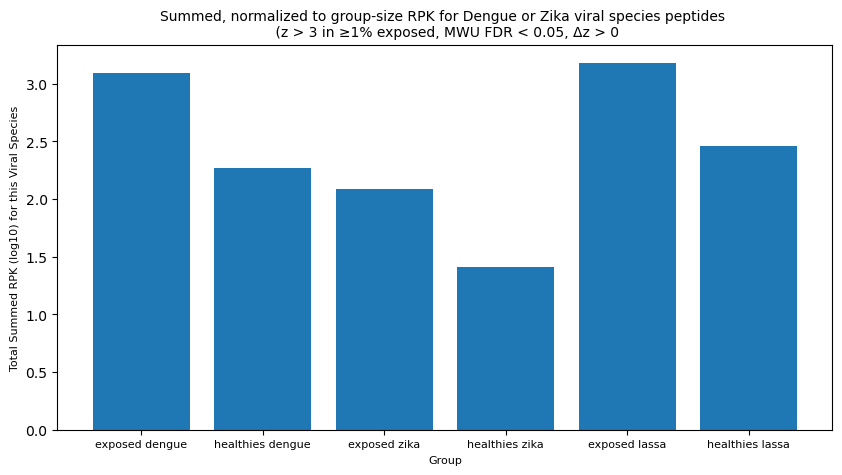

In [ ]:
"""
define virus dataframes
"""

virus_dfs = {
    'dengue': dengue_df_all,
    'zika': zika_df_all,
    'lassa' : lassa_df_all
}

"""
split into exposed/healthies, sum, and normalize in one pass
"""
#dictionary where key will be exposed_virus or healthy_virus and the value will be the cumulative RPK for all peptides belonging to that virus for exposed / healthy group
results = {}

for virus, df in virus_dfs.items():
    exposed = df.filter(regex=('^C-|^S-'))
    healthies = df.filter(regex='^HBDB')

    results[f'exposed {virus}'] = (exposed.sum().sum(), exposed.shape[1])
    results[f'healthies {virus}'] = (healthies.sum().sum(), healthies.shape[1])

print(results)

"""
normalize directly by using the dictionary
"""

norm_values = {name: total / n_samples for name, (total, n_samples) in results.items()}

print(norm_values)

"""
plot
"""
plt.figure(figsize=(10, 5))
#norm_values.values() returns a dict_values view object, not a sequence. need to convert to a list or array or series so numpy can process it. 
#converting the dictionary to a Series. note: list is plain, can't do any math operations though. Array (numpy) is math-friendly, but no labels, just values
#series is like an array, but every value has a label (so an index)
s = pd.Series(norm_values)

plt.bar(s.index, np.log10(s))

#add labels and title
plt.xlabel('Group', fontsize=8)
plt.ylabel('Total Summed RPK (log10) for this Viral Species', fontsize=8)
plt.xticks(fontsize=8)
plt.title('Summed, normalized to group-size RPK for Dengue or Zika viral species peptides ' \
f'\n (z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0', fontsize=10)
plt.show()

In [ ]:
exposed_dengue = dengue_df_all.filter(regex=('^C-|^S-'))
healthies_dengue = dengue_df_all.filter(regex='^HBDB')

exposed_zika = zika_df_all.filter(regex=('^C-|^S-'))
healthies_zika = zika_df_all.filter(regex='^HBDB')

exposed_lassa = lassa_df_all.filter(regex=('^C-|^S-'))
healthies_lassa = lassa_df_all.filter(regex='^HBDB')

exposed_orig_df = df_all.filter(regex=('^C-|^S-'))
healthies_orig_df = df_all.filter(regex='^HBDB')


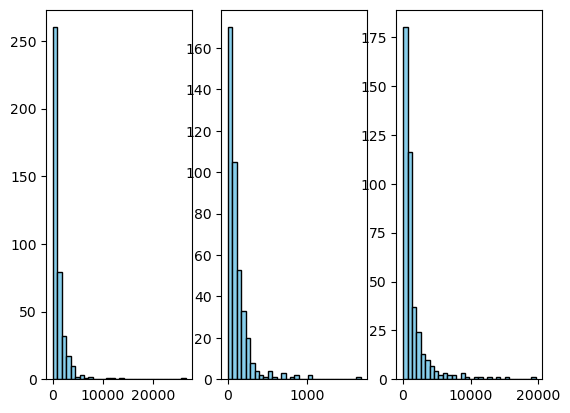

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#create 1 row and 3 columns 
fig, axs = plt.subplots(1, 3)

#the first sum gives sum for each column

axs[0].hist(exposed_dengue.sum(), bins=30, color='skyblue', edgecolor='black')
axs[1].hist(exposed_zika.sum(), bins=30, color='skyblue', edgecolor='black')
axs[2].hist(exposed_lassa.sum(), bins=30, color='skyblue', edgecolor='black')

plt.show()

#data is non-normally distributed - use

/tmp/ipykernel_4016221/4055269345.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Exposed {virus} \nn= {len(exposed)}', f'Healthies {virus} \nn= {len(healthies)}'], y=means, palette='muted', ax=ax)
/tmp/ipykernel_4016221/4055269345.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Exposed {virus} \nn= {len(exposed)}', f'Healthies {virus} \nn= {len(healthies)}'], y=means, palette='muted', ax=ax)
/tmp/ipykernel_4016221/4055269345.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Exposed {virus} \nn= {len(exposed)}', f

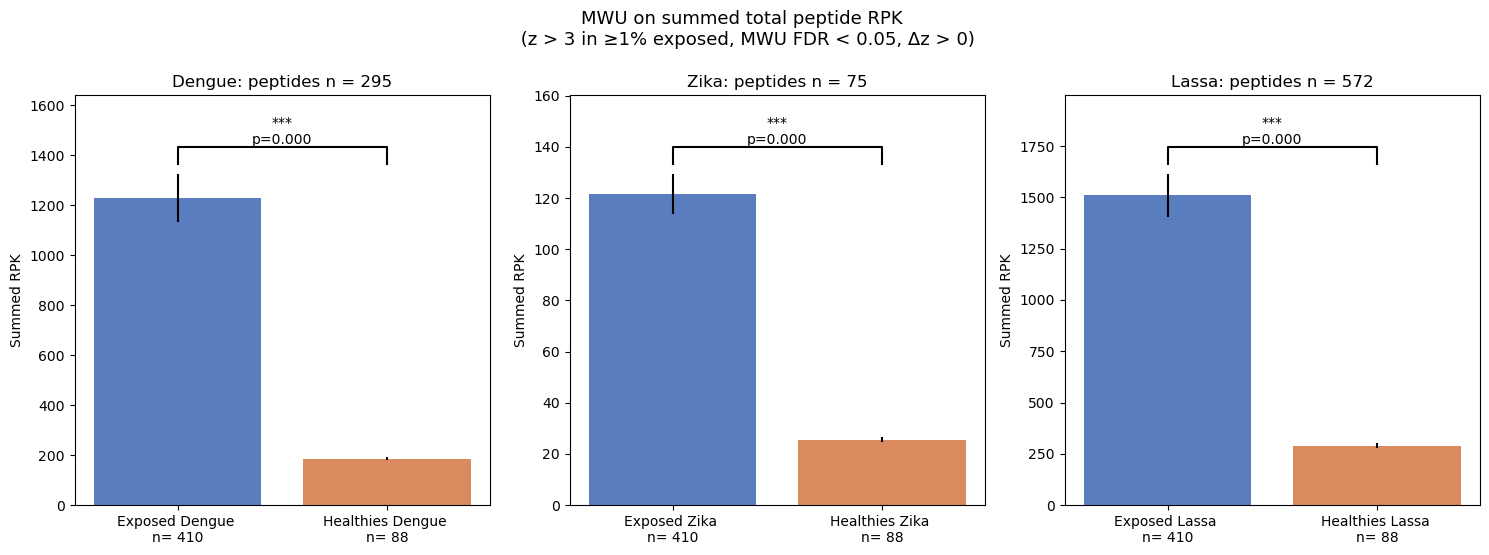

In [ ]:
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

#use Mann-Whitney U test as I am comparing non-normally distributed data. Evaluates if the probability of an observation in one group is greater than an observation in the other

#create 1 row and 3 columns 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

data = [
    ('Dengue', exposed_dengue.sum(), healthies_dengue.sum(), exposed_dengue.shape),
    ('Zika', exposed_zika.sum(), healthies_zika.sum(), exposed_zika.shape),
    ('Lassa', exposed_lassa.sum(), healthies_lassa.sum(), exposed_lassa.shape)
]

#zip() zips elements from the same position in each input together into pairs, so here ax[0] and data[0] for example
for ax, (virus, exposed, healthies, peptides) in zip(axes, data):
    means = [np.mean(exposed), np.mean(healthies)]
    sems = [np.std(exposed)/np.sqrt(len(exposed)), np.std(healthies)/np.sqrt(len(healthies))]

    sns.barplot(x=[f'Exposed {virus} \nn= {len(exposed)}', f'Healthies {virus} \nn= {len(healthies)}'], y=means, palette='muted', ax=ax)
    ax.errorbar(x=[0,1], y=means, yerr=sems, fmt='none', c='black')
    ax.set_title(virus + ': ' + 'peptides n = ' + str(peptides[0]))

    ax.set_ylabel('Summed RPK')

    #run MannwhitneyU test and add the statistical annotation
    stat, p_val = mannwhitneyu(exposed, healthies, alternative='two-sided')
    
    #significance starts
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else: 
        sig = 'na'

    #draw bracket + annotation above the taller bar, first find the top of the taller bar, then adds 10% padding so the bracket sits above it without touching the bar
    y_max = max(means[0] + sems[0], means[1] + sems[1]) * 1.03
    #now we are drawing the bracket, the four x, y coordinate pairs trace the shape [x1, x2, x3, x4], [y1, y2, y3, y4], yielding points (x1, y1) etc. 
    #lw is linewidth
    ax.plot([0, 0, 1, 1], [y_max, y_max * 1.05, y_max * 1.05, y_max], c='black', lw=1.5)
    #this now places the text (stars + p-value) centered horizontally between the two bars (x=0.5)
    ax.text(0.5, y_max * 1.05, f'{sig}\np={p_val:.3f}', ha='center', va='bottom', fontsize=10)

    ax.set_ylim(top=y_max + y_max*0.2)


plt.tight_layout()
fig.suptitle(f'MWU on summed total peptide RPK \n (z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0)',fontsize=13, y=1.1)
plt.show()




### now look at where the peptides map - is the signal across entire proteins? or only one peptide (likely false positive)
starting with dengue

In [ ]:
#subsetting the protein_metadata table to only peptides filtered in exposed
protein_metadata_exposed_dengue = protein_metadata[protein_metadata.index.isin(exposed_dengue.index)]
protein_metadata_healthies_dengue = protein_metadata[protein_metadata.index.isin(healthies_dengue.index)]

protein_metadata_exposed_zika = protein_metadata[protein_metadata.index.isin(exposed_zika.index)]
protein_metadata_healthies_zika = protein_metadata[protein_metadata.index.isin(healthies_zika.index)]

In [ ]:
#sum RPK values for individual tiles of DENV polyprotein peptides (filtered)

#take tile numbers
dengue_fragment_nums = protein_metadata_exposed_dengue.fragment
s = dengue_fragment_nums

#group indices by the identical series value (so same tile num) 
#need a lambda that extracts the index, as .apply(list) returns the values in each group, not the indices
#s.groupby(s) means that pandas should group this series by its own values - so all indices that share the same value are grouped together
#list() applies inside each group, converting each groups indices to a list
#groupby() always returns a series (or df) - a series always has an index (labels), and you can access values with my_series[label]
#this returns a series, where index is the tile num and values is list of peptide indices
dengue_peps_grouped_by_tile_num = s.groupby(s).apply(lambda x: list(x.index)) 

# ----- same for healthies_dengue -----
dengue_healthies_fragment_nums = protein_metadata_healthies_dengue.fragment
sh = dengue_healthies_fragment_nums

#sh groupby sh groups the index by the corresponding value, so here by the tile value. equivalent to sh.groupby(sh.values)
#regarding the lambda function, x is a sub-Series, one chunk of sh for a single group, so one tile number. x.index gives the original index labels of that chunk
#and list() converts those index labels into a plain python list. so for each tile group, the rows in which sh belonged to this tile are extracted and returned as a list. 
dengue_healthies_peps_grouped_by_tile_num = sh.groupby(sh).apply(lambda x:list(x.index))

/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


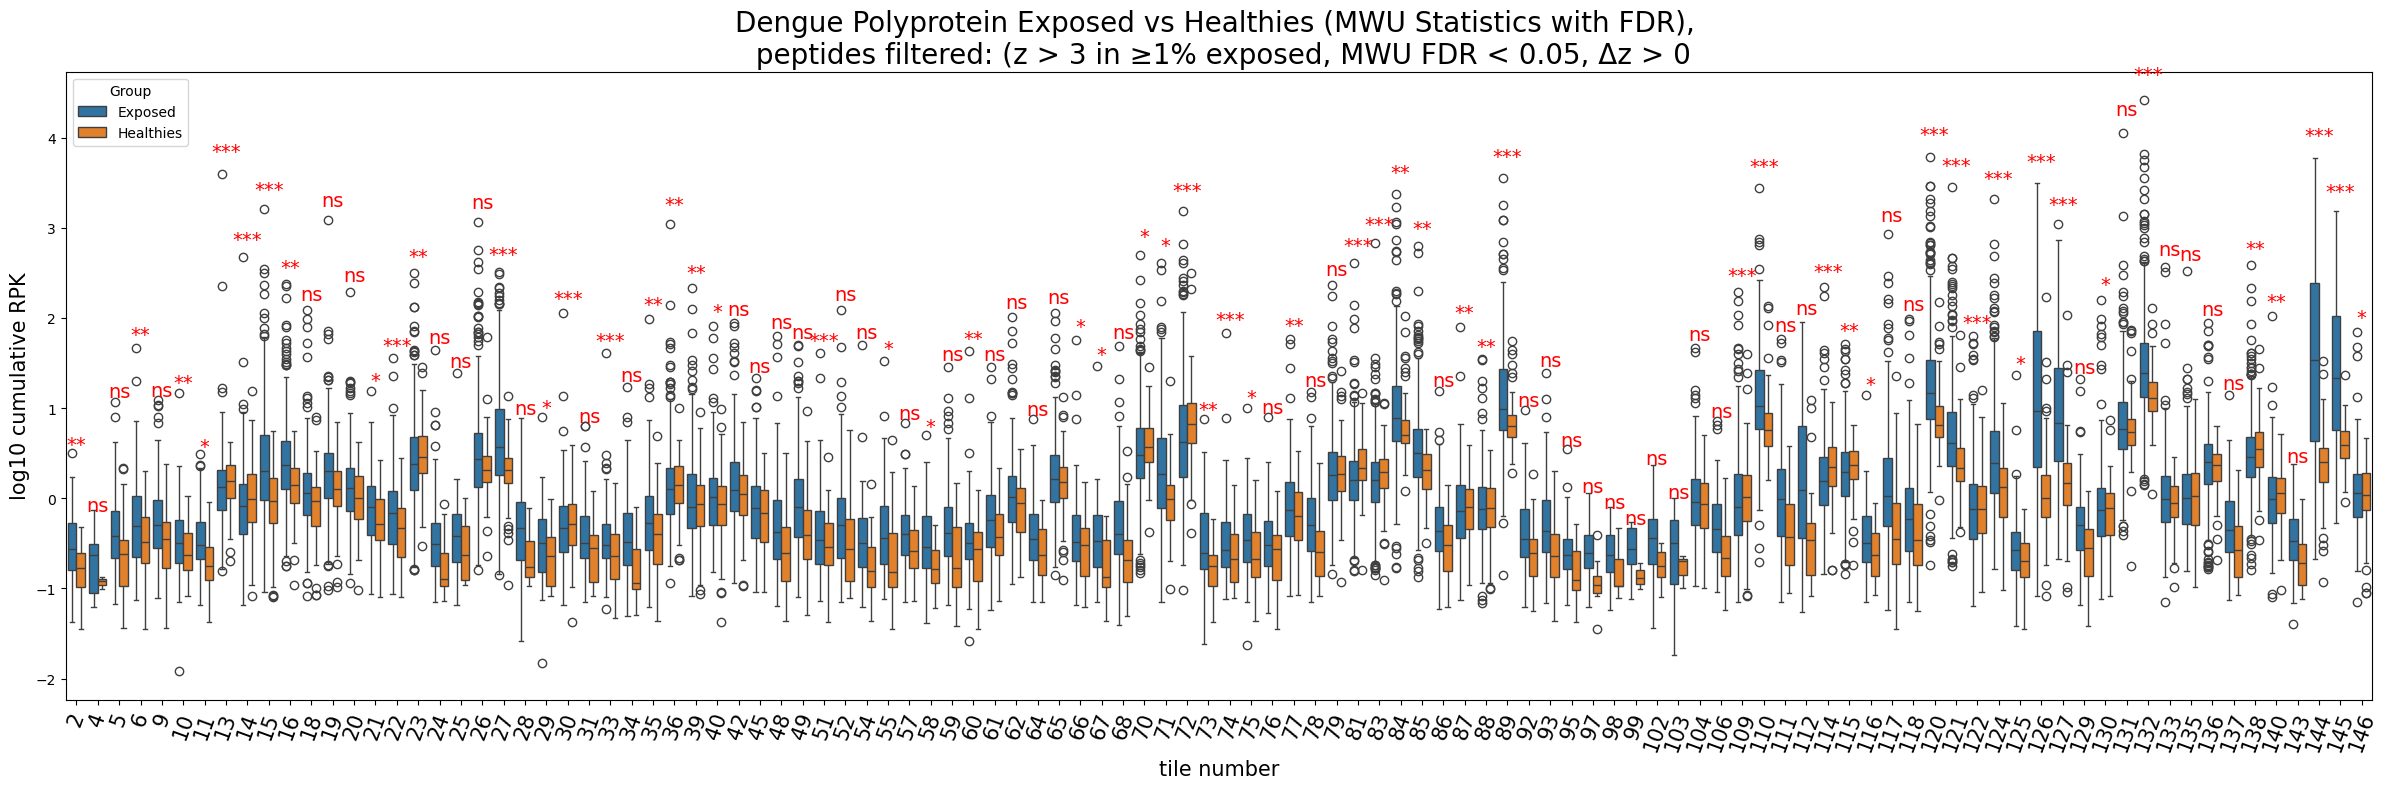

In [ ]:
cumulative_rpk = {}

#pair index and value together with .items()
for index, value in dengue_peps_grouped_by_tile_num.items():
    cumulative_rpk[index] = exposed_orig_df.loc[value].sum()

cumulative_log_rpk = {k: np.log10(v) for k, v in cumulative_rpk.items()}

exposed_df = pd.DataFrame(cumulative_log_rpk)

exposed_long = exposed_df.reset_index().melt(id_vars='index', 
                                             var_name='tile_num', value_name='log10_RPK')
exposed_long.rename(columns={'index': 'sample'}, inplace=True)
exposed_long['Group'] = 'Exposed'

#--- same for healthies
cumulative_healthies_rpk = {}
for index, value in dengue_healthies_peps_grouped_by_tile_num.items():
    cumulative_healthies_rpk[index] = healthies_orig_df.loc[value].sum()

cumulative_healthies_log_rpk = {k: np.log10(v) for k, v in cumulative_healthies_rpk.items()}

healthies_df = pd.DataFrame(cumulative_healthies_log_rpk)
healthies_long = healthies_df.reset_index().melt(id_vars='index', var_name='tile_num', value_name='log10_RPK')
healthies_long.rename(columns={'index': 'sample'}, inplace=True)
healthies_long['Group'] = 'Healthies'

#--combine long df and plot
#reset_index to df_long doesn't have duplicate row indices, and drop=True so that no new column gets added to Df called index
df_long = pd.concat([exposed_long, healthies_long]).sort_values('tile_num').reset_index(drop=True)
tile_order = sorted(df_long['tile_num'].unique())

fig, ax = plt.subplots(figsize=(24, 8))
sns.boxplot(x='tile_num', y='log10_RPK', hue='Group', data=df_long, order=tile_order, ax=ax)

pvals = []
tiles_tested = []

for i, tile in enumerate(tile_order):
    exp_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Exposed')]['log10_RPK'].dropna()
    hlt_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Healthies')]['log10_RPK'].dropna()

    if len(exp_vals) < 3 or len(hlt_vals) < 3:
        continue

    _, p = mannwhitneyu(exp_vals, hlt_vals, alternative='two-sided')

    pvals.append(p)
    tiles_tested.append(tile)

    
# correct after loop
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
pvals_dict = dict(zip(tiles_tested, pvals_adj))

# second loop: add annotations using adjusted p-values
for i, tile in enumerate(tile_order):
    if tile not in pvals_dict:
        continue

    exp_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Exposed')]['log10_RPK'].dropna()
    hlt_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Healthies')]['log10_RPK'].dropna()

    p_adj = pvals_dict[tile]
    if p_adj < 0.001:  sig = '***'
    elif p_adj < 0.01: sig = '**'
    elif p_adj < 0.05: sig = '*'
    else:              sig = 'ns'

    y_max = max(exp_vals.max(), hlt_vals.max())
    ax.text(i, y_max * 1.05, sig, ha='center', fontsize=14, color='red')

plt.xticks(rotation=70, fontsize=15)
plt.title(f'Dengue Polyprotein Exposed vs Healthies (MWU Statistics with FDR), \n peptides filtered: (z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0', fontsize=20)
plt.ylabel('log10 cumulative RPK', fontsize=15)
plt.xlabel('tile number', fontsize=15)
plt.tight_layout()

plt.show()


now doing zika

- like dengue, zika also translated one single polyprotein, which immediately gets cut by viral and host enzymes into 3 structural and 7 non-structural proteins
nevertheless, zika does not has different serotypes (unlike denv, which has 4)
- both from the family of flaviviruses spread by the same type of mosquito (aedes aegypti)
- roughly 55% sequence identity on an amino acid level, but NS1 has even higher, around 70% sequence similarity between dengue and zika (past dengue infection can lead to false positive zika infection)

In [ ]:
#sum RPK values for individual tiles of DENV polyprotein peptides (filtered)

#take tile numbers
zika_fragment_nums = protein_metadata_exposed_zika.fragment
s = zika_fragment_nums

#group indices by the identical series value (so same tile num) 
#need a lambda that extracts the index, as .apply(list) returns the values in each group, not the indices
#s.groupby(s) means that pandas should group this series by its own values - so all indices that share the same value are grouped together
#list() applies inside each group, converting each groups indices to a list
#groupby() always returns a series (or df) - a series always has an index (labels), and you can access values with my_series[label]
#this returns a series, where index is the tile num and values is list of peptide indices
zika_peps_grouped_by_tile_num = s.groupby(s).apply(lambda x: list(x.index)) 

# ----- same for healthies_dengue -----
zika_healthies_fragment_nums = protein_metadata_healthies_zika.fragment
sh = zika_healthies_fragment_nums

zika_healthies_peps_grouped_by_tile_num = sh.groupby(sh).apply(lambda x:list(x.index))

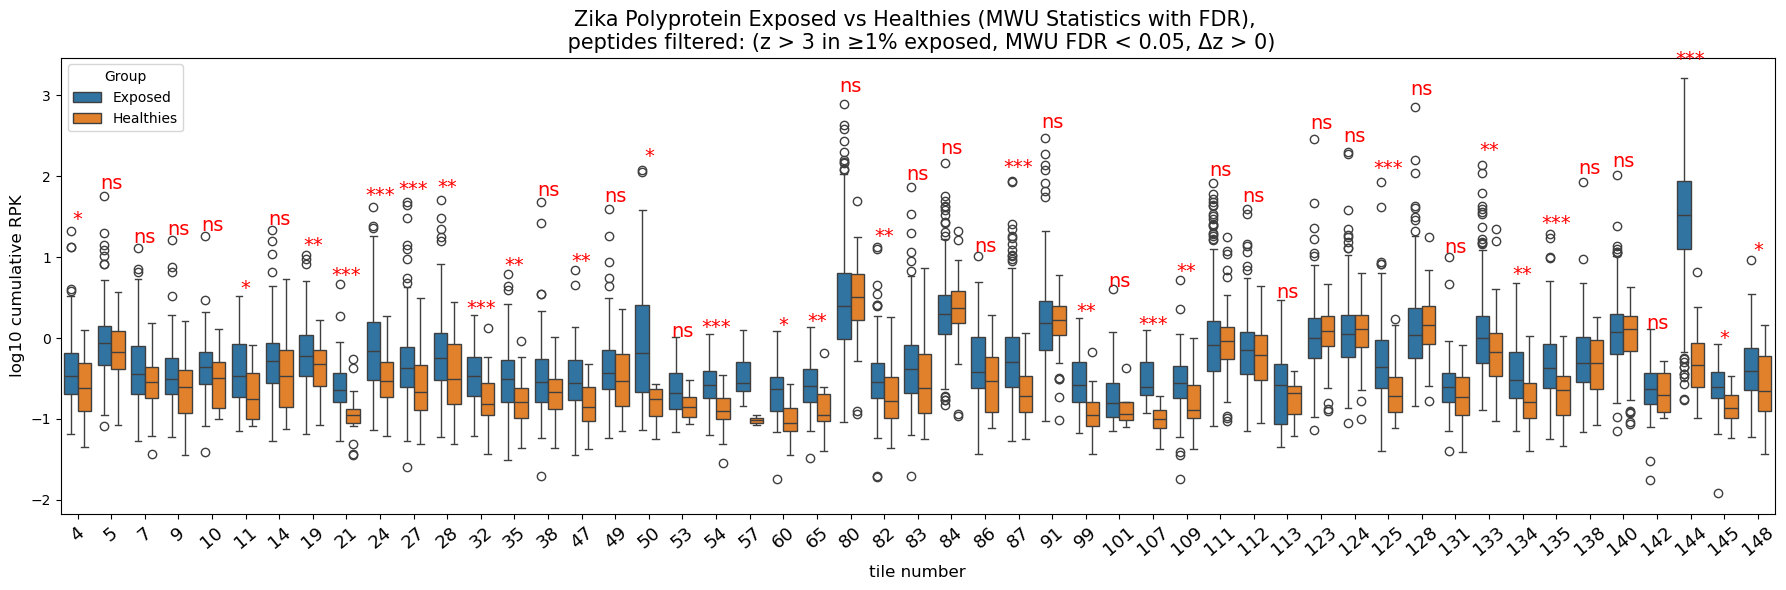

In [ ]:
cumulative_rpk = {}

#pair index and value together with .items()
for index, value in zika_peps_grouped_by_tile_num.items():
    cumulative_rpk[index] = exposed_orig_df.loc[value].sum() #cumulative rpk for all peptides belonging to this tile (using the list of peptide indices)

#I was getting -inf values, so decide to replace any zeros with np.nan. Note need to omit those in MWU statistics!
cumulative_log_rpk = {k: np.log10(v.replace(0, np.nan)) for k, v in cumulative_rpk.items()}
exposed_df = pd.DataFrame(cumulative_log_rpk)

exposed_long = exposed_df.reset_index().melt(id_vars='index', 
                                             var_name='tile_num', value_name='log10_RPK')
exposed_long.rename(columns={'index': 'sample'}, inplace=True)
exposed_long['Group'] = 'Exposed'

#--- same for healthies
cumulative_healthies_rpk = {}
for index, value in zika_healthies_peps_grouped_by_tile_num.items():
    cumulative_healthies_rpk[index] = healthies_orig_df.loc[value].sum()

cumulative_healthies_log_rpk = {k: np.log10(v.replace(0, np.nan)) for k, v in cumulative_healthies_rpk.items()}
healthies_df = pd.DataFrame(cumulative_healthies_log_rpk)

#id_vars to mark column that stays a column (or columns) and are not collapsed, var_name is a custom string name for the new column that stores the original column headers
#value_name is custom string name for the new column that stores the data values
#need to reset_index if the current df contains meaningful identifiers in the index, as melt operates on columns.
healthies_long = healthies_df.reset_index().melt(id_vars='index', var_name='tile_num', value_name='log10_RPK')
healthies_long.rename(columns={'index': 'sample'}, inplace=True)
healthies_long['Group'] = 'Healthies'

#--combine long df and plot
#reset_index to df_long doesn't have duplicate row indices, and drop=True so that no new column gets added to Df called index
df_long = pd.concat([exposed_long, healthies_long]).sort_values('tile_num').reset_index(drop=True)
tile_order = sorted(df_long['tile_num'].unique())

fig, ax = plt.subplots(figsize=(18, 6))
sns.boxplot(x='tile_num', y='log10_RPK', hue='Group', data=df_long, order=tile_order, ax=ax)

pvals = []
tiles_tested = []

for i, tile in enumerate(tile_order):
    exp_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Exposed')]['log10_RPK'].dropna()
    hlt_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Healthies')]['log10_RPK'].dropna()

    if len(exp_vals) < 3 or len(hlt_vals) < 3:
        continue

    _, p = mannwhitneyu(exp_vals, hlt_vals, alternative='two-sided')

    pvals.append(p)
    tiles_tested.append(tile)

    
# correct after loop
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
pvals_dict = dict(zip(tiles_tested, pvals_adj))

# second loop: add annotations using adjusted p-values
for i, tile in enumerate(tile_order):
    if tile not in pvals_dict:
        continue

    exp_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Exposed')]['log10_RPK'].dropna()
    hlt_vals = df_long[(df_long['tile_num'] == tile) & (df_long['Group'] == 'Healthies')]['log10_RPK'].dropna()

    p_adj = pvals_dict[tile]
    if p_adj < 0.001:  sig = '***'
    elif p_adj < 0.01: sig = '**'
    elif p_adj < 0.05: sig = '*'
    else:              sig = 'ns'

    y_max = max(exp_vals.max(), hlt_vals.max())
    ax.text(i, y_max * 1.05, sig, ha='center', fontsize=14, color='red')

plt.xticks(rotation=40, fontsize=13)
plt.title(f'Zika Polyprotein Exposed vs Healthies (MWU Statistics with FDR), \n peptides filtered: (z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0)', fontsize=15)
plt.ylabel('log10 cumulative RPK', fontsize=12)
plt.xlabel('tile number', fontsize=12)
plt.tight_layout()
plt.show()


### use alignment bitscores for peptides that are similar, and assess cross-reactivity for a specific genus / family 
- for a given viral species, if I lower (or increase) bitscore from cross-reacting peptides from the same genus for example, does the signal for that protein increase? supporting evidence of exposure 

In [ ]:
"""
Defining the target: starting with zika peptides because there are only a few of them belonging to one protein, the polyprotein
"""

protein_metadata.head(2)

protein_metadata_kept_peps = protein_metadata_kept_peps.set_index('seq_id')
protein_metadata_kept_peps.head(2)

# ----- 1. related peptides means same genus, so genus Flavivirus

protein_metadata_genus = protein_metadata_kept_peps[protein_metadata_kept_peps['genus'] == 'Orthoflavivirus']

#subsetting df_all to those peptides that belong to genus Orthoflavivirus and passed filtering in previous step
peptides_genus_df = df_all.loc[protein_metadata_genus.index]

In [ ]:
# ----- 2. signal will be measured with raw RPK first, but only from the peptides which were filtered as they exceeded z_score > 3 in >= 10% of exposed

"""
Gather the target peptides: 
- pull all peptides to the chosen species
- subset to a chosen protein, if needed
- save as target peptide set (if not yet done)
"""
target_peptides = protein_metadata_exposed_zika

"""
Identify related non-target peptides from the same genus: 
- for each target peptide, find aligned peptides from other species
- keep only peptides with the same genus (or family)
- remove weak alignments below a chosen bitscore threshold
"""

protein_metadata_genus.sequence

protein_metadata_exposed_zika.sequence

import numpy as np 
from Bio import Align
from Bio.Align import substitution_matrices 

def calculate_bitscore(seq1, seq2, matrix_name='BLOSUM62'):
    #load the specified substitution matrix and associated parameters
    matrix = substitution_matrices.load(matrix_name)

    #initialize the aligner with affine gap scores
    aligner = Align.PairwiseAligner()
    aligner.substitution_matrix = matrix
    aligner.open_gap_score = -11
    aligner.extend_gap_score = -1

    #1. calculate raw alignment score
    raw_score = aligner.score(seq1, seq2)

    #2. extract karlin-altschul parameters (lambda and k)
    #default parameters for BLOSUM62 are well-documented (fixed parameters)
    #important that these parameters are specific to the chosen substitution matrix
    lambd = 0.318
    K = 0.130

    #3. calculate bitscore using Karlin-Altschul formula
    #S' = (lambda * 2 - ln(K)) / ln(2)
    bitscore = (lambd * raw_score - np.log(K)) / np.log(2)

    return raw_score, bitscore 

results = pd.DataFrame(
    index = protein_metadata_exposed_zika.index,
    columns= protein_metadata_genus.index,
    dtype=float
)

for pepA, seqA in list(zip(protein_metadata_exposed_zika.index, protein_metadata_exposed_zika['sequence'])):
    for pepB, seqB in list(zip(protein_metadata_genus.index, protein_metadata_genus['sequence'])):
        
        results.loc[pepA, pepB] = calculate_bitscore(seqA, seqB)[1] #to return bitscore but not raw score

"""
Summarize cross-reactivity per target peptide:
for each target peptide, calculate one summary of similarity to related non-target peptides, such as the average bitscore
in this case this means that I will collapse the matrix from n_zika x n_genus down to n_zika x 1 giving each zika target peptide
this gives me one number per zika peptide to use downstream

- make sure to remove columns that are themselves zika peptides from the results matrix
"""

BITSCORE_THRESH = 30

#get unique zika peptide indices, to be filtered out of the results matrix
zika_idx = set(protein_metadata_exposed_zika.index)
non_target_cols = [c for c in results.columns if c not in zika_idx]
self_cols = [c for c in results.columns if c in zika_idx]

print('Total Orthoflavivirus columns', results.shape[1])
print(f'Total zika self-columns detected : {len(self_cols)}')
print(f'Non-Zika columns for scoring: {len(non_target_cols)}')

results_non_target = results[non_target_cols]

"""
going to make a df of summary metrix of those results_non_target_cols bitscore results. then choose one (or compare them) in the steps below
"""

cross_rxn = pd.DataFrame(index = results_non_target.index)

cross_rxn['max_bitscore'] = results_non_target.max(axis=1)
cross_rxn['mean_bitscore'] = results_non_target.mean(axis=1)
cross_rxn['sum_bitscore'] = results_non_target.sum(axis=1)
cross_rxn['n_hits_above_thresh'] = (results_non_target > BITSCORE_THRESH).sum(axis=1)

#here, first columns with those names are being generated (sequence, species, protein_name, fragment) for the cross_rxn df
#then those values from protein_metadata_exposed_zika are being looked up for those columns
#for each row in cross_rxn, it finds the matching index for protein_metadata_exposed_zika and copies the values across
cross_rxn[['sequence', 'species', 'protein_name', 'fragment']] = \
    protein_metadata_exposed_zika[['sequence', 'species', 'protein_name', 'fragment']]

print(f"Cross-reactivity for zika peptides for non-zika orthoflavivirus peptides is being assessed, the bitscore threshold was \
      set to be {BITSCORE_THRESH}")
print(cross_rxn.sort_values('max_bitscore', ascending=False).to_string())


"""
I am going to continue with visualizing the n_hits_above_thresh
"""

# rename_axis gives the two axes distinct names before stacking, avoiding the
# "cannot insert seq_id, already exists" collision that happens when both the
# row index and column index are both named seq_id
hits_above = (
    results_non_target.astype(float)
    .reset_index()
    .rename(columns={'seq_id': 'zika_peptide'})
    .melt(id_vars='zika_peptide', 
          var_name='non_zika_peptide',
          value_name='bitscore')
)

#after filtering for only rows above the bitscore threshold, I am left with a non-contiguous subset of those integers (indices came from the melt() operation)

hits_above = hits_above[hits_above['bitscore'] > BITSCORE_THRESH].sort_values('bitscore', ascending=False)

print(f"\nPairs above bitscore threshold ({BITSCORE_THRESH}): {len(hits_above)}")
print(hits_above.to_string()[:5])

"""
So the next step here could be to add a penalty model, so I would down-weight peptides surpassing a certain threshold
I could later multiply those weights for each peptide with the raw RPK table to adjust those

so for example in my z_score_mat table, peptides more similar to non-Zika flaviviruses would contribute less 
"""


Total Orthoflavivirus columns 438
Total zika self-columns detected : 70
Non-Zika columns for scoring: 368
Cross-reactivity for zika peptides for non-zika orthoflavivirus peptides is being assessed, the bitscore threshold was       set to be 30
                                                                                                                                                                                 max_bitscore  mean_bitscore  sum_bitscore  n_hits_above_thresh                                        sequence                   species                   protein_name  fragment
seq_id                                                                                                                                                                                                                                                                                                                                                            
ALL27019.1|polyprotein|Zika_virus|isolate=?|Ho

'\nSo the next step here could be to add a penalty model, so I would down-weight peptides surpassing a certain threshold\nI could later multiply those weights for each peptide with the raw RPK table to adjust those\n\nso for example in my z_score_mat table, peptides more similar to non-Zika flaviviruses would contribute less \n'

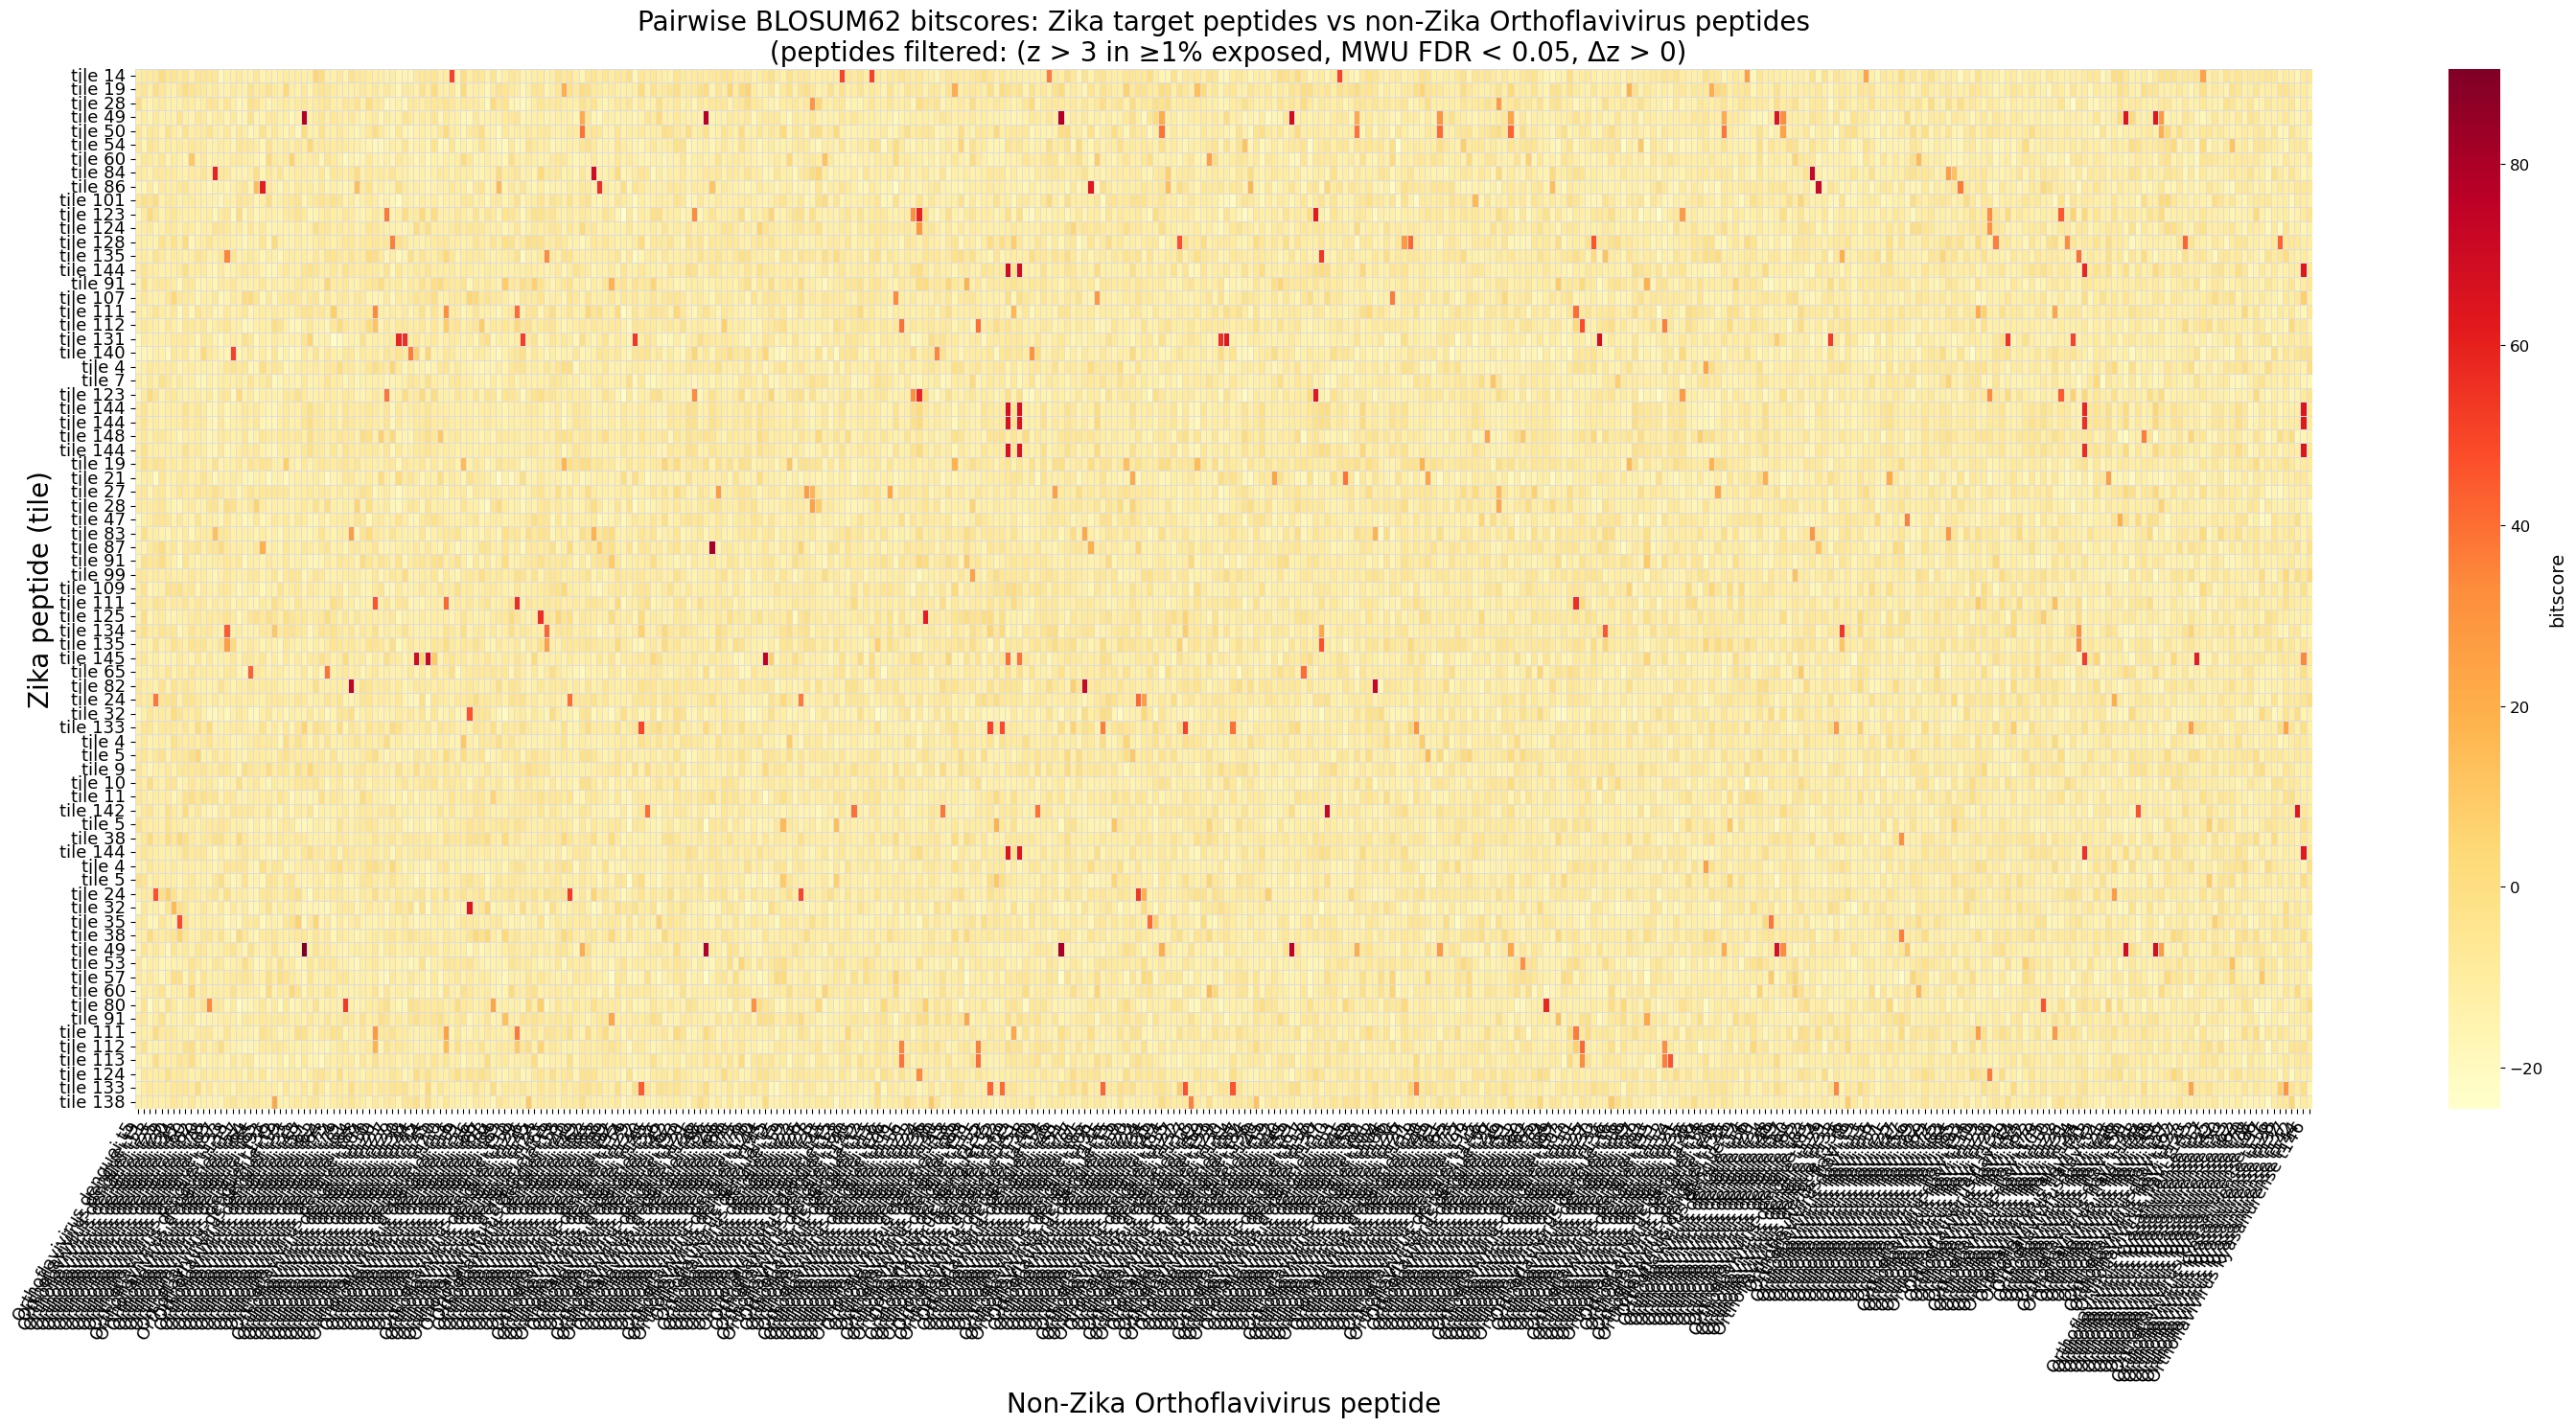

In [ ]:
# ── Heatmap: zika peptides (rows) × non-zika peptides (cols) ─────────────────
# Rows labelled by zika fragment number, columns by species + fragment.

import seaborn as sns
import matplotlib.pyplot as plt

#renaming the bitscore matrix of zika peptides x non_zika_orthoflavivirus peptides to mat
mat = results_non_target.astype(float)

protein_metadata_genus.loc[protein_metadata_genus.species.isna(), 'species'] = 'Orthoflavivirus dengue'

# build readable axis labels
row_labels = [
    f"tile {protein_metadata_exposed_zika.loc[p, 'fragment']}"
    for p in mat.index
]

col_labels = [
    f"{protein_metadata_genus.loc[p, 'species']} t{protein_metadata_genus.loc[p, 'fragment']}"
    if p in protein_metadata_genus.index else p
    for p in mat.columns
]

fig, ax = plt.subplots(figsize=(30, 15))
sns.heatmap(
    mat.values, #here are the bitscore alignment values stored 
    xticklabels=col_labels,
    yticklabels=row_labels,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#dddddd',
    ax=ax
)
ax.set_xlabel('Non-Zika Orthoflavivirus peptide', fontsize=20)
ax.set_ylabel('Zika peptide (tile)', fontsize=20)
ax.set_title(
    f'Pairwise BLOSUM62 bitscores: Zika target peptides vs non-Zika Orthoflavivirus peptides\n (peptides filtered: (z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0)',
    fontsize=20
)

#add colorbar
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('bitscore', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.xticks(rotation=60, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


#### 8. Compare exposed vs HBDB
- Compare exposed samples to HBDB using the raw signal.
- Repeat using the adjusted signal.
- Record:
  1. mean or median per group
  2. effect size
  3. statistical significance

#### 9. Interpret the pattern
- If the adjusted signal stays strong, that supports real exposure.
- If the adjusted signal drops a lot, the signal may be driven by cross-reactivity.
- If only a few tiles change, cross-reactivity may be localized to specific peptide regions.

#### 10. Stress-test the conclusion
- Repeat using genus, then family.
- Repeat with different bitscore thresholds.
- Repeat with different bitscore summaries.
- Repeat with RPK and z-score.
- Repeat for one protein at a time.

#### 11. Visualize
- Plot target peptides and their cross-reactivity scores.
- Plot raw vs adjusted protein-level signal.
- Plot exposed vs HBDB separation before and after adjustment.
- Check whether signal is broad across the protein or limited to a few peptides.

#### Working rule
- If the adjusted signal survives downweighting, that supports true exposure.
- If the adjusted signal collapses, that suggests the result may mostly reflect cross-reactivity.

## Now I want to DIAMOND align all peptides in the library to the zika virus polyprotein, and see how the cumulative rpk looks for the exposed group vs the healthy group at different bitscore thresholds

In [ ]:
#---- taking the zika polyprotein reference sequence from UniProt (A0A024B7W1-1): canonical sequence---
from Bio import SeqIO

for record in SeqIO.parse('zika_uniprot_polyprotein_canonical_aa_sequence.fasta', 'fasta'):
    print(f"ID: {record.id}")
    print(f"Sequence Description: {record.description}")
    print(f"Sequence (first 20 bp): {record.seq[:50]}")
    print(f"Total Length: {len(record.seq)} \n")

ID: sp|A0A024B7W1|POLG_ZIKVF
Sequence Description: sp|A0A024B7W1|POLG_ZIKVF Genome polyprotein OS=Zika virus (isolate ZIKV/Human/French Polynesia/10087PF/2013) OX=2043570 PE=1 SV=1
Sequence (first 20 bp): MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRMVLAI
Total Length: 3423 



## Doing a DIAMOND alignment all peptides in my library to the Zika polyprotein reference sequence

In [ ]:
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from diamondonpy import Diamond

# building the reference protein database
#proteins.fasta contains the target reference protein sequence(s)

#initializing diamond wrapper
diamond = Diamond()

#now making the database -- converts fasta to binary format so DIAMOND can search quickly
diamond.makedb(
    db="protein_db.dmnd",
    input_file="zika_uniprot_polyprotein_canonical_aa_sequence.fasta",
    threads=4
)

#-- write query peptides from protein_metadata to FASTA 
#use iterrows() to give me both the index and the row value for sequence column
#note that iterrows() is slow on large dfs, so could use zip(protein_metadata.index, protein_metadata['sequence'])
peptide_records = [
    SeqRecord(Seq(str(row['sequence'])), id=str(idx), description='')
    for idx, row in protein_metadata.iterrows()
]
SeqIO.write(peptide_records, 'peptides_phipseqlib.fasta', 'fasta')

#3. align peptide sequences against the database
#peptides.fasta should contain the short query peptides

results_df = diamond.blastp(
    db="protein_db.dmnd",
    query='peptides_phipseqlib.fasta'
)

print(results_df.head())

"""
Note that DIAMOND's default evalue threshold is 0.001
short peptides often don't achieve significance against a single reference sequence
so they are droped entirely 

that't why in the results_df I only see a couple of dozen peptides as a result
"""

                                              qseqid  \
0  XQH47600.1|polyprotein|dengue_virus_type_4|iso...   
1  XQH47600.1|polyprotein|dengue_virus_type_4|iso...   
2  XQH47600.1|polyprotein|dengue_virus_type_4|iso...   
3  XQH47600.1|polyprotein|dengue_virus_type_4|iso...   
4  XQH47600.1|polyprotein|dengue_virus_type_4|iso...   

                     sseqid  pident  length  mismatch  gapopen  qstart  qend  \
0  sp|A0A024B7W1|POLG_ZIKVF    56.5      46        19        1       2    46   
1  sp|A0A024B7W1|POLG_ZIKVF    57.4      47        18        2       1    45   
2  sp|A0A024B7W1|POLG_ZIKVF    47.8      46        24        0       1    46   
3  sp|A0A024B7W1|POLG_ZIKVF    50.0      46        23        0       1    46   
4  sp|A0A024B7W1|POLG_ZIKVF    73.9      46        12        0       1    46   

   sstart  send        evalue  bitscore  
0     149   194  3.900000e-18      64.7  
1     171   217  2.090000e-18      65.5  
2     242   287  4.660000e-14      53.1  
3     265   31

"\nNote that DIAMOND's default evalue threshold is 0.001\nshort peptides often don't achieve significance against a single reference sequence\nso they are droped entirely \n\nthat't why in the results_df I only see a couple of dozen peptides as a result\n"

In [ ]:
#have to concatenate the avg rpk values for the exposed cohort (first time points) and then the averaged rpks for the healthies (no first timepoint to subset)
df_rpk = pd.concat([df_rpk, df_hbdb], axis = 1)

peptides kept after bitscore filtering (276, 12)
peptides kept after bitscore filtering AND keeping only peptides which have z_score > 3 in >= 0.01 of exposed (34, 12)


/tmp/ipykernel_4016221/791061339.py:92: RuntimeWarning: divide by zero encountered in log10
  ax1.fill_between(positions, np.log10(protein_aa_exposed), alpha=0.6, label='Exposed', color='steelblue')
/tmp/ipykernel_4016221/791061339.py:93: RuntimeWarning: divide by zero encountered in log10
  ax1.fill_between(positions, np.log10(protein_aa_healthy), alpha=0.6, label='Healthy', color='salmon')
/tmp/ipykernel_4016221/791061339.py:111: RuntimeWarning: divide by zero encountered in log10
  ax2.fill_between(positions, np.log10(diff), where=(diff > 0), alpha=0.7, color= 'steelblue', label='Exposed')
/tmp/ipykernel_4016221/791061339.py:112: RuntimeWarning: divide by zero encountered in log10
  ax2.fill_between(positions, np.log10(diff), where=(diff < 0), alpha=0.7, color='salmon', label='Healthy')


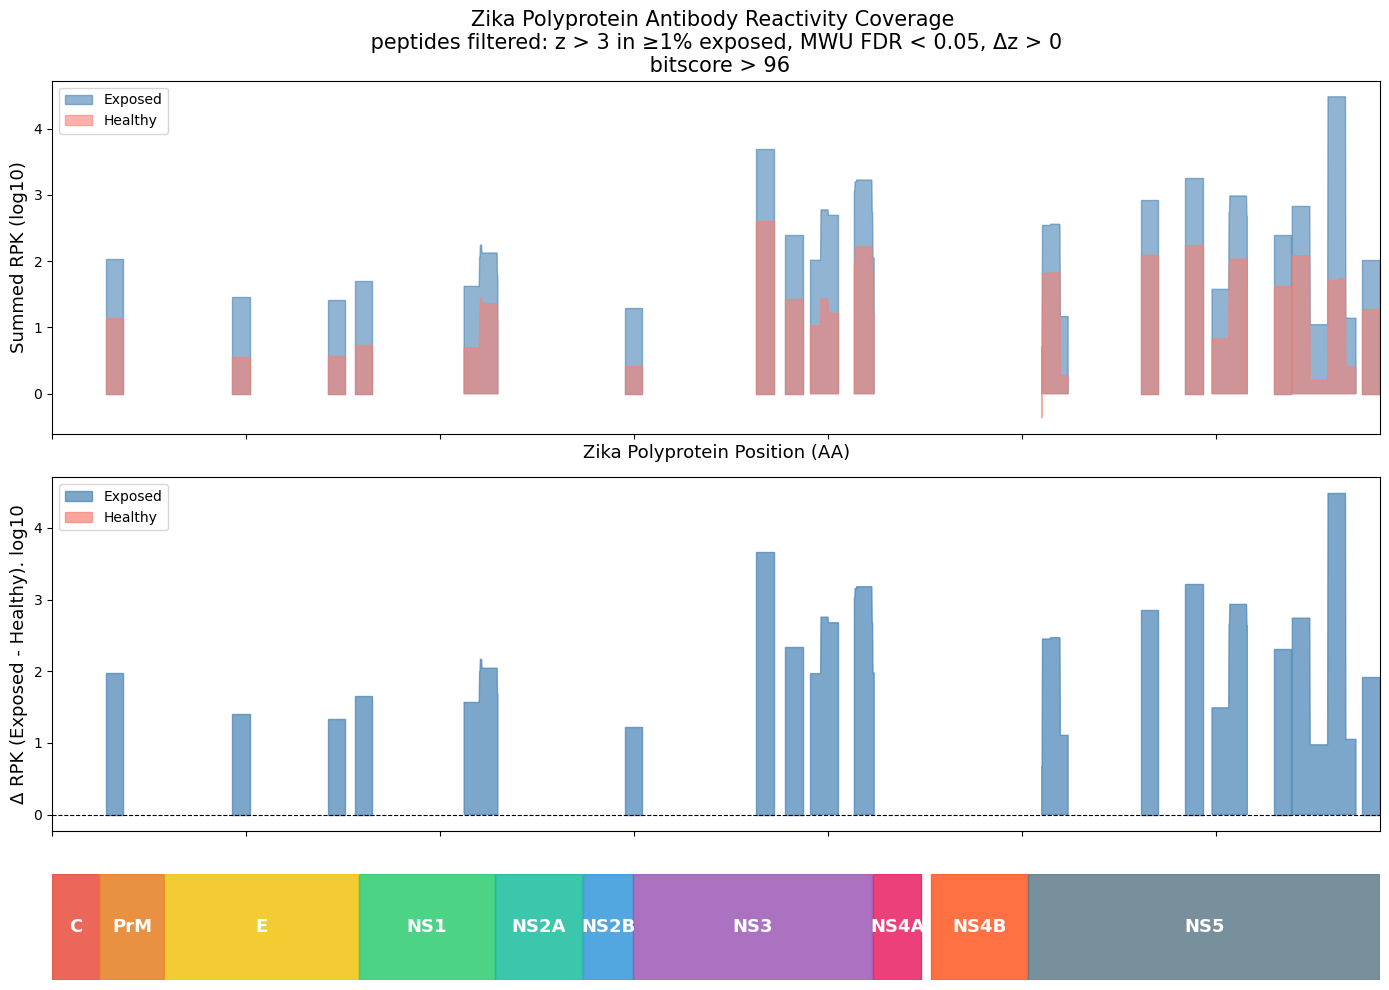

In [ ]:
#---- 1. Coverage Plot + add a domain track below the x-axis so e.g. capsid, envelope, NS1 etc
#line or area plot where each AA position on the x-axis gets the sum of RPK from all peptides
#whose alignment spans that position (filtered by bitscore)
#two lines/filled areas - one for exposed, one for healthy 

#--- 1a: get the length of the zika polyprotein
for record in SeqIO.parse("zika_uniprot_polyprotein_canonical_aa_sequence.fasta", 'fasta'):
    len_protein = int(len(record.seq))

#---- 1b: choose a bitscore threshold

THRESH = 96

#get the qseqid's which aligned to the reference with a bitscore > thresh

results_df_filtered = results_df[results_df['bitscore'] > THRESH].copy()
print(f'peptides kept after bitscore filtering', results_df_filtered.shape)

#---- need to subset to those peptides in qseqid which actually passed the zscore thresholding
#use isin() as kept_peps is a list

results_df_filtered = results_df_filtered[results_df_filtered['qseqid'].isin(kept_peps)]
print(f'peptides kept after bitscore filtering AND keeping only peptides which have z_score > 3 in >= 0.01 of exposed', results_df_filtered.shape)

#now going loop through every peptide in qseqid, map its position to the reference polyprotein
#using the sstart and send information from results_df, and then add the rpk score (of the exposed group)
#for that peptide to the amino acids it covers from the reference sequence

#-- initialize the coverage array - one value per AA position
protein_aa_exposed  = [0.0] * len_protein
protein_aa_healthy = [0.0] * len_protein

exposed_samples = exposed_df.index.to_list()
healthy_samples = healthies_df.index.to_list()

#important to only keep peptides which passed the z-score threshold filtering of z > 3 compared to healthies in >=10% of exposed

df_rpk = df_rpk.loc[kept_peps]

for _, row in results_df_filtered.iterrows(): #returns index and the row
    qseqid = row['qseqid']
    sstart = int(row['sstart']) - 1 #convert to 0-based indexing
    send = int(row['send']) #send is inclusive, so no -1 needed 

    #sum RPK across all exposed samples for this peptide
    exposed_rpk = df_rpk.loc[qseqid, exposed_samples].sum()
    healthy_rpk = df_rpk.loc[qseqid, healthy_samples].sum()

    #add to every AA position this peptide covers
    for pos in range(sstart, send):
        protein_aa_exposed[pos] += exposed_rpk
        protein_aa_healthy[pos] += healthy_rpk



#--- zika polyprotein domain boundaries (AA-position, 1-based)

#--- annotations from: https://www.uniprot.org/uniprotkb/Q32ZE1/entry#sequences

domains = [
    ('C',    1,    122,  '#E74C3C'),
    ('PrM',  123,  290,  '#E67E22'),
    ('E',    291,  790,  '#F1C40F'),
    ('NS1',  791,  1142, '#2ECC71'),
    ('NS2A', 1143, 1368, '#1ABC9C'),
    ('NS2B', 1369, 1498, '#3498DB'),
    ('NS3',  1499, 2115, '#9B59B6'),
    ('NS4A', 2116, 2242, '#E91E63'),
    ('NS4B', 2266, 2516, '#FF5722'),
    ('NS5',  2517, len_protein, '#607D8B'),
]

x = list(range(len_protein))

#---- now plot 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ipywidgets as widgets
from IPython.display import display


positions = range(len_protein)

#initiate subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={'height_ratios' : [2, 2, 0.6]}, #changing the height reatios to give ax3 less space
                         sharex=True)

#--- panel 1 : coverage
ax1 = axes[0]
ax1.fill_between(positions, np.log10(protein_aa_exposed), alpha=0.6, label='Exposed', color='steelblue')
ax1.fill_between(positions, np.log10(protein_aa_healthy), alpha=0.6, label='Healthy', color='salmon')
ax1.set_xlabel('Zika Polyprotein Position (AA)', fontsize=13)
ax1.set_ylabel('Summed RPK (log10)', fontsize=13)
ax1.set_title(f'Zika Polyprotein Antibody Reactivity Coverage \n peptides filtered: z > {Z_THRESH} in ≥{int(MIN_FRAC*100)}% exposed, MWU FDR < {SIG_FDR}, Δz > 0 \n bitscore > {THRESH}', fontsize=15)
ax1.legend()
ax1.set_xlim(0, len_protein)


#---- panel 2. Differential Coverage Plot
#same as above, but plot exposed RPK - healthy RPK so enrichment above zero = exposed specific signal
#immediately highlights immunodominant positions


ax2 = axes[1]
#convert list to array
diff = np.array(protein_aa_exposed) - np.array(protein_aa_healthy)

#note the alpha parameter dictates the transparency of the color in the plot
ax2.fill_between(positions, np.log10(diff), where=(diff > 0), alpha=0.7, color= 'steelblue', label='Exposed')
ax2.fill_between(positions, np.log10(diff), where=(diff < 0), alpha=0.7, color='salmon', label='Healthy')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Δ RPK (Exposed - Healthy). log10', fontsize=13)
ax2.set_xlim(0, len_protein)
ax2.legend()

#--- panel 3: domain track

ax3 = axes[2]
ax3.set_ylim(0, 1)
#set axis off to turn off the axis framee, ticks, and tick labels for that panel - so get a clean blank canvas to draw domain rectangles on with add_patch()
ax3.axis('off')
for name, start, end, color in domains:
    ax3.add_patch(mpatches.Rectangle(
        #bottom-left: AA start position, slightly above 0
        (start - 1, 0.0), 
        end - start, #this is the width, which exactly spans the domain's AA length
        1, #height: fills the full height
        color=color, alpha=0.85
    ))
    mid = (start + end) / 2
    ax3.text(mid, 0.5, name, ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')

ax3.set_xlim(0, len_protein) #set this, so that the x-axis defaults to 0, len(protein) and not 0, 1
axes[2].set_xlabel('Amino Acid Position')
plt.tight_layout()
plt.savefig('zika_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


#---- 3. use interactive bitscore slider
#use ipywidgets or plotly with a bitscore slider - as you drag the bitscore thresh, the coverage plot updates live



In [ ]:
results_df_filtered

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
1582,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,1105,1150,2.670000e-33,107.0
1609,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,1956,2001,2.850000e-31,102.0
1631,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,sp|A0A024B7W1|POLG_ZIKVF,97.8,46,1,0,1,46,2807,2852,9.900000e-31,100.0
1636,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,2922,2967,8.750000e-30,97.8
1647,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,sp|A0A024B7W1|POLG_ZIKVF,97.8,46,1,0,1,46,3290,3335,6.010000e-32,103.0
1666,WXL51555.1|polyprotein|Zika_virus|isolate=1374...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,2071,2116,1.840000e-30,99.8
1673,WXL51555.1|polyprotein|Zika_virus|isolate=1374...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,2554,2599,3.040000e-29,96.3
1681,WXL51555.1|polyprotein|Zika_virus|isolate=1374...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,2991,3036,5.310000e-31,101.0
1682,WXL51555.1|polyprotein|Zika_virus|isolate=1374...,sp|A0A024B7W1|POLG_ZIKVF,100.0,46,0,0,1,46,3198,3243,8.720000e-35,112.0
1706,WEW53506.1|polyprotein|Zika_virus|isolate=27|H...,sp|A0A024B7W1|POLG_ZIKVF,97.8,46,1,0,1,46,139,184,7.250000e-31,100.0
